# DataCo Supply Chain — Exploratory Data Analysis

## Objective

Explore and understand the DataCo supply chain dataset before designing
the data warehouse, analytics layer, machine learning models, forecasting
pipeline, optimization framework, and AI/LLM components.

## Key Areas

- Dataset structure and data quality
- Orders, customers, products, and categories
- Sales and profitability
- Delivery performance
- Late delivery risk
- Shipping modes
- Geographic distribution
- Temporal trends
- Relationships between operational and financial variables

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
DATA_PATH = "../data/raw/DataCoSupplyChainDataset.csv"

df = pd.read_csv(
    DATA_PATH,
    encoding="latin1"
)

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset loaded: 180,519 rows × 53 columns


In [4]:
df.shape

(180519, 53)

In [5]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.0,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.0,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027.0,2,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.0,2,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  str    
 9   Customer City                  180519 non-null  str    
 10  Customer Country               180519 non-null  str    
 11  Customer Email                 180519 non-null  str    
 12  Customer Fname                 180519 non

In [7]:
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": (df.isnull().mean() * 100).round(2)
})

missing = missing[missing["missing_count"] > 0] \
    .sort_values("missing_count", ascending=False)

missing

,missing_count,missing_percent
Product Description,180519,100.00
Order Zipcode,155679,86.24
Customer Lname,8,0.00
Customer Zipcode,3,0.00


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.nunique().sort_values()

Product Description                   0
Customer Password                     1
Product Status                        1
Customer Email                        1
Late_delivery_risk                    2
Customer Country                      2
Customer Segment                      3
Delivery Status                       4
Days for shipment (scheduled)         4
Shipping Mode                         4
Type                                  4
Market                                5
Order Item Quantity                   5
Days for shipping (real)              7
Order Status                          9
Department Id                        11
Department Name                      11
Order Item Discount Rate             18
Order Region                         23
Customer State                       46
Category Name                        50
Product Category Id                  51
Category Id                          51
Order Item Product Price             75
Product Price                        75


In [10]:
key_columns = [
    "Order Id",
    "Order Item Id",
    "Customer Id",
    "Order Customer Id",
    "Product Card Id",
    "Category Id",
    "Department Id"
]

df[key_columns].nunique()

Order Id              65752
Order Item Id        180519
Customer Id           20652
Order Customer Id     20652
Product Card Id         118
Category Id              51
Department Id            11
dtype: int64

In [11]:
df["Order Item Id"].is_unique

True

In [12]:
df["Order Id"].nunique()

65752

In [13]:
(df["Customer Id"] == df["Order Customer Id"]).mean()

np.float64(1.0)

In [14]:
(df["Product Card Id"] == df["Order Item Cardprod Id"]).mean()

np.float64(1.0)

In [15]:
(df["Category Id"] == df["Product Category Id"]).mean()

np.float64(1.0)

In [16]:
df["Order Id"].value_counts().describe()

count    65752.000000
mean         2.745453
std          1.478363
min          1.000000
25%          1.000000
50%          3.000000
75%          4.000000
max          5.000000
Name: count, dtype: float64

In [17]:
df[[
    "order date (DateOrders)",
    "shipping date (DateOrders)"
]].head(10)

,order date (DateOrders),shipping date (DateOrders)
0,1/31/2018 22:56,2/3/2018 22:56
1,1/13/2018 12:27,1/18/2018 12:27
2,1/13/2018 12:06,1/17/2018 12:06
3,1/13/2018 11:45,1/16/2018 11:45
4,1/13/2018 11:24,1/15/2018 11:24
5,1/13/2018 11:03,1/19/2018 11:03
6,1/13/2018 10:42,1/15/2018 10:42
7,1/13/2018 10:21,1/15/2018 10:21
8,1/13/2018 10:00,1/16/2018 10:00
9,1/13/2018 9:39,1/15/2018 9:39


In [18]:
df[[
    "order date (DateOrders)",
    "shipping date (DateOrders)"
]].nunique()

order date (DateOrders)       65752
shipping date (DateOrders)    63701
dtype: int64

In [19]:
df["order date (DateOrders)"].min(), df["order date (DateOrders)"].max()

('1/1/2015 0:00', '9/9/2017 9:50')

In [20]:
df["shipping date (DateOrders)"].min(), df["shipping date (DateOrders)"].max()

('1/1/2016 0:22', '9/9/2017 9:08')

In [21]:
(
    df["Days for shipping (real)"] -
    df["Days for shipment (scheduled)"]
).describe()

count    180519.000000
mean          0.565807
std           1.490966
min          -2.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           4.000000
dtype: float64

In [22]:
order_date = pd.to_datetime(
    df["order date (DateOrders)"],
    format="%m/%d/%Y %H:%M"
)

shipping_date = pd.to_datetime(
    df["shipping date (DateOrders)"],
    format="%m/%d/%Y %H:%M"
)

date_difference = (
    shipping_date - order_date
).dt.total_seconds() / (24 * 60 * 60)

date_difference.describe()

count    180519.000000
mean          3.498826
std           1.617394
min           0.500000
25%           2.000000
50%           3.000000
75%           5.000000
max           6.000000
dtype: float64

In [23]:
(
    date_difference.round().astype(int)
    == df["Days for shipping (real)"]
).mean()


np.float64(0.9742021615453221)

In [24]:
df["Delivery Status"].value_counts()

Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

In [25]:
df["Late_delivery_risk"].value_counts()

Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

In [26]:
df["Sales"].describe()

count    180519.000000
mean        203.772096
std         132.273077
min           9.990000
25%         119.980003
50%         199.919998
75%         299.950012
max        1999.989990
Name: Sales, dtype: float64

In [27]:
df["Order Profit Per Order"].describe()

count    180519.000000
mean         21.974989
std         104.433526
min       -4274.979980
25%           7.000000
50%          31.520000
75%          64.800003
max         911.799988
Name: Order Profit Per Order, dtype: float64

In [28]:
df["Benefit per order"].describe()

count    180519.000000
mean         21.974989
std         104.433526
min       -4274.979980
25%           7.000000
50%          31.520000
75%          64.800003
max         911.799988
Name: Benefit per order, dtype: float64

In [29]:
(df["Benefit per order"] == df["Order Profit Per Order"]).mean()


np.float64(1.0)

In [30]:
df["Order Item Discount"].describe()

count    180519.000000
mean         20.664741
std          21.800901
min           0.000000
25%           5.400000
50%          14.000000
75%          29.990000
max         500.000000
Name: Order Item Discount, dtype: float64

In [31]:
df["Order Item Quantity"].describe()

count    180519.000000
mean          2.127638
std           1.453451
min           1.000000
25%           1.000000
50%           1.000000
75%           3.000000
max           5.000000
Name: Order Item Quantity, dtype: float64

In [32]:
df["Product Price"].describe()

count    180519.000000
mean        141.232550
std         139.732492
min           9.990000
25%          50.000000
50%          59.990002
75%         199.990005
max        1999.989990
Name: Product Price, dtype: float64

In [33]:
df[[
    "Sales",
    "Order Item Total",
    "Order Profit Per Order",
    "Benefit per order",
    "Order Item Discount",
    "Order Item Quantity"
]].corr()

,Sales,Order Item Total,Order Profit Per Order,Benefit per order,Order Item Discount,Order Item Quantity
Sales,1.000000,0.989744,0.131816,0.131816,0.617438,0.106442
Order Item Total,0.989744,1.000000,0.133484,0.133484,0.498734,0.105413
Order Profit Per Order,0.131816,0.133484,1.000000,1.000000,0.064756,0.015696
Benefit per order,0.131816,0.133484,1.000000,1.000000,0.064756,0.015696
Order Item Discount,0.617438,0.498734,0.064756,0.064756,1.000000,0.065379
Order Item Quantity,0.106442,0.105413,0.015696,0.015696,0.065379,1.000000


In [34]:
df[[
    "Sales",
    "Order Item Total",
    "Order Item Product Price",
    "Order Item Quantity",
    "Order Item Discount"
]].head(10)

,Sales,Order Item Total,Order Item Product Price,Order Item Quantity,Order Item Discount
0,327.75,314.640015,327.75,1,13.110000
1,327.75,311.359985,327.75,1,16.389999
2,327.75,309.720001,327.75,1,18.030001
3,327.75,304.809998,327.75,1,22.940001
4,327.75,298.250000,327.75,1,29.500000
5,327.75,294.980011,327.75,1,32.779999
6,327.75,288.420013,327.75,1,39.330002
7,327.75,285.140015,327.75,1,42.610001
8,327.75,278.589996,327.75,1,49.160000
9,327.75,275.309998,327.75,1,52.439999


In [35]:
(
    df["Sales"] - df["Order Item Discount"]
    - df["Order Item Total"]
).abs().describe()

count    180519.000000
mean          0.000258
std           0.001577
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000005
max           0.010014
dtype: float64

In [36]:
(
    df["Order Item Product Price"] *
    df["Order Item Quantity"]
    - df["Sales"]
).abs().describe()

count    1.805190e+05
mean     1.070056e-06
std      3.288616e-06
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      2.000002e-08
max      2.290000e-05
dtype: float64

In [37]:
df["Customer Segment"].value_counts()

Customer Segment
Consumer       93504
Corporate      54789
Home Office    32226
Name: count, dtype: int64

In [38]:
df["Market"].value_counts()

Market
LATAM           51594
Europe          50252
Pacific Asia    41260
USCA            25799
Africa          11614
Name: count, dtype: int64

In [39]:
df["Shipping Mode"].value_counts()

Shipping Mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64

In [40]:
df["Department Name"].value_counts()

Department Name
Fan Shop              66861
Apparel               48998
Golf                  33220
Footwear              14525
Outdoors               9686
Fitness                2479
Discs Shop             2026
Technology             1465
Pet Shop                492
Book Shop               405
Health and Beauty       362
Name: count, dtype: int64

In [41]:
df["Category Name"].nunique()

50

In [42]:
df["Category Name"].value_counts()

Category Name
Cleats                  24551
Men's Footwear          22246
Women's Apparel         21035
Indoor/Outdoor Games    19298
Fishing                 17325
Water Sports            15540
Camping & Hiking        13729
Cardio Equipment        12487
Shop By Sport           10984
Electronics              3156
Accessories              1780
Golf Balls               1475
Girls' Apparel           1201
Golf Gloves              1070
Trade-In                  974
Video Games               838
Children's Clothing       652
Women's Clothing          650
Baseball & Softball       632
Hockey                    614
Cameras                   592
Toys                      529
Golf Shoes                524
Pet Supplies              492
Crafts                    484
Garden                    484
DVDs                      483
Computers                 442
Golf Apparel              441
Hunting & Shooting        440
Music                     434
Consumer Electronics      431
Boxing & MMA              

In [43]:
df["Product Card Id"].nunique()

118

In [44]:
df.groupby("Product Card Id").agg(
    product_names=("Product Name", "nunique"),
    prices=("Product Price", "nunique"),
    categories=("Category Id", "nunique"),
    departments=("Department Id", "nunique")
).describe()

,product_names,prices,categories,departments
count,118.0,118.0,118.0,118.0
mean,1.0,1.0,1.0,1.0
std,0.0,0.0,0.0,0.0
min,1.0,1.0,1.0,1.0
25%,1.0,1.0,1.0,1.0
50%,1.0,1.0,1.0,1.0
75%,1.0,1.0,1.0,1.0
max,1.0,1.0,1.0,1.0


In [45]:
df.groupby("Customer Id").agg(
    first_names=("Customer Fname", "nunique"),
    last_names=("Customer Lname", "nunique"),
    emails=("Customer Email", "nunique"),
    segments=("Customer Segment", "nunique"),
    countries=("Customer Country", "nunique"),
    states=("Customer State", "nunique")
).describe()

,first_names,last_names,emails,segments,countries,states
count,20652.0,20652.000000,20652.0,20652.0,20652.0,20652.0
mean,1.0,0.999613,1.0,1.0,1.0,1.0
std,0.0,0.019678,0.0,0.0,0.0,0.0
min,1.0,0.000000,1.0,1.0,1.0,1.0
25%,1.0,1.000000,1.0,1.0,1.0,1.0
50%,1.0,1.000000,1.0,1.0,1.0,1.0
75%,1.0,1.000000,1.0,1.0,1.0,1.0
max,1.0,1.000000,1.0,1.0,1.0,1.0


In [46]:
df.groupby("Customer Id")["Customer Lname"].apply(lambda x: x.isna().sum()).value_counts().head()

Customer Lname
0    20644
1        8
Name: count, dtype: int64

In [47]:
df["Order Country"].nunique()

164

In [48]:
df["Customer Country"].nunique()

2

In [49]:
df["Customer Country"].value_counts()

Customer Country
EE. UU.        111146
Puerto Rico     69373
Name: count, dtype: int64

In [50]:
df["Order Region"].nunique()

23

In [51]:
df["Order Region"].value_counts()

Order Region
Central America    28341
Western Europe     27109
South America      14935
Oceania            10148
Northern Europe     9792
Southeast Asia      9539
Southern Europe     9431
Caribbean           8318
West of USA         7993
South Asia          7731
Eastern Asia        7280
East of USA         6915
West Asia           6009
US Center           5887
South of  USA       4045
Eastern Europe      3920
West Africa         3696
North Africa        3232
East Africa         1852
Central Africa      1677
Southern Africa     1157
Canada               959
Central Asia         553
Name: count, dtype: int64

In [52]:
df["Order State"].nunique()

1089

In [53]:
df["Order State"].value_counts().head(20)

Order State
Inglaterra                     6722
California                     4966
Isla de Francia                4580
Renania del Norte-Westfalia    3303
San Salvador                   3055
Nueva York                     2753
Distrito Federal               2559
Texas                          2446
Nueva Gales del Sur            2370
Santo Domingo                  2211
Queensland                     2186
Guatemala                      2109
São Paulo                      2031
Provenza-Alpes-Costa Azul      1842
Capital Nacional               1837
Managua                        1834
Francisco Morazán              1783
Panamá                         1631
Victoria                       1456
Pensilvania                    1406
Name: count, dtype: int64

In [54]:
df["Order City"].nunique()

3597

In [55]:
df["order date (DateOrders)"].min(), df["order date (DateOrders)"].max()

('1/1/2015 0:00', '9/9/2017 9:50')

In [56]:
df["order date (DateOrders)"] = pd.to_datetime(
    df["order date (DateOrders)"],
    errors="coerce"
)

df["order date (DateOrders)"].dt.year.value_counts().sort_index()

order date (DateOrders)
2015    62650
2016    62550
2017    53196
2018     2123
Name: count, dtype: int64

In [57]:
df.loc[
    df["order date (DateOrders)"].dt.year == 2018,
    "order date (DateOrders)"
].describe()

count                          2123
mean     2018-01-16 11:55:33.179463
min             2018-01-01 00:13:00
25%             2018-01-08 18:04:30
50%             2018-01-16 11:56:00
75%             2018-01-24 05:47:30
max             2018-01-31 23:38:00
Name: order date (DateOrders), dtype: object

In [58]:
df["order date (DateOrders)"].dt.to_period("M").value_counts().sort_index()

order date (DateOrders)
2015-01    5322
2015-02    4729
2015-03    5362
2015-04    5126
2015-05    5357
2015-06    5134
2015-07    5299
2015-08    5273
2015-09    5140
2015-10    5302
2015-11    5235
2015-12    5371
2016-01    5317
2016-02    4894
2016-03    5210
2016-04    5097
2016-05    5302
2016-06    5054
2016-07    5305
2016-08    5334
2016-09    5160
2016-10    5398
2016-11    5210
2016-12    5269
2017-01    5217
2017-02    4906
2017-03    5347
2017-04    5212
2017-05    5317
2017-06    4951
2017-07    5318
2017-08    5305
2017-09    5189
2017-10    2255
2017-11    2055
2017-12    2124
2018-01    2123
Freq: M, Name: count, dtype: int64

In [59]:
monthly_counts = (
    df["order date (DateOrders)"]
    .dt.to_period("M")
    .value_counts()
    .sort_index()
)

print("Number of months:", len(monthly_counts))
print("First month:", monthly_counts.index.min())
print("Last month:", monthly_counts.index.max())

Number of months: 37
First month: 2015-01
Last month: 2018-01


In [60]:
df[[
    "Days for shipping (real)",
    "Days for shipment (scheduled)"
]].describe()

,Days for shipping (real),Days for shipment (scheduled)
count,180519.000000,180519.000000
mean,3.497654,2.931847
std,1.623722,1.374449
min,0.000000,0.000000
25%,2.000000,2.000000
50%,3.000000,4.000000
75%,5.000000,4.000000
max,6.000000,4.000000


In [61]:
df["shipping_delay"] = (
    df["Days for shipping (real)"]
    - df["Days for shipment (scheduled)"]
)

df["shipping_delay"].describe()

count    180519.000000
mean          0.565807
std           1.490966
min          -2.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           4.000000
Name: shipping_delay, dtype: float64

In [62]:
pd.crosstab(
    df["shipping_delay"] > 0,
    df["Late_delivery_risk"],
    normalize="index"
)

Late_delivery_risk,0,1
shipping_delay,,
False,1.000000,0.000000
True,0.042776,0.957224


In [63]:
df[
    (df["shipping_delay"] > 0) &
    (df["Late_delivery_risk"] == 0)
][[
    "Days for shipping (real)",
    "Days for shipment (scheduled)",
    "shipping_delay",
    "Delivery Status",
    "Late_delivery_risk"
]].head(20)

,Days for shipping (real),Days for shipment (scheduled),shipping_delay,Delivery Status,Late_delivery_risk
5,6,4,2,Shipping canceled,0
10,6,2,4,Shipping canceled,0
23,3,2,1,Shipping canceled,0
39,1,0,1,Shipping canceled,0
183,5,4,1,Shipping canceled,0
184,5,4,1,Shipping canceled,0
185,6,4,2,Shipping canceled,0
186,5,4,1,Shipping canceled,0
192,6,4,2,Shipping canceled,0
193,5,4,1,Shipping canceled,0


In [64]:
pd.crosstab(
    df["Delivery Status"],
    df["Late_delivery_risk"],
    normalize="index"
)

Late_delivery_risk,0,1
Delivery Status,,
Advance shipping,1.0,0.0
Late delivery,0.0,1.0
Shipping canceled,1.0,0.0
Shipping on time,1.0,0.0


In [65]:
df["Order Status"].value_counts()

Order Status
COMPLETE           59491
PENDING_PAYMENT    39832
PROCESSING         21902
PENDING            20227
CLOSED             19616
ON_HOLD             9804
SUSPECTED_FRAUD     4062
CANCELED            3692
PAYMENT_REVIEW      1893
Name: count, dtype: int64

In [66]:
pd.crosstab(
    df["Order Status"],
    df["Delivery Status"]
)

Delivery Status,Advance shipping,Late delivery,Shipping canceled,Shipping on time
Order Status,,,,
CANCELED,0,0,3692,0
CLOSED,4809,11109,0,3698
COMPLETE,14136,34199,0,11156
ON_HOLD,2413,5450,0,1941
PAYMENT_REVIEW,420,1082,0,391
PENDING,4857,11712,0,3658
PENDING_PAYMENT,9588,22922,0,7322
PROCESSING,5369,12503,0,4030
SUSPECTED_FRAUD,0,0,4062,0


In [67]:
(df["Order Status"] == "SUSPECTED_FRAUD").mean()

np.float64(0.02250178651554684)

In [68]:
payment_statuses = ["PENDING_PAYMENT", "PAYMENT_REVIEW"]

df["Order Status"].isin(payment_statuses).mean()

np.float64(0.2311391044709975)

In [69]:
df["Product Name"].value_counts().head(15)

Product Name
Perfect Fitness Perfect Rip Deck                 24515
Nike Men's CJ Elite 2 TD Football Cleat          22246
Nike Men's Dri-FIT Victory Golf Polo             21035
O'Brien Men's Neoprene Life Vest                 19298
Field & Stream Sportsman 16 Gun Fire Safe        17325
Pelican Sunstream 100 Kayak                      15500
Diamondback Women's Serene Classic Comfort Bi    13729
Nike Men's Free 5.0+ Running Shoe                12169
Under Armour Girls' Toddler Spine Surge Runni    10617
Fighting video games                               838
Children's heaters                                 652
Summer dresses                                     650
Web Camera                                         592
Toys                                               529
Adult dog supplies                                 492
Name: count, dtype: int64

In [70]:
df[["Order Item Cardprod Id", "Product Card Id"]].nunique()

Order Item Cardprod Id    118
Product Card Id           118
dtype: int64

In [71]:
(
    df["Order Item Cardprod Id"] == df["Product Card Id"]
).mean()

np.float64(1.0)

In [72]:
print(
    "Category IDs identical:",
    (df["Category Id"] == df["Product Category Id"]).mean()
)

print(
    "Customer IDs identical:",
    (df["Customer Id"] == df["Order Customer Id"]).mean()
)

Category IDs identical: 1.0
Customer IDs identical: 1.0


In [73]:
valid_dates = df[
    df["order date (DateOrders)"].notna() &
    df["shipping date (DateOrders)"].notna()
].copy()

valid_dates["order_date"] = pd.to_datetime(
    valid_dates["order date (DateOrders)"],
    errors="coerce"
)

valid_dates["shipping_date"] = pd.to_datetime(
    valid_dates["shipping date (DateOrders)"],
    errors="coerce"
)

(valid_dates["shipping_date"] >= valid_dates["order_date"]).mean()

np.float64(1.0)

In [74]:
df[["Latitude", "Longitude"]].describe()

,Latitude,Longitude
count,180519.000000,180519.000000
mean,29.719955,-84.915675
std,9.813646,21.433241
min,-33.937553,-158.025986
25%,18.265432,-98.446312
50%,33.144863,-76.847908
75%,39.279617,-66.370583
max,48.781933,115.263077


In [75]:
df[["Latitude", "Longitude"]].isna().sum()

Latitude     0
Longitude    0
dtype: int64

In [76]:
df.groupby("Product Card Id")[["Product Name", "Product Price"]].nunique().describe()

,Product Name,Product Price
count,118.0,118.0
mean,1.0,1.0
std,0.0,0.0
min,1.0,1.0
25%,1.0,1.0
50%,1.0,1.0
75%,1.0,1.0
max,1.0,1.0


In [77]:
df.groupby("Category Id")["Category Name"].nunique().describe()

count    51.0
mean      1.0
std       0.0
min       1.0
25%       1.0
50%       1.0
75%       1.0
max       1.0
Name: Category Name, dtype: float64

In [78]:
(
    df["Order Profit Per Order"]
    == df["Benefit per order"]
).all()

np.True_

In [79]:
df[[
    "Order Item Discount",
    "Order Item Discount Rate",
    "Order Item Product Price",
    "Order Item Quantity"
]].corr()

,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Quantity
Order Item Discount,1.000000,0.659955,0.488101,0.065379
Order Item Discount Rate,0.659955,1.000000,0.000345,-0.000028
Order Item Product Price,0.488101,0.000345,1.000000,-0.476232
Order Item Quantity,0.065379,-0.000028,-0.476232,1.000000


In [80]:
df[["Product Price", "Order Item Product Price"]].corr()

,Product Price,Order Item Product Price
Product Price,1.0,1.0
Order Item Product Price,1.0,1.0


In [81]:
(
    df["Product Price"] == df["Order Item Product Price"]
).mean()

np.float64(1.0)

In [82]:
df["Order Item Id"].nunique(), df["Order Item Id"].is_unique

(180519, True)

In [83]:
items_per_order = df.groupby("Order Id")["Order Item Id"].count()

items_per_order.describe()

count    65752.000000
mean         2.745453
std          1.478363
min          1.000000
25%          1.000000
50%          3.000000
75%          4.000000
max          5.000000
Name: Order Item Id, dtype: float64

In [84]:
df.groupby("Product Card Id")["Category Id"].nunique().describe()

count    118.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: Category Id, dtype: float64

In [85]:
df_clean = df.copy()

In [86]:
drop_cols = [
    "Customer Email",
    "Customer Password",
    "Customer Fname",
    "Customer Lname",
    "Customer Street",
    "Product Description",
    "Product Image",
    "Order Item Cardprod Id",
    "Product Category Id",
    "Order Customer Id",
    "Benefit per order",
    "Order Item Product Price"
]

df_clean = df_clean.drop(columns=drop_cols)

In [87]:
print(f"Original shape: {df.shape}")
print(f"Cleaned shape:  {df_clean.shape}")
print(f"Columns removed: {df.shape[1] - df_clean.shape[1]}")

Original shape: (180519, 54)
Cleaned shape:  (180519, 42)
Columns removed: 12


In [88]:
df_clean.columns.tolist()

['Type',
 'Days for shipping (real)',
 'Days for shipment (scheduled)',
 'Sales per customer',
 'Delivery Status',
 'Late_delivery_risk',
 'Category Id',
 'Category Name',
 'Customer City',
 'Customer Country',
 'Customer Id',
 'Customer Segment',
 'Customer State',
 'Customer Zipcode',
 'Department Id',
 'Department Name',
 'Latitude',
 'Longitude',
 'Market',
 'Order City',
 'Order Country',
 'order date (DateOrders)',
 'Order Id',
 'Order Item Discount',
 'Order Item Discount Rate',
 'Order Item Id',
 'Order Item Profit Ratio',
 'Order Item Quantity',
 'Sales',
 'Order Item Total',
 'Order Profit Per Order',
 'Order Region',
 'Order State',
 'Order Status',
 'Order Zipcode',
 'Product Card Id',
 'Product Name',
 'Product Price',
 'Product Status',
 'shipping date (DateOrders)',
 'Shipping Mode',
 'shipping_delay']

In [89]:
missing = df_clean.isna().sum()

missing[missing > 0].sort_values(ascending=False)

Order Zipcode       155679
Customer Zipcode         3
dtype: int64

In [90]:
df_clean = df_clean.drop(columns=["Order Zipcode"])

In [91]:
df_clean.loc[
    df_clean["Customer Zipcode"].isna(),
    ["Customer Id", "Customer City", "Customer State", "Customer Country"]
]

,Customer Id,Customer City,Customer State,Customer Country
35704,14577,CA,95758,EE. UU.
46440,17171,CA,95758,EE. UU.
82511,14046,CA,91732,EE. UU.


In [92]:
df_clean.loc[
    df_clean["Customer Zipcode"].isna(),
    ["Customer Id", "Customer City", "Customer State",
     "Customer Zipcode", "Customer Country"]
].to_string(index=False)

' Customer Id Customer City Customer State  Customer Zipcode Customer Country\n       14577            CA          95758               NaN          EE. UU.\n       17171            CA          95758               NaN          EE. UU.\n       14046            CA          91732               NaN          EE. UU.'

In [93]:
df_clean.isna().sum().sort_values(ascending=False).head(10)

Customer Zipcode                 3
Days for shipping (real)         0
Days for shipment (scheduled)    0
Sales per customer               0
Delivery Status                  0
Late_delivery_risk               0
Category Id                      0
Category Name                    0
Type                             0
Customer City                    0
dtype: int64

In [94]:
df_clean.duplicated().sum()

np.int64(0)

In [95]:
df_clean.dtypes

Type                                        str
Days for shipping (real)                  int64
Days for shipment (scheduled)             int64
Sales per customer                      float64
Delivery Status                             str
Late_delivery_risk                        int64
Category Id                               int64
Category Name                               str
Customer City                               str
Customer Country                            str
Customer Id                               int64
Customer Segment                            str
Customer State                              str
Customer Zipcode                        float64
Department Id                             int64
Department Name                             str
Latitude                                float64
Longitude                               float64
Market                                      str
Order City                                  str
Order Country                           

In [96]:
df_clean["shipping date (DateOrders)"] = pd.to_datetime(
    df_clean["shipping date (DateOrders)"],
    errors="coerce"
)

In [97]:
df_clean[[
    "order date (DateOrders)",
    "shipping date (DateOrders)"
]].dtypes

order date (DateOrders)       datetime64[us]
shipping date (DateOrders)    datetime64[us]
dtype: object

In [98]:
df_clean[[
    "order date (DateOrders)",
    "shipping date (DateOrders)"
]].isna().sum()

order date (DateOrders)       0
shipping date (DateOrders)    0
dtype: int64

In [99]:
numeric_cols = df_clean.select_dtypes(include="number").columns

(df_clean[numeric_cols] < 0).sum().sort_values(ascending=False)

Longitude                        180414
shipping_delay                    43366
Order Profit Per Order            33784
Order Item Profit Ratio           33784
Latitude                              9
Days for shipment (scheduled)         0
Days for shipping (real)              0
Customer Zipcode                      0
Customer Id                           0
Category Id                           0
Late_delivery_risk                    0
Sales per customer                    0
Order Item Discount                   0
Order Id                              0
Department Id                         0
Order Item Id                         0
Order Item Discount Rate              0
Sales                                 0
Order Item Quantity                   0
Order Item Total                      0
Product Card Id                       0
Product Price                         0
Product Status                        0
dtype: int64

In [100]:
df_clean[
    [
        "Sales",
        "Order Item Total",
        "Order Profit Per Order",
        "Order Item Discount",
        "Order Item Discount Rate",
        "Order Item Quantity",
        "Product Price"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
Sales,180519.0,203.772096,132.273077,9.99000,119.980003,199.919998,299.950012,1999.989990
Order Item Total,180519.0,183.107609,120.043670,7.49000,104.379997,163.990005,247.399994,1939.989990
Order Profit Per Order,180519.0,21.974989,104.433526,-4274.97998,7.000000,31.520000,64.800003,911.799988
Order Item Discount,180519.0,20.664741,21.800901,0.00000,5.400000,14.000000,29.990000,500.000000
Order Item Discount Rate,180519.0,0.101668,0.070415,0.00000,0.040000,0.100000,0.160000,0.250000
Order Item Quantity,180519.0,2.127638,1.453451,1.00000,1.000000,1.000000,3.000000,5.000000
Product Price,180519.0,141.232550,139.732492,9.99000,50.000000,59.990002,199.990005,1999.989990


In [101]:
df_clean[
    [
        "Order Id",
        "Order Item Id",
        "Product Name",
        "Product Price",
        "Order Item Quantity",
        "Order Item Discount",
        "Order Item Discount Rate",
        "Sales",
        "Order Item Total",
        "Order Profit Per Order"
    ]
].sort_values(
    "Order Profit Per Order"
).head(10)

,Order Id,Order Item Id,Product Name,Product Price,Order Item Quantity,Order Item Discount,Order Item Discount Rate,Sales,Order Item Total,Order Profit Per Order
63990,68859,172144,SOLE E35 Elliptical,1999.98999,1,100.0,0.05,1999.98999,1899.98999,-4274.97998
169249,70533,173848,Dell Laptop,1500.00000,1,150.0,0.10,1500.00000,1350.00000,-3442.50000
8259,74556,177871,Dell Laptop,1500.00000,1,180.0,0.12,1500.00000,1320.00000,-3366.00000
126391,70760,174075,Dell Laptop,1500.00000,1,300.0,0.20,1500.00000,1200.00000,-3000.00000
33845,74508,177823,Dell Laptop,1500.00000,1,60.0,0.04,1500.00000,1440.00000,-2592.00000
12516,70560,173875,Dell Laptop,1500.00000,1,0.0,0.00,1500.00000,1500.00000,-2550.00000
84975,70537,173852,Dell Laptop,1500.00000,1,75.0,0.05,1500.00000,1425.00000,-2351.25000
11909,70845,174160,Dell Laptop,1500.00000,1,45.0,0.03,1500.00000,1455.00000,-2328.00000
97532,70753,174068,Dell Laptop,1500.00000,1,75.0,0.05,1500.00000,1425.00000,-2280.00000
82022,70683,173998,Dell Laptop,1500.00000,1,45.0,0.03,1500.00000,1455.00000,-2255.25000


In [102]:
df_clean.loc[
    df_clean["Order Profit Per Order"] < -2000,
    [
        "Sales",
        "Order Item Total",
        "Order Item Discount",
        "Order Item Discount Rate",
        "Order Profit Per Order"
    ]
].head(20)

,Sales,Order Item Total,Order Item Discount,Order Item Discount Rate,Order Profit Per Order
8259,1500.00000,1320.00000,180.0,0.12,-3366.00000
11814,1500.00000,1230.00000,270.0,0.18,-2152.50000
11909,1500.00000,1455.00000,45.0,0.03,-2328.00000
12516,1500.00000,1500.00000,0.0,0.00,-2550.00000
18148,1500.00000,1350.00000,150.0,0.10,-2092.50000
18550,1500.00000,1365.00000,135.0,0.09,-2184.00000
33845,1500.00000,1440.00000,60.0,0.04,-2592.00000
35686,1500.00000,1440.00000,60.0,0.04,-2232.00000
38469,1500.00000,1320.00000,180.0,0.12,-2178.00000
38474,1500.00000,1260.00000,240.0,0.16,-2205.00000


In [103]:
calculated_rate = (
    df_clean["Order Item Discount"] /
    df_clean["Product Price"]
)

(
    calculated_rate -
    df_clean["Order Item Discount Rate"]
).abs().describe()

count    180519.000000
mean          0.114368
std           0.196347
min           0.000000
25%           0.000005
50%           0.000025
75%           0.160022
max           1.000250
dtype: float64

In [104]:
calculated_rate = (
    df_clean["Order Item Discount"] /
    df_clean["Sales"]
)

(
    calculated_rate -
    df_clean["Order Item Discount Rate"]
).abs().describe()

count    180519.000000
mean          0.000289
std           0.001142
min           0.000000
25%           0.000002
50%           0.000008
75%           0.000016
max           0.005407
dtype: float64

In [105]:
comparison = df_clean[[
    "Sales",
    "Order Item Discount",
    "Order Item Discount Rate"
]].copy()

comparison["calculated_rate"] = (
    comparison["Order Item Discount"] / comparison["Sales"]
)

comparison.head(10)

,Sales,Order Item Discount,Order Item Discount Rate,calculated_rate
0,327.75,13.110000,0.04,0.040000
1,327.75,16.389999,0.05,0.050008
2,327.75,18.030001,0.06,0.055011
3,327.75,22.940001,0.07,0.069992
4,327.75,29.500000,0.09,0.090008
5,327.75,32.779999,0.10,0.100015
6,327.75,39.330002,0.12,0.120000
7,327.75,42.610001,0.13,0.130008
8,327.75,49.160000,0.15,0.149992
9,327.75,52.439999,0.16,0.160000


In [106]:
categorical_cols = df_clean.select_dtypes(include=["object", "str"]).columns

for col in categorical_cols:
    print(f"\n{col}: {df_clean[col].nunique()} unique values")
    print(df_clean[col].dropna().unique()[:20])


Type: 4 unique values
<StringArray>
['DEBIT', 'TRANSFER', 'CASH', 'PAYMENT']
Length: 4, dtype: str

Delivery Status: 4 unique values
<StringArray>
['Advance shipping', 'Late delivery', 'Shipping on time', 'Shipping canceled']
Length: 4, dtype: str

Category Name: 50 unique values
<StringArray>
[      'Sporting Goods',               'Cleats',        'Shop By Sport',
      'Women's Apparel',          'Electronics',         'Boxing & MMA',
     'Cardio Equipment',             'Trade-In',     'Kids' Golf Clubs',
   'Hunting & Shooting',  'Baseball & Softball',       'Men's Footwear',
     'Camping & Hiking', 'Consumer Electronics',             'Cameras ',
            'Computers',           'Basketball',               'Soccer',
       'Girls' Apparel',          'Accessories']
Length: 20, dtype: str

Customer City: 563 unique values
<StringArray>
[        'Caguas',       'San Jose',    'Los Angeles',      'Tonawanda',
          'Miami',      'San Ramon',       'Freeport',        'Salinas',


In [107]:
df_clean["Category Name"].value_counts().tail(10)

Category Name
Men's Golf Clubs      283
CDs                   271
Men's Clothing        208
Baby                  207
Women's Golf Clubs    181
Soccer                138
Strength Training     111
As Seen on  TV!        68
Basketball             67
Golf Bags & Carts      61
Name: count, dtype: int64

In [108]:
category_whitespace = df_clean["Category Name"].dropna().loc[
    df_clean["Category Name"] != df_clean["Category Name"].str.strip()
]

category_whitespace.value_counts()

Category Name
Cameras     592
Books       405
CDs         271
Baby        207
Name: count, dtype: int64

In [109]:
df_clean["Category Name"] = df_clean["Category Name"].str.strip()

In [110]:
df_clean["Category Name"].nunique()

50

In [111]:
(
    df_clean["Category Name"]
    != df_clean["Category Name"].str.strip()
).sum()

np.int64(0)

In [112]:
for col in categorical_cols:
    whitespace_count = (
        df_clean[col].notna() &
        (df_clean[col] != df_clean[col].str.strip())
    ).sum()
    
    if whitespace_count > 0:
        print(f"{col}: {whitespace_count} values with whitespace")

Department Name: 362 values with whitespace
Order Region: 17925 values with whitespace
Product Name: 1774 values with whitespace


In [113]:
df_clean.loc[
    df_clean["Department Name"] != df_clean["Department Name"].str.strip(),
    "Department Name"
].value_counts()

Department Name
Health and Beauty     362
Name: count, dtype: int64

In [114]:
df_clean["Department Name"] = df_clean["Department Name"].str.strip()

In [115]:
(
    df_clean["Department Name"] != df_clean["Department Name"].str.strip()
).sum()

np.int64(0)

In [116]:
df_clean.loc[
    df_clean["Order Region"] != df_clean["Order Region"].str.strip(),
    "Order Region"
].value_counts()

Order Region
West of USA       7993
US Center         5887
South of  USA     4045
Name: count, dtype: int64

In [117]:
df_clean["Order Region"] = df_clean["Order Region"].str.strip()

In [118]:
(
    df_clean["Order Region"] != df_clean["Order Region"].str.strip()
).sum()

np.int64(0)

In [119]:
df_clean.loc[
    df_clean["Product Name"] != df_clean["Product Name"].str.strip(),
    "Product Name"
].value_counts()

Product Name
Toys             529
DVDs             483
Sports Books     405
Smart watch      357
Name: count, dtype: int64

In [120]:
df_clean.loc[
    df_clean["Product Name"] != df_clean["Product Name"].str.strip(),
    "Product Name"
].unique()

<StringArray>
['Smart watch ', 'Sports Books ', 'DVDs ', 'Toys ']
Length: 4, dtype: str

In [121]:
df_clean["Product Name"] = df_clean["Product Name"].str.strip()

In [122]:
(
    df_clean["Product Name"] != df_clean["Product Name"].str.strip()
).sum()

np.int64(0)

In [123]:
df_clean.duplicated().sum()

np.int64(0)

In [124]:
df_clean["Order Id"].nunique(), df_clean["Order Id"].count()

(65752, np.int64(180519))

In [125]:
df_clean.groupby("Order Id").size().describe()

count    65752.000000
mean         2.745453
std          1.478363
min          1.000000
25%          1.000000
50%          3.000000
75%          4.000000
max          5.000000
dtype: float64

In [126]:
df_clean.isna().sum().sort_values(ascending=False)

Customer Zipcode                 3
Days for shipping (real)         0
Days for shipment (scheduled)    0
Sales per customer               0
Delivery Status                  0
Late_delivery_risk               0
Category Id                      0
Category Name                    0
Type                             0
Customer City                    0
Customer Country                 0
Customer Segment                 0
Customer Id                      0
Customer State                   0
Department Id                    0
Department Name                  0
Latitude                         0
Longitude                        0
Market                           0
Order City                       0
Order Country                    0
order date (DateOrders)          0
Order Id                         0
Order Item Discount              0
Order Item Discount Rate         0
Order Item Id                    0
Order Item Profit Ratio          0
Order Item Quantity              0
Sales               

In [127]:
pd.DataFrame({
    "dtype": df_clean.dtypes.astype(str),
    "unique_values": df_clean.nunique(),
    "missing": df_clean.isna().sum()
}).sort_values("unique_values")

,dtype,unique_values,missing
Product Status,int64,1,0
Late_delivery_risk,int64,2,0
Customer Country,str,2,0
Customer Segment,str,3,0
Delivery Status,str,4,0
Days for shipment (scheduled),int64,4,0
Shipping Mode,str,4,0
Type,str,4,0
Order Item Quantity,int64,5,0
Market,str,5,0


In [128]:
df_clean.groupby("Category Id")["Category Name"].nunique().value_counts()

Category Name
1    51
Name: count, dtype: int64

In [129]:
category_id_mapping = (
    df_clean.groupby("Category Name")["Category Id"]
    .nunique()
    .sort_values(ascending=False)
)

category_id_mapping[category_id_mapping > 1]

Category Name
Electronics    2
Name: Category Id, dtype: int64

In [130]:
df_clean.loc[
    df_clean["Category Name"] == "Electronics",
    "Category Id"
].value_counts()

Category Id
37    2029
13    1127
Name: count, dtype: int64

In [131]:
df_clean = df_clean.drop(columns=["Product Status"])

In [132]:
df_clean.shape

(180519, 40)

In [133]:
df_clean[[
    "Late_delivery_risk",
    "Delivery Status",
    "shipping_delay",
    "Days for shipping (real)",
    "Days for shipment (scheduled)"
]].corr(numeric_only=True)

,Late_delivery_risk,shipping_delay,Days for shipping (real),Days for shipment (scheduled)
Late_delivery_risk,1.000000,0.777644,0.401415,-0.369352
shipping_delay,0.777644,1.000000,0.613475,-0.360037
Days for shipping (real),0.401415,0.613475,1.000000,0.515880
Days for shipment (scheduled),-0.369352,-0.360037,0.515880,1.000000


In [134]:
leakage_cols = [
    "Delivery Status",
    "shipping_delay",
    "Days for shipping (real)"
]

In [135]:
df_clean.columns.tolist()

['Type',
 'Days for shipping (real)',
 'Days for shipment (scheduled)',
 'Sales per customer',
 'Delivery Status',
 'Late_delivery_risk',
 'Category Id',
 'Category Name',
 'Customer City',
 'Customer Country',
 'Customer Id',
 'Customer Segment',
 'Customer State',
 'Customer Zipcode',
 'Department Id',
 'Department Name',
 'Latitude',
 'Longitude',
 'Market',
 'Order City',
 'Order Country',
 'order date (DateOrders)',
 'Order Id',
 'Order Item Discount',
 'Order Item Discount Rate',
 'Order Item Id',
 'Order Item Profit Ratio',
 'Order Item Quantity',
 'Sales',
 'Order Item Total',
 'Order Profit Per Order',
 'Order Region',
 'Order State',
 'Order Status',
 'Product Card Id',
 'Product Name',
 'Product Price',
 'shipping date (DateOrders)',
 'Shipping Mode',
 'shipping_delay']

In [136]:
pd.crosstab(
    df_clean["Delivery Status"],
    df_clean["Late_delivery_risk"],
    normalize="index"
)

Late_delivery_risk,0,1
Delivery Status,,
Advance shipping,1.0,0.0
Late delivery,0.0,1.0
Shipping canceled,1.0,0.0
Shipping on time,1.0,0.0


In [137]:
pd.crosstab(
    df_clean["Order Status"],
    df_clean["Late_delivery_risk"],
    normalize="index"
).round(3)

Late_delivery_risk,0,1
Order Status,,
CANCELED,1.000,0.000
CLOSED,0.434,0.566
COMPLETE,0.425,0.575
ON_HOLD,0.444,0.556
PAYMENT_REVIEW,0.428,0.572
PENDING,0.421,0.579
PENDING_PAYMENT,0.425,0.575
PROCESSING,0.429,0.571
SUSPECTED_FRAUD,1.000,0.000


In [138]:
leakage_cols = [
    "Delivery Status",
    "shipping_delay",
    "Days for shipping (real)",
    "shipping date (DateOrders)",
    "Order Status"
]

In [139]:
df_clean["order date (DateOrders)"].agg(["min", "max"])

min   2015-01-01 00:00:00
max   2018-01-31 23:38:00
Name: order date (DateOrders), dtype: datetime64[us]

In [140]:
df_clean[["Order Id", "Order Item Id"]].nunique()

Order Id          65752
Order Item Id    180519
dtype: int64

In [141]:
df_clean.groupby("Customer Id")["Customer Segment"].nunique().value_counts()

Customer Segment
1    20652
Name: count, dtype: int64

In [142]:
df_clean.groupby("Customer Id")[[
    "Customer Country",
    "Customer State",
    "Customer City"
]].nunique().max()

Customer Country    1
Customer State      1
Customer City       1
dtype: int64

In [143]:
df_clean.groupby("Product Card Id")[[
    "Product Name",
    "Product Price"
]].nunique().max()

Product Name     1
Product Price    1
dtype: int64

In [144]:
df_clean.groupby("Department Id")["Department Name"].nunique().value_counts()

Department Name
1    11
Name: count, dtype: int64

In [145]:
df_clean.groupby("Category Name")["Department Name"].nunique().value_counts()

Department Name
1    49
2     1
Name: count, dtype: int64

In [146]:
category_dept_check = (
    df_clean.groupby("Category Name")["Department Name"]
    .nunique()
)

category_dept_check[category_dept_check > 1]

Category Name
Electronics    2
Name: Department Name, dtype: int64

In [147]:
df_clean.loc[
    df_clean["Category Name"] == "Electronics",
    ["Category Id", "Department Id", "Department Name"]
].drop_duplicates().sort_values("Category Id")

,Category Id,Department Id,Department Name
55,13,3,Footwear
62,37,6,Outdoors


In [148]:
df_clean.groupby("Department Name")["Department Id"].nunique().value_counts()

Department Id
1    11
Name: count, dtype: int64

In [149]:
df_clean[["Order Id", "Order Item Id"]].nunique()

Order Id          65752
Order Item Id    180519
dtype: int64

In [150]:
df_clean["Order Item Id"].duplicated().sum()

np.int64(0)

In [151]:
df_clean.groupby("Customer Id")["Customer Segment"].nunique().value_counts()

Customer Segment
1    20652
Name: count, dtype: int64

In [152]:
df_clean.groupby("Customer Id")[
    ["Customer Country", "Customer State", "Customer City"]
].nunique().max()

Customer Country    1
Customer State      1
Customer City       1
dtype: int64

In [153]:
df_clean.groupby("Product Card Id")[
    ["Product Name", "Product Price"]
].nunique().max()

Product Name     1
Product Price    1
dtype: int64

In [154]:
df_clean.groupby("Category Name")["Category Id"].nunique().sort_values(ascending=False).head()

Category Name
Electronics        2
Accessories        1
As Seen on  TV!    1
Baby               1
Basketball         1
Name: Category Id, dtype: int64

In [155]:
df_clean["Type"].value_counts()

Type
DEBIT       69295
TRANSFER    49883
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

In [156]:
df_clean["Shipping Mode"].value_counts()

Shipping Mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64

In [157]:
df_clean["Order Status"].value_counts()

Order Status
COMPLETE           59491
PENDING_PAYMENT    39832
PROCESSING         21902
PENDING            20227
CLOSED             19616
ON_HOLD             9804
SUSPECTED_FRAUD     4062
CANCELED            3692
PAYMENT_REVIEW      1893
Name: count, dtype: int64

In [158]:
df_clean[["order date (DateOrders)", "shipping date (DateOrders)"]].isna().sum()

order date (DateOrders)       0
shipping date (DateOrders)    0
dtype: int64

In [159]:
(df_clean["shipping date (DateOrders)"] < df_clean["order date (DateOrders)"]).sum()

np.int64(0)

In [160]:
(df_clean["Order Item Quantity"] <= 0).sum()

np.int64(0)

In [161]:
((df_clean["Order Item Discount Rate"] < 0) |
 (df_clean["Order Item Discount Rate"] > 1)).sum()

np.int64(0)

In [162]:
(df_clean["Order Item Discount"] < 0).sum()

np.int64(0)

In [163]:
(df_clean["Sales"] <= 0).sum()

np.int64(0)

In [164]:
(df_clean["Order Item Total"] <= 0).sum()

np.int64(0)

In [165]:
(df_clean["Product Price"] <= 0).sum()

np.int64(0)

In [166]:
(df_clean["Days for shipping (real)"] < 0).sum(), \
(df_clean["Days for shipment (scheduled)"] < 0).sum()

(np.int64(0), np.int64(0))

In [167]:
(df_clean["shipping_delay"] !=
 (df_clean["Days for shipping (real)"] -
  df_clean["Days for shipment (scheduled)"])).sum()

np.int64(0)

In [168]:
(
    ((df_clean["Latitude"] < -90) | (df_clean["Latitude"] > 90)).sum(),
    ((df_clean["Longitude"] < -180) | (df_clean["Longitude"] > 180)).sum()
)

(np.int64(0), np.int64(0))

In [169]:
(df_clean["Order Profit Per Order"] < 0).sum()

np.int64(33784)

In [170]:
df_clean.loc[
    df_clean["Order Profit Per Order"] < 0,
    "Order Profit Per Order"
].describe()

count    33784.000000
mean      -114.952266
std        160.279465
min      -4274.979980
25%       -149.389999
50%        -57.369999
75%        -20.575000
max         -0.130000
Name: Order Profit Per Order, dtype: float64

In [171]:
df_clean.loc[
    df_clean["Order Profit Per Order"] < -1000,
    [
        "Order Id",
        "Order Item Id",
        "Product Name",
        "Product Price",
        "Sales",
        "Order Item Discount",
        "Order Item Discount Rate",
        "Order Item Total",
        "Order Profit Per Order"
    ]
].sort_values("Order Profit Per Order").head(20)

,Order Id,Order Item Id,Product Name,Product Price,Sales,Order Item Discount,Order Item Discount Rate,Order Item Total,Order Profit Per Order
63990,68859,172144,SOLE E35 Elliptical,1999.98999,1999.98999,100.0,0.05,1899.98999,-4274.97998
169249,70533,173848,Dell Laptop,1500.00000,1500.00000,150.0,0.10,1350.00000,-3442.50000
8259,74556,177871,Dell Laptop,1500.00000,1500.00000,180.0,0.12,1320.00000,-3366.00000
126391,70760,174075,Dell Laptop,1500.00000,1500.00000,300.0,0.20,1200.00000,-3000.00000
33845,74508,177823,Dell Laptop,1500.00000,1500.00000,60.0,0.04,1440.00000,-2592.00000
12516,70560,173875,Dell Laptop,1500.00000,1500.00000,0.0,0.00,1500.00000,-2550.00000
84975,70537,173852,Dell Laptop,1500.00000,1500.00000,75.0,0.05,1425.00000,-2351.25000
11909,70845,174160,Dell Laptop,1500.00000,1500.00000,45.0,0.03,1455.00000,-2328.00000
97532,70753,174068,Dell Laptop,1500.00000,1500.00000,75.0,0.05,1425.00000,-2280.00000
82022,70683,173998,Dell Laptop,1500.00000,1500.00000,45.0,0.03,1455.00000,-2255.25000


In [172]:
df_clean[[
    "Order Profit Per Order",
    "Order Item Profit Ratio"
]].corr()

,Order Profit Per Order,Order Item Profit Ratio
Order Profit Per Order,1.000000,0.823689
Order Item Profit Ratio,0.823689,1.000000


In [173]:
df_clean.isna().sum()[df_clean.isna().sum() > 0]

Customer Zipcode    3
dtype: int64

In [174]:
eda_overview = {
    "Order Items": len(df_clean),
    "Unique Orders": df_clean["Order Id"].nunique(),
    "Unique Customers": df_clean["Customer Id"].nunique(),
    "Unique Products": df_clean["Product Card Id"].nunique(),
    "Total Quantity Sold": df_clean["Order Item Quantity"].sum(),
    "Total Sales": df_clean["Sales"].sum(),
    "Total Order Item Value": df_clean["Order Item Total"].sum(),
    "Total Profit": df_clean["Order Profit Per Order"].sum(),
    "Average Order Item Sales": df_clean["Sales"].mean(),
    "Average Order Item Profit": df_clean["Order Profit Per Order"].mean(),
    "Late Delivery Risk %": df_clean["Late_delivery_risk"].mean() * 100
}

pd.Series(eda_overview)

Order Items                  1.805190e+05
Unique Orders                6.575200e+04
Unique Customers             2.065200e+04
Unique Products              1.180000e+02
Total Quantity Sold          3.840790e+05
Total Sales                  3.678474e+07
Total Order Item Value       3.305440e+07
Total Profit                 3.966903e+06
Average Order Item Sales     2.037721e+02
Average Order Item Profit    2.197499e+01
Late Delivery Risk %         5.482913e+01
dtype: float64

In [175]:
department_analysis = (
    df_clean
    .groupby("Department Name")
    .agg(
        Order_Items=("Order Item Id", "count"),
        Orders=("Order Id", "nunique"),
        Quantity_Sold=("Order Item Quantity", "sum"),
        Sales=("Sales", "sum"),
        Profit=("Order Profit Per Order", "sum"),
        Avg_Item_Sales=("Sales", "mean"),
        Avg_Item_Profit=("Order Profit Per Order", "mean"),
        Late_Risk=("Late_delivery_risk", "mean")
    )
    .sort_values("Sales", ascending=False)
)

department_analysis["Profit_Margin"] = (
    department_analysis["Profit"] / department_analysis["Sales"] * 100
)

department_analysis["Late_Risk"] = (
    department_analysis["Late_Risk"] * 100
)

department_analysis

,Order_Items,Orders,Quantity_Sold,Sales,Profit,Avg_Item_Sales,Avg_Item_Profit,Late_Risk,Profit_Margin
Department Name,,,,,,,,,
Fan Shop,66861,41303,106165,1.711387e+07,1.834155e+06,255.961935,27.432366,54.774831,10.717362
Apparel,48998,35190,98181,7.976255e+06,8.818829e+05,162.787366,17.998345,54.747133,11.056353
Golf,33220,25889,99297,4.609028e+06,4.975236e+05,138.742572,14.976627,54.780253,10.794544
Footwear,14525,13009,43400,4.006499e+06,4.102225e+05,275.834683,28.242513,54.726334,10.238927
Outdoors,9686,9066,26059,1.253351e+06,1.452515e+05,129.398250,14.996021,55.492463,11.589045
Technology,1465,1465,1465,1.039599e+06,1.131700e+05,709.623868,77.249154,55.017065,10.885929
Fitness,2479,2437,6227,3.970509e+05,4.653806e+04,160.165749,18.772917,55.546591,11.720931
Discs Shop,2026,2026,2026,2.288877e+05,2.419312e+04,112.975187,11.941323,54.442251,10.569863
Health and Beauty,362,362,362,1.060805e+05,9.493630e+03,293.040008,26.225497,55.801105,8.949460


In [176]:
delivery_analysis = (
    df_clean
    .groupby("Delivery Status")
    .agg(
        Order_Items=("Order Item Id", "count"),
        Orders=("Order Id", "nunique"),
        Sales=("Sales", "sum"),
        Profit=("Order Profit Per Order", "sum"),
        Avg_Shipping_Days=("Days for shipping (real)", "mean"),
        Avg_Scheduled_Days=("Days for shipment (scheduled)", "mean"),
        Avg_Shipping_Delay=("shipping_delay", "mean")
    )
)

delivery_analysis["Percentage_of_Items"] = (
    delivery_analysis["Order_Items"] / len(df_clean) * 100
)

delivery_analysis.round(2)

,Order_Items,Orders,Sales,Profit,Avg_Shipping_Days,Avg_Scheduled_Days,Avg_Shipping_Delay,Percentage_of_Items
Delivery Status,,,,,,,,
Advance shipping,41592,15127,8518007.89,935225.28,2.50,4.00,-1.50,23.04
Late delivery,98977,36048,20126395.27,2140051.68,4.09,2.47,1.62,54.83
Shipping canceled,7754,2855,1570305.36,160482.34,3.48,2.90,0.57,4.30
Shipping on time,32196,11722,6570026.50,731143.67,2.98,2.98,0.00,17.84


In [177]:
shipping_mode_analysis = (
    df_clean
    .groupby("Shipping Mode")
    .agg(
        Order_Items=("Order Item Id", "count"),
        Orders=("Order Id", "nunique"),
        Sales=("Sales", "sum"),
        Profit=("Order Profit Per Order", "sum"),
        Avg_Actual_Days=("Days for shipping (real)", "mean"),
        Avg_Scheduled_Days=("Days for shipment (scheduled)", "mean"),
        Avg_Delay=("shipping_delay", "mean"),
        Late_Risk=("Late_delivery_risk", "mean")
    )
    .sort_values("Late_Risk", ascending=False)
)

shipping_mode_analysis["Late_Risk"] *= 100

shipping_mode_analysis.round(2)

,Order_Items,Orders,Sales,Profit,Avg_Actual_Days,Avg_Scheduled_Days,Avg_Delay,Late_Risk
Shipping Mode,,,,,,,,
First Class,27814,10079,5674369.76,643121.92,2.00,1.0,1.00,95.32
Second Class,35216,12778,7145444.82,750308.17,3.99,2.0,1.99,76.63
Same Day,9737,3571,1942528.56,203018.43,0.48,0.0,0.48,45.74
Standard Class,107752,39324,22022391.88,2370454.45,4.00,4.0,-0.00,38.07


In [178]:
shipping_mode_analysis[[
    "Order_Items",
    "Orders",
    "Avg_Actual_Days",
    "Avg_Scheduled_Days",
    "Avg_Delay",
    "Late_Risk"
]].round(2)

,Order_Items,Orders,Avg_Actual_Days,Avg_Scheduled_Days,Avg_Delay,Late_Risk
Shipping Mode,,,,,,
First Class,27814,10079,2.00,1.0,1.00,95.32
Second Class,35216,12778,3.99,2.0,1.99,76.63
Same Day,9737,3571,0.48,0.0,0.48,45.74
Standard Class,107752,39324,4.00,4.0,-0.00,38.07


In [179]:
market_analysis = (
    df_clean
    .groupby("Market")
    .agg(
        Order_Items=("Order Item Id", "count"),
        Orders=("Order Id", "nunique"),
        Quantity_Sold=("Order Item Quantity", "sum"),
        Sales=("Sales", "sum"),
        Profit=("Order Profit Per Order", "sum"),
        Avg_Item_Sales=("Sales", "mean"),
        Avg_Item_Profit=("Order Profit Per Order", "mean"),
        Late_Risk=("Late_delivery_risk", "mean")
    )
    .sort_values("Sales", ascending=False)
)

market_analysis["Profit_Margin"] = (
    market_analysis["Profit"] / market_analysis["Sales"] * 100
)

market_analysis["Late_Risk"] *= 100

market_analysis.round(2)

,Order_Items,Orders,Quantity_Sold,Sales,Profit,Avg_Item_Sales,Avg_Item_Profit,Late_Risk,Profit_Margin
Market,,,,,,,,,
Europe,50252,18561,105238,10872396.80,1169442.96,216.36,23.27,55.21,10.76
LATAM,51594,17181,112942,10277612.84,1123321.61,199.20,21.77,54.36,10.93
Pacific Asia,41260,17577,83680,8273743.74,857753.44,200.53,20.79,55.05,10.37
USCA,25799,8579,56616,5066528.71,564313.78,196.38,21.87,54.80,11.14
Africa,11614,3854,25603,2294452.93,252071.18,197.56,21.70,54.59,10.99


In [180]:
region_analysis = (
    df_clean
    .groupby("Order Region")
    .agg(
        Order_Items=("Order Item Id", "count"),
        Orders=("Order Id", "nunique"),
        Quantity_Sold=("Order Item Quantity", "sum"),
        Sales=("Sales", "sum"),
        Profit=("Order Profit Per Order", "sum"),
        Avg_Item_Sales=("Sales", "mean"),
        Avg_Item_Profit=("Order Profit Per Order", "mean"),
        Late_Risk=("Late_delivery_risk", "mean")
    )
    .sort_values("Sales", ascending=False)
)

region_analysis["Profit_Margin"] = (
    region_analysis["Profit"] / region_analysis["Sales"] * 100
)

region_analysis["Late_Risk"] *= 100

region_analysis.round(2)

,Order_Items,Orders,Quantity_Sold,Sales,Profit,Avg_Item_Sales,Avg_Item_Profit,Late_Risk,Profit_Margin
Order Region,,,,,,,,,
Western Europe,27109,10010,56504,5894380.77,625446.08,217.43,23.07,55.85,10.61
Central America,28341,9396,62091,5665712.10,616341.57,199.91,21.75,54.75,10.88
South America,14935,4979,32647,2960881.41,335154.40,198.25,22.44,54.31,11.32
Northern Europe,9792,3716,20402,2155830.65,233450.60,220.16,23.84,54.04,10.83
Southern Europe,9431,3543,19526,2047918.82,230829.23,217.15,24.48,54.38,11.27
Oceania,10148,4362,20430,2016654.20,201478.02,198.72,19.85,54.02,9.99
Southeast Asia,9539,4356,18835,1932495.57,211342.82,202.59,22.16,55.53,10.94
Caribbean,8318,2806,18204,1651019.33,171825.64,198.49,20.66,53.08,10.41
West of USA,7993,2667,17547,1571415.96,164940.66,196.60,20.64,53.96,10.50


In [181]:
segment_analysis = (
    df_clean
    .groupby("Customer Segment")
    .agg(
        Order_Items=("Order Item Id", "count"),
        Orders=("Order Id", "nunique"),
        Customers=("Customer Id", "nunique"),
        Quantity_Sold=("Order Item Quantity", "sum"),
        Sales=("Sales", "sum"),
        Profit=("Order Profit Per Order", "sum"),
        Avg_Item_Sales=("Sales", "mean"),
        Avg_Item_Profit=("Order Profit Per Order", "mean"),
        Late_Risk=("Late_delivery_risk", "mean")
    )
    .sort_values("Sales", ascending=False)
)

segment_analysis["Profit_Margin"] = (
    segment_analysis["Profit"] / segment_analysis["Sales"] * 100
)

segment_analysis["Late_Risk"] *= 100

segment_analysis.round(2)

,Order_Items,Orders,Customers,Quantity_Sold,Sales,Profit,Avg_Item_Sales,Avg_Item_Profit,Late_Risk,Profit_Margin
Customer Segment,,,,,,,,,,
Consumer,93504,34119,10695,199234,19095790.16,2073487.67,204.22,22.18,54.81,10.86
Corporate,54789,19856,6239,116560,11168406.84,1202574.96,203.84,21.95,54.72,10.77
Home Office,32226,11777,3718,68285,6520538.02,690840.34,202.34,21.44,55.07,10.59


In [182]:
product_analysis = (
    df_clean
    .groupby(["Product Card Id", "Product Name"])
    .agg(
        Order_Items=("Order Item Id", "count"),
        Orders=("Order Id", "nunique"),
        Quantity_Sold=("Order Item Quantity", "sum"),
        Sales=("Sales", "sum"),
        Profit=("Order Profit Per Order", "sum"),
        Avg_Item_Sales=("Sales", "mean"),
        Avg_Item_Profit=("Order Profit Per Order", "mean"),
        Late_Risk=("Late_delivery_risk", "mean")
    )
)

product_analysis["Profit_Margin"] = (
    product_analysis["Profit"] / product_analysis["Sales"] * 100
)

product_analysis["Late_Risk"] *= 100

product_analysis = (
    product_analysis
    .sort_values("Order_Items", ascending=False)
)

product_analysis.head(20).round(2)

,,Order_Items,Orders,Quantity_Sold,Sales,Profit,Avg_Item_Sales,Avg_Item_Profit,Late_Risk,Profit_Margin
Product Card Id,Product Name,,,,,,,,,
365,Perfect Fitness Perfect Rip Deck,24515,20359,73698,4421143.14,493828.30,180.34,20.14,54.96,11.17
403,Nike Men's CJ Elite 2 TD Football Cleat,22246,18783,22246,2891757.66,311902.82,129.99,14.02,54.49,10.79
502,Nike Men's Dri-FIT Victory Golf Polo,21035,17869,62956,3147800.00,350421.03,149.65,16.66,54.56,11.13
1014,O'Brien Men's Neoprene Life Vest,19298,16623,57803,2888993.91,318451.43,149.70,16.50,54.75,11.02
1004,Field & Stream Sportsman 16 Gun Fire Safe,17325,15164,17325,6929653.69,756220.77,399.98,43.65,54.93,10.91
1073,Pelican Sunstream 100 Kayak,15500,13727,15500,3099845.09,324076.37,199.99,20.91,54.79,10.45
957,Diamondback Women's Serene Classic Comfort Bi,13729,12299,13729,4118425.57,427455.57,299.98,31.14,54.53,10.38
191,Nike Men's Free 5.0+ Running Shoe,12169,11092,36680,3667633.20,379915.82,301.39,31.22,54.47,10.36
627,Under Armour Girls' Toddler Spine Surge Runni,10617,9825,31735,1269082.67,126278.51,119.53,11.89,55.24,9.95


In [183]:
product_risk_analysis = product_analysis[
    product_analysis["Order_Items"] >= 500
].sort_values("Late_Risk", ascending=False)

product_risk_analysis[
    ["Order_Items", "Orders", "Sales", "Profit", "Profit_Margin", "Late_Risk"]
].head(15).round(2)

,,Order_Items,Orders,Sales,Profit,Profit_Margin,Late_Risk
Product Card Id,Product Name,,,,,,
1349,Web Camera,592,592,267607.69,30289.80,11.32,58.11
1363,Summer dresses,650,650,140283.00,19102.85,13.62,56.46
627,Under Armour Girls' Toddler Spine Surge Runni,10617,9825,1269082.67,126278.51,9.95,55.24
1361,Toys,529,529,6104.66,900.71,14.75,55.01
365,Perfect Fitness Perfect Rip Deck,24515,20359,4421143.14,493828.30,11.17,54.96
1004,Field & Stream Sportsman 16 Gun Fire Safe,17325,15164,6929653.69,756220.77,10.91,54.93
1073,Pelican Sunstream 100 Kayak,15500,13727,3099845.09,324076.37,10.45,54.79
1014,O'Brien Men's Neoprene Life Vest,19298,16623,2888993.91,318451.43,11.02,54.75
502,Nike Men's Dri-FIT Victory Golf Polo,21035,17869,3147800.00,350421.03,11.13,54.56


In [184]:
df_clean["Order_Month"] = (
    df_clean["order date (DateOrders)"]
    .dt.to_period("M")
    .astype(str)
)

monthly_analysis = (
    df_clean
    .groupby("Order_Month")
    .agg(
        Order_Items=("Order Item Id", "count"),
        Orders=("Order Id", "nunique"),
        Sales=("Sales", "sum"),
        Profit=("Order Profit Per Order", "sum"),
        Quantity_Sold=("Order Item Quantity", "sum"),
        Late_Risk=("Late_delivery_risk", "mean")
    )
)

monthly_analysis["Profit_Margin"] = (
    monthly_analysis["Profit"] / monthly_analysis["Sales"] * 100
)

monthly_analysis["Late_Risk"] *= 100

monthly_analysis.round(2)

,Order_Items,Orders,Sales,Profit,Quantity_Sold,Late_Risk,Profit_Margin
Order_Month,,,,,,,
2015-01,5322,1787,1051590.08,111660.74,11854,54.11,10.62
2015-02,4729,1585,927009.90,99140.66,10438,54.85,10.69
2015-03,5362,1781,1051253.69,113778.21,12062,54.76,10.82
2015-04,5126,1710,1014463.28,108083.68,11287,53.84,10.65
2015-05,5357,1776,1050478.44,112147.90,11902,55.09,10.68
2015-06,5134,1725,1024006.17,110147.16,11203,54.11,10.76
2015-07,5299,1763,1038081.19,115624.06,11800,55.46,11.14
2015-08,5273,1762,1029494.69,117979.77,11612,55.68,11.46
2015-09,5140,1706,1018338.60,113467.94,11366,56.69,11.14


In [185]:
monthly_risk_summary = monthly_analysis.sort_values(
    "Late_Risk", ascending=False
)

print("Top 10 months by late-delivery risk:")
display(
    monthly_risk_summary[
        ["Order_Items", "Orders", "Sales", "Profit", "Late_Risk", "Profit_Margin"]
    ].head(10).round(2)
)

print("\nBottom 10 months by late-delivery risk:")
display(
    monthly_risk_summary[
        ["Order_Items", "Orders", "Sales", "Profit", "Late_Risk", "Profit_Margin"]
    ].tail(10).sort_values("Late_Risk").round(2)
)

Top 10 months by late-delivery risk:


,Order_Items,Orders,Sales,Profit,Late_Risk,Profit_Margin
Order_Month,,,,,,
2016-06,5054,1690,1003059.55,104196.07,56.85,10.39
2015-09,5140,1706,1018338.60,113467.94,56.69,11.14
2017-08,5305,1768,1109337.17,131501.16,56.44,11.85
2018-01,2123,2123,331650.12,33841.89,56.29,10.20
2016-12,5269,1763,1037408.17,105002.69,56.06,10.12
2016-03,5210,1764,1025853.12,101259.99,55.76,9.87
2015-08,5273,1762,1029494.69,117979.77,55.68,11.46
2016-05,5302,1763,1029400.20,110716.12,55.66,10.76
2016-01,5317,1772,1046308.25,106780.95,55.58,10.21



Bottom 10 months by late-delivery risk:


,Order_Items,Orders,Sales,Profit,Late_Risk,Profit_Margin
Order_Month,,,,,,
2016-07,5305,1758,1045715.62,119941.72,51.93,11.47
2017-05,5317,1763,1105485.32,115014.64,53.47,10.40
2017-06,4951,1676,1032086.49,110399.29,53.50,10.70
2017-01,5217,1745,1029698.02,114843.85,53.61,11.15
2017-10,2255,2101,1073994.17,113447.17,53.66,10.56
2017-04,5212,1739,1038321.62,115961.06,53.78,11.17
2015-04,5126,1710,1014463.28,108083.68,53.84,10.65
2015-06,5134,1725,1024006.17,110147.16,54.11,10.76
2015-01,5322,1787,1051590.08,111660.74,54.11,10.62


In [186]:
df_clean["Month_Number"] = (
    df_clean["order date (DateOrders)"].dt.month
)

seasonal_analysis = (
    df_clean
    .groupby("Month_Number")
    .agg(
        Order_Items=("Order Item Id", "count"),
        Orders=("Order Id", "nunique"),
        Sales=("Sales", "sum"),
        Profit=("Order Profit Per Order", "sum"),
        Late_Risk=("Late_delivery_risk", "mean")
    )
)

seasonal_analysis["Profit_Margin"] = (
    seasonal_analysis["Profit"] / seasonal_analysis["Sales"] * 100
)

seasonal_analysis["Late_Risk"] *= 100

seasonal_analysis.round(2)

,Order_Items,Orders,Sales,Profit,Late_Risk,Profit_Margin
Month_Number,,,,,,
1,17979,7427,3459246.47,367127.43,54.66,10.61
2,14529,4849,2888087.65,301061.22,54.55,10.42
3,15919,5327,3125111.59,333727.10,55.25,10.68
4,15435,5155,3053996.48,339021.36,54.28,11.10
5,15976,5302,3185363.96,337878.66,54.74,10.61
6,15139,5091,3059152.21,324742.52,54.83,10.62
7,15922,5297,3188170.17,348592.48,54.06,10.93
8,15912,5296,3187032.11,360210.47,55.79,11.30
9,15489,5159,3164510.75,359315.04,55.30,11.35


In [187]:
order_characteristics = (
    df_clean[
        [
            "Order Item Quantity",
            "Order Item Discount",
            "Order Item Discount Rate",
            "Sales",
            "Order Item Total",
            "Product Price",
            "Late_delivery_risk"
        ]
    ]
    .corr()["Late_delivery_risk"]
    .sort_values(ascending=False)
)

order_characteristics

Late_delivery_risk          1.000000
Order Item Discount Rate    0.000404
Order Item Quantity        -0.000139
Order Item Discount        -0.000750
Product Price              -0.002175
Sales                      -0.003564
Order Item Total           -0.003791
Name: Late_delivery_risk, dtype: float64

In [188]:
shipping_region_analysis = (
    df_clean
    .groupby(["Order Region", "Shipping Mode"])
    .agg(
        Order_Items=("Order Item Id", "count"),
        Orders=("Order Id", "nunique"),
        Avg_Actual_Days=("Days for shipping (real)", "mean"),
        Avg_Scheduled_Days=("Days for shipment (scheduled)", "mean"),
        Avg_Delay=("shipping_delay", "mean"),
        Late_Risk=("Late_delivery_risk", "mean")
    )
)

shipping_region_analysis["Late_Risk"] *= 100

shipping_region_analysis.round(2)

Order_Items  Orders  Avg_Actual_Days  \
Order Region    Shipping Mode                                          
Canada          First Class             184      58             2.00   
                Same Day                 33      12             0.33   
                Second Class            166      55             4.03   
                Standard Class          576     184             3.73   
Caribbean       First Class            1193     415             2.00   
                Same Day                451     155             0.53   
                Second Class           1631     541             4.03   
                Standard Class         5043    1695             3.96   
Central Africa  First Class             300      96             2.00   
                Same Day                 79      29             0.30   
                Second Class            297     100             4.13   
                Standard Class         1001     331             4.12   
Central America First Class            4382    1448             2.00   
                Same Day               1423     494             0.49   
                Second Class           5481    1827             3.96   
                Standard Class        17055    5627             4.01   
Central Asia    First Class              63      19             2.00   
                Same Day                 64      16             0.20   
                Second Class            117      43             4.21   
                Standard Class          309     106             4.07   
East Africa     First Class             280      96             2.00   
                Same Day                 98      36             0.42   
                Second Class            362     118             3.92   
                Standard Class         1112     363             4.04   
East of USA     First Class            1089     357             2.00   
                Same Day                418     139             0.48   
                Second Class           1278     430             3.97   
                Standard Class         4130    1397             4.06   
Eastern Asia    First Class            1043     499             2.00   
                Same Day                406     182             0.49   
                Second Class           1406     625             4.12   
                Standard Class         4425    2012             3.98   
Eastern Europe  First Class             658     212             2.00   
                Same Day                178      55             0.36   
                Second Class            772     261             3.90   
                Standard Class         2312     764             4.04   
North Africa    First Class             486     155             2.00   
                Same Day                193      68             0.58   
                Second Class            617     205             3.98   
                Standard Class         1936     636             3.98   
Northern Europe First Class            1418     551             2.00   
                Same Day                517     208             0.42   
                Second Class           1953     719             3.95   
                Standard Class         5904    2238             3.98   
Oceania         First Class            1366     596             2.00   
                Same Day                647     282             0.42   
                Second Class           2035     883             3.93   
                Standard Class         6100    2601             4.01   
South America   First Class            2311     775             2.00   
                Same Day                776     264             0.54   
                Second Class           2827     939             4.00   
                Standard Class         9021    3001             3.99   
South Asia      First Class            1283     543             2.00   
                Same Day                379     174             0.52   


In [189]:
scheduled_days_analysis = (
    df_clean
    .groupby("Days for shipment (scheduled)")
    .agg(
        Order_Items=("Order Item Id", "count"),
        Orders=("Order Id", "nunique"),
        Avg_Actual_Days=("Days for shipping (real)", "mean"),
        Avg_Delay=("shipping_delay", "mean"),
        Late_Risk=("Late_delivery_risk", "mean")
    )
)

scheduled_days_analysis["Late_Risk"] *= 100

scheduled_days_analysis.round(2)

,Order_Items,Orders,Avg_Actual_Days,Avg_Delay,Late_Risk
Days for shipment (scheduled),,,,,
0,9737,3571,0.48,0.48,45.74
1,27814,10079,2.00,1.00,95.32
2,35216,12778,3.99,1.99,76.63
4,107752,39324,4.00,-0.00,38.07


In [190]:
categorical_risk = {}

for col in [
    "Shipping Mode",
    "Market",
    "Order Region",
    "Customer Segment",
    "Department Name",
    "Type"
]:
    result = (
        df_clean
        .groupby(col)["Late_delivery_risk"]
        .agg(["mean", "count"])
        .sort_values("mean", ascending=False)
    )
    
    result["Late_Risk_%"] = result["mean"] * 100
    categorical_risk[col] = result[["count", "Late_Risk_%"]]

for col, result in categorical_risk.items():
    print(f"\n{'='*60}")
    print(col)
    print(f"{'='*60}")
    display(result.round(2))


Shipping Mode


,count,Late_Risk_%
Shipping Mode,,
First Class,27814,95.32
Second Class,35216,76.63
Same Day,9737,45.74
Standard Class,107752,38.07



Market


,count,Late_Risk_%
Market,,
Europe,50252,55.21
Pacific Asia,41260,55.05
USCA,25799,54.80
Africa,11614,54.59
LATAM,51594,54.36



Order Region


...

,count,Late_Risk_%
Customer Segment,,
Home Office,32226,55.07
Consumer,93504,54.81
Corporate,54789,54.72



Department Name


,count,Late_Risk_%
Department Name,,
Pet Shop,492,58.94
Book Shop,405,56.54
Health and Beauty,362,55.80
Fitness,2479,55.55
Outdoors,9686,55.49
Technology,1465,55.02
Golf,33220,54.78
Fan Shop,66861,54.77
Apparel,48998,54.75



Type


,count,Late_Risk_%
Type,,
PAYMENT,41725,57.53
DEBIT,69295,57.22
CASH,19616,56.63
TRANSFER,49883,48.54


In [191]:
numerical_risk = (
    df_clean[
        [
            "Days for shipment (scheduled)",
            "Days for shipping (real)",
            "shipping_delay",
            "Order Item Quantity",
            "Order Item Discount Rate",
            "Sales",
            "Order Item Total",
            "Product Price",
            "Order Item Profit Ratio",
            "Late_delivery_risk"
        ]
    ]
    .corr()["Late_delivery_risk"]
    .sort_values(ascending=False)
)

numerical_risk.round(4)

Late_delivery_risk               1.0000
shipping_delay                   0.7776
Days for shipping (real)         0.4014
Order Item Discount Rate         0.0004
Order Item Quantity             -0.0001
Product Price                   -0.0022
Order Item Profit Ratio         -0.0023
Sales                           -0.0036
Order Item Total                -0.0038
Days for shipment (scheduled)   -0.3694
Name: Late_delivery_risk, dtype: float64

In [192]:
prediction_features = {
    "Candidate Features": [
        "Type",
        "Days for shipment (scheduled)",
        "Shipping Mode",
        "Market",
        "Order Region",
        "Order Country",
        "Order State",
        "Order City",
        "Customer Segment",
        "Customer Country",
        "Customer State",
        "Customer City",
        "Department Name",
        "Category Name",
        "Product Name",
        "Product Price",
        "Order Item Quantity",
        "Order Item Discount",
        "Order Item Discount Rate",
        "Sales",
        "Order Item Total"
    ],
    
    "Leakage / Post-Outcome Features": [
        "Delivery Status",
        "Days for shipping (real)",
        "shipping_delay",
        "shipping date (DateOrders)",
        "Order Status"
    ],
    
    "Target": [
        "Late_delivery_risk"
    ]
}

for category, features in prediction_features.items():
    print(f"\n{category}:")
    for feature in features:
        print(f"  - {feature}")


Candidate Features:
  - Type
  - Days for shipment (scheduled)
  - Shipping Mode
  - Market
  - Order Region
  - Order Country
  - Order State
  - Order City
  - Customer Segment
  - Customer Country
  - Customer State
  - Customer City
  - Department Name
  - Category Name
  - Product Name
  - Product Price
  - Order Item Quantity
  - Order Item Discount
  - Order Item Discount Rate
  - Sales
  - Order Item Total

Leakage / Post-Outcome Features:
  - Delivery Status
  - Days for shipping (real)
  - shipping_delay
  - shipping date (DateOrders)
  - Order Status

Target:
  - Late_delivery_risk


In [193]:
feature_cardinality = (
    df_clean[
        [
            "Type",
            "Shipping Mode",
            "Market",
            "Order Region",
            "Order Country",
            "Order State",
            "Order City",
            "Customer Segment",
            "Customer Country",
            "Customer State",
            "Customer City",
            "Department Name",
            "Category Name",
            "Product Name"
        ]
    ]
    .nunique()
    .sort_values(ascending=False)
)

feature_cardinality

Order City          3597
Order State         1089
Customer City        563
Order Country        164
Product Name         118
Category Name         50
Customer State        46
Order Region          23
Department Name       11
Market                 5
Type                   4
Shipping Mode          4
Customer Segment       3
Customer Country       2
dtype: int64

In [194]:
candidate_features = [
    "Type",
    "Days for shipment (scheduled)",
    "Shipping Mode",
    "Market",
    "Order Region",
    "Order Country",
    "Order State",
    "Order City",
    "Customer Segment",
    "Customer Country",
    "Customer State",
    "Customer City",
    "Department Name",
    "Category Name",
    "Product Name",
    "Product Price",
    "Order Item Quantity",
    "Order Item Discount",
    "Order Item Discount Rate",
    "Sales",
    "Order Item Total"
]

missing_features = (
    df_clean[candidate_features]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

missing_features

Type                             0
Days for shipment (scheduled)    0
Shipping Mode                    0
Market                           0
Order Region                     0
Order Country                    0
Order State                      0
Order City                       0
Customer Segment                 0
Customer Country                 0
Customer State                   0
Customer City                    0
Department Name                  0
Category Name                    0
Product Name                     0
Product Price                    0
Order Item Quantity              0
Order Item Discount              0
Order Item Discount Rate         0
Sales                            0
Order Item Total                 0
dtype: int64

In [195]:
model_features = candidate_features + ["Late_delivery_risk"]

df_model = df_clean[model_features].copy()

print("Modeling dataset shape:", df_model.shape)
print("\nTarget distribution:")
print(df_model["Late_delivery_risk"].value_counts())
print("\nTarget percentage:")
print(
    (df_model["Late_delivery_risk"].value_counts(normalize=True) * 100)
    .round(2)
)

Modeling dataset shape: (180519, 22)

Target distribution:
Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

Target percentage:
Late_delivery_risk
1    54.83
0    45.17
Name: proportion, dtype: float64


In [196]:
model_categorical = [
    "Type",
    "Shipping Mode",
    "Market",
    "Order Region",
    "Order Country",
    "Order State",
    "Order City",
    "Customer Segment",
    "Customer Country",
    "Customer State",
    "Customer City",
    "Department Name",
    "Category Name",
    "Product Name"
]

categorical_correlation = (
    df_model[model_categorical]
    .astype("category")
    .apply(lambda x: x.cat.codes)
    .corr()
)

categorical_correlation.round(2)

,Type,Shipping Mode,Market,Order Region,Order Country,Order State,Order City,Customer Segment,Customer Country,Customer State,Customer City,Department Name,Category Name,Product Name
Type,1.00,0.00,-0.00,-0.00,-0.00,-0.01,-0.01,-0.00,0.01,0.00,-0.01,-0.00,-0.00,0.00
Shipping Mode,0.00,1.00,-0.00,-0.01,0.00,0.01,0.00,-0.00,0.00,0.00,-0.00,-0.01,-0.00,-0.01
Market,-0.00,-0.00,1.00,-0.08,-0.19,0.11,0.06,-0.00,-0.00,-0.00,-0.00,-0.01,0.02,-0.00
Order Region,-0.00,-0.01,-0.08,1.00,-0.25,-0.13,-0.12,-0.00,0.00,-0.00,-0.00,0.01,-0.01,-0.01
Order Country,-0.00,0.00,-0.19,-0.25,1.00,-0.08,0.02,-0.00,-0.00,0.00,0.00,-0.01,-0.00,0.01
Order State,-0.01,0.01,0.11,-0.13,-0.08,1.00,0.24,0.00,0.00,-0.00,0.00,-0.00,0.01,-0.00
Order City,-0.01,0.00,0.06,-0.12,0.02,0.24,1.00,-0.00,0.00,-0.00,0.00,-0.01,-0.00,0.00
Customer Segment,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,1.00,0.01,0.00,-0.01,-0.00,-0.00,0.00
Customer Country,0.01,0.00,-0.00,0.00,-0.00,0.00,0.00,0.01,1.00,0.60,-0.59,-0.00,0.00,0.00
Customer State,0.00,0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.00,0.60,1.00,-0.41,0.00,0.00,0.00


In [197]:
baseline_features = [
    "Type",
    "Days for shipment (scheduled)",
    "Shipping Mode",
    "Market",
    "Order Region",
    "Customer Segment",
    "Department Name",
    "Category Name",
    "Product Name",
    "Product Price",
    "Order Item Quantity",
    "Order Item Discount",
    "Order Item Discount Rate",
    "Sales",
    "Order Item Total"
]

X_baseline = df_model[baseline_features].copy()
y = df_model["Late_delivery_risk"].copy()

print("X_baseline shape:", X_baseline.shape)
print("y shape:", y.shape)
print("\nFeature types:")
print(X_baseline.dtypes)

X_baseline shape: (180519, 15)
y shape: (180519,)

Feature types:
Type                                 str
Days for shipment (scheduled)      int64
Shipping Mode                        str
Market                               str
Order Region                         str
Customer Segment                     str
Department Name                      str
Category Name                        str
Product Name                         str
Product Price                    float64
Order Item Quantity                int64
Order Item Discount              float64
Order Item Discount Rate         float64
Sales                            float64
Order Item Total                 float64
dtype: object


In [198]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "Type",
    "Shipping Mode",
    "Market",
    "Order Region",
    "Customer Segment",
    "Department Name",
    "Category Name",
    "Product Name"
]

numerical_features = [
    "Days for shipment (scheduled)",
    "Product Price",
    "Order Item Quantity",
    "Order Item Discount",
    "Order Item Discount Rate",
    "Sales",
    "Order Item Total"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

print("Categorical features:", len(categorical_features))
print("Numerical features:", len(numerical_features))
print("Total input features:", len(categorical_features) + len(numerical_features))

Categorical features: 8
Numerical features: 7
Total input features: 15


In [199]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_baseline,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining target distribution:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTest target distribution:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Training set: (144415, 15)
Test set: (36104, 15)

Training target distribution:
Late_delivery_risk
1    54.83
0    45.17
Name: proportion, dtype: float64

Test target distribution:
Late_delivery_risk
1    54.83
0    45.17
Name: proportion, dtype: float64


In [200]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("Encoded training shape:", X_train_encoded.shape)
print("Encoded test shape:", X_test_encoded.shape)

Encoded training shape: (144415, 225)
Encoded test shape: (36104, 225)


In [201]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train_encoded, y_train)

print("Random Forest training completed.")

Random Forest training completed.


In [202]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

y_pred = rf_model.predict(X_test_encoded)
y_prob = rf_model.predict_proba(X_test_encoded)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.6526
Precision: 0.7091
Recall   : 0.6213
F1 Score : 0.6623
ROC-AUC  : 0.7093

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.69      0.64     16308
           1       0.71      0.62      0.66     19796

    accuracy                           0.65     36104
   macro avg       0.65      0.66      0.65     36104
weighted avg       0.66      0.65      0.65     36104

Confusion Matrix:
[[11262  5046]
 [ 7496 12300]]


In [203]:
feature_names = preprocessor.get_feature_names_out()

feature_importance = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": rf_model.feature_importances_
    })
    .sort_values("Importance", ascending=False)
)

print("Top 20 features:")
display(feature_importance.head(20).round(4))

Top 20 features:


,Feature,Importance
224,numerical__Order Item Total,0.1224
221,numerical__Order Item Discount,0.1198
222,numerical__Order Item Discount Rate,0.1114
218,numerical__Days for shipment (scheduled),0.0961
4,categorical__Shipping Mode_First Class,0.0691
7,categorical__Shipping Mode_Standard Class,0.0657
6,categorical__Shipping Mode_Second Class,0.0284
223,numerical__Sales,0.0279
36,categorical__Customer Segment_Consumer,0.0229
220,numerical__Order Item Quantity,0.0208


In [204]:
v2_features = [
    "Type",
    "Days for shipment (scheduled)",
    "Shipping Mode",
    "Market",
    "Order Region",
    "Customer Segment",
    "Department Name",
    "Category Name",
    "Product Name",
    "Product Price",
    "Order Item Quantity"
]

X_v2 = df_model[v2_features].copy()

print("V2 feature count:", len(v2_features))
print("V2 shape:", X_v2.shape)

print("\nRemoved from V1:")
print([
    feature for feature in baseline_features
    if feature not in v2_features
])

V2 feature count: 11
V2 shape: (180519, 11)

Removed from V1:
['Order Item Discount', 'Order Item Discount Rate', 'Sales', 'Order Item Total']


In [205]:
X_train_v2 = X_v2.loc[X_train.index].copy()
X_test_v2 = X_v2.loc[X_test.index].copy()

categorical_features_v2 = [
    "Type",
    "Shipping Mode",
    "Market",
    "Order Region",
    "Customer Segment",
    "Department Name",
    "Category Name",
    "Product Name"
]

numerical_features_v2 = [
    "Days for shipment (scheduled)",
    "Product Price",
    "Order Item Quantity"
]

preprocessor_v2 = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_v2
        ),
        (
            "numerical",
            "passthrough",
            numerical_features_v2
        )
    ]
)

X_train_v2_encoded = preprocessor_v2.fit_transform(X_train_v2)
X_test_v2_encoded = preprocessor_v2.transform(X_test_v2)

print("V2 training shape:", X_train_v2_encoded.shape)
print("V2 test shape:", X_test_v2_encoded.shape)

V2 training shape: (144415, 221)
V2 test shape: (36104, 221)


In [206]:
rf_model_v2 = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model_v2.fit(X_train_v2_encoded, y_train)

y_pred_v2 = rf_model_v2.predict(X_test_v2_encoded)
y_prob_v2 = rf_model_v2.predict_proba(X_test_v2_encoded)[:, 1]

print("V2 Accuracy :", round(accuracy_score(y_test, y_pred_v2), 4))
print("V2 Precision:", round(precision_score(y_test, y_pred_v2), 4))
print("V2 Recall   :", round(recall_score(y_test, y_pred_v2), 4))
print("V2 F1 Score :", round(f1_score(y_test, y_pred_v2), 4))
print("V2 ROC-AUC  :", round(roc_auc_score(y_test, y_prob_v2), 4))

print("\nV2 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_v2))

V2 Accuracy : 0.6732
V2 Precision: 0.7721
V2 Recall   : 0.5731
V2 F1 Score : 0.6579
V2 ROC-AUC  : 0.7208

V2 Confusion Matrix:
[[12959  3349]
 [ 8450 11346]]


In [207]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

threshold_results = []

for threshold in np.arange(0.30, 0.71, 0.05):
    y_pred_threshold = (y_prob_v2 >= threshold).astype(int)

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Precision": precision_score(y_test, y_pred_threshold),
        "Recall": recall_score(y_test, y_pred_threshold),
        "F1": f1_score(y_test, y_pred_threshold)
    })

threshold_results = pd.DataFrame(threshold_results)

display(threshold_results.round(4))

,Threshold,Precision,Recall,F1
0,0.30,0.6036,0.8294,0.6987
1,0.35,0.6430,0.7427,0.6893
2,0.40,0.6917,0.6729,0.6822
3,0.45,0.7391,0.6139,0.6707
4,0.50,0.7721,0.5732,0.6579
5,0.55,0.7917,0.5495,0.6487
6,0.60,0.8088,0.5246,0.6364
7,0.65,0.8306,0.4887,0.6153
8,0.70,0.8464,0.4570,0.5935


In [208]:
date_summary = df_clean["order date (DateOrders)"].agg(["min", "max"])

print("Earliest order date:", date_summary["min"])
print("Latest order date:", date_summary["max"])

print("\nOrders by year:")
display(
    df_clean["order date (DateOrders)"]
    .dt.year
    .value_counts()
    .sort_index()
)

print("\nOrders by month:")
display(
    df_clean["order date (DateOrders)"]
    .dt.to_period("M")
    .value_counts()
    .sort_index()
)

Earliest order date: 2015-01-01 00:00:00
Latest order date: 2018-01-31 23:38:00

Orders by year:


order date (DateOrders)
2015    62650
2016    62550
2017    53196
2018     2123
Name: count, dtype: int64


Orders by month:


order date (DateOrders)
2015-01    5322
2015-02    4729
2015-03    5362
2015-04    5126
2015-05    5357
2015-06    5134
2015-07    5299
2015-08    5273
2015-09    5140
2015-10    5302
2015-11    5235
2015-12    5371
2016-01    5317
2016-02    4894
2016-03    5210
2016-04    5097
2016-05    5302
2016-06    5054
2016-07    5305
2016-08    5334
2016-09    5160
2016-10    5398
2016-11    5210
2016-12    5269
2017-01    5217
2017-02    4906
2017-03    5347
2017-04    5212
2017-05    5317
2017-06    4951
2017-07    5318
2017-08    5305
2017-09    5189
2017-10    2255
2017-11    2055
2017-12    2124
2018-01    2123
Freq: M, Name: count, dtype: int64

In [209]:
print("Does date exist in df_clean? ", "order date (DateOrders)" in df_clean.columns)
print("Does date exist in df_model? ", "order date (DateOrders)" in df_model.columns)

print("\nColumns in df_clean containing 'date':")
print([col for col in df_clean.columns if "date" in col.lower()])

Does date exist in df_clean?  True
Does date exist in df_model?  False

Columns in df_clean containing 'date':
['order date (DateOrders)', 'shipping date (DateOrders)']


In [210]:
# Create a time-based train/test split
cutoff_date = pd.Timestamp("2017-10-01")

train_mask = df_clean["order date (DateOrders)"] < cutoff_date
test_mask = df_clean["order date (DateOrders)"] >= cutoff_date

# Use the masks to select the V2 model features and target
X_train_time = X_v2.loc[train_mask].copy()
X_test_time = X_v2.loc[test_mask].copy()

y_train_time = y.loc[train_mask].copy()
y_test_time = y.loc[test_mask].copy()

print("Training period:")
print(
    df_clean.loc[train_mask, "order date (DateOrders)"].min(),
    "to",
    df_clean.loc[train_mask, "order date (DateOrders)"].max()
)

print("\nTest period:")
print(
    df_clean.loc[test_mask, "order date (DateOrders)"].min(),
    "to",
    df_clean.loc[test_mask, "order date (DateOrders)"].max()
)

print("\nTraining shape:", X_train_time.shape)
print("Test shape:", X_test_time.shape)

print("\nTraining target distribution:")
display(
    y_train_time.value_counts(normalize=True)
    .sort_index()
    .rename("Proportion")
)

print("\nTest target distribution:")
display(
    y_test_time.value_counts(normalize=True)
    .sort_index()
    .rename("Proportion")
)

Training period:
2015-01-01 00:00:00 to 2017-09-30 23:59:00

Test period:
2017-10-01 00:20:00 to 2018-01-31 23:38:00

Training shape: (171962, 11)
Test shape: (8557, 11)

Training target distribution:


Late_delivery_risk
0    0.451809
1    0.548191
Name: Proportion, dtype: float64


Test target distribution:


Late_delivery_risk
0    0.44969
1    0.55031
Name: Proportion, dtype: float64

In [211]:
# Fit the V2 preprocessor only on the historical training data
X_train_time_encoded = preprocessor_v2.fit_transform(X_train_time)
X_test_time_encoded = preprocessor_v2.transform(X_test_time)

print("Encoded training shape:", X_train_time_encoded.shape)
print("Encoded test shape:", X_test_time_encoded.shape)

print("\nNumber of encoded features:", X_train_time_encoded.shape[1])

Encoded training shape: (171962, 180)
Encoded test shape: (8557, 180)

Number of encoded features: 180


In [212]:
# Train the V2 Random Forest using the realistic time-based split
rf_model_time = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model_time.fit(X_train_time_encoded, y_train_time)

# Generate predictions on future orders
y_pred_time = rf_model_time.predict(X_test_time_encoded)
y_prob_time = rf_model_time.predict_proba(X_test_time_encoded)[:, 1]

print("Time-based Random Forest training complete.")
print("Training rows:", len(y_train_time))
print("Future test rows:", len(y_test_time))

Time-based Random Forest training complete.
Training rows: 171962
Future test rows: 8557


In [213]:
# Evaluate the time-based Random Forest
accuracy_time = accuracy_score(y_test_time, y_pred_time)
precision_time = precision_score(y_test_time, y_pred_time)
recall_time = recall_score(y_test_time, y_pred_time)
f1_time = f1_score(y_test_time, y_pred_time)
roc_auc_time = roc_auc_score(y_test_time, y_prob_time)

print("Time-Based V2 Random Forest Performance")
print("---------------------------------------")
print(f"Accuracy:  {accuracy_time:.4f}")
print(f"Precision: {precision_time:.4f}")
print(f"Recall:    {recall_time:.4f}")
print(f"F1 Score:  {f1_time:.4f}")
print(f"ROC-AUC:   {roc_auc_time:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_time, y_pred_time))

print("Confusion Matrix:")
print(confusion_matrix(y_test_time, y_pred_time))

Time-Based V2 Random Forest Performance
---------------------------------------
Accuracy:  0.6893
Precision: 0.8106
Recall:    0.5681
F1 Score:  0.6680
ROC-AUC:   0.7382

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.84      0.71      3848
           1       0.81      0.57      0.67      4709

    accuracy                           0.69      8557
   macro avg       0.71      0.70      0.69      8557
weighted avg       0.72      0.69      0.69      8557

Confusion Matrix:
[[3223  625]
 [2034 2675]]


In [214]:
# Feature importance for the time-based V2 Random Forest
feature_names_time = preprocessor_v2.get_feature_names_out()

feature_importance_time = pd.DataFrame({
    "Feature": feature_names_time,
    "Importance": rf_model_time.feature_importances_
}).sort_values("Importance", ascending=False)

print("Top 20 features used by the time-based model:")
display(feature_importance_time.head(20))

Top 20 features used by the time-based model:


,Feature,Importance
177,numerical__Days for shipment (scheduled),0.170236
7,categorical__Shipping Mode_Standard Class,0.162574
179,numerical__Order Item Quantity,0.146553
4,categorical__Shipping Mode_First Class,0.108625
6,categorical__Shipping Mode_Second Class,0.047980
5,categorical__Shipping Mode_Same Day,0.022687
36,categorical__Customer Segment_Consumer,0.019743
37,categorical__Customer Segment_Corporate,0.017529
178,numerical__Product Price,0.017488
38,categorical__Customer Segment_Home Office,0.017183


In [215]:
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

# Combine the existing preprocessor and trained Random Forest
time_model_pipeline = Pipeline([
    ("preprocessor", preprocessor_v2),
    ("model", rf_model_time)
])

# Permutation importance on the original 11 features
perm_importance = permutation_importance(
    time_model_pipeline,
    X_test_time,
    y_test_time,
    scoring="roc_auc",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

permutation_importance_df = pd.DataFrame({
    "Feature": X_test_time.columns,
    "Importance_Mean": perm_importance.importances_mean,
    "Importance_Std": perm_importance.importances_std
}).sort_values("Importance_Mean", ascending=False)

print("Permutation importance of original V2 features:")
display(permutation_importance_df)

Permutation importance of original V2 features:


,Feature,Importance_Mean,Importance_Std
2,Shipping Mode,0.118328,0.004180
1,Days for shipment (scheduled),0.017969,0.001719
0,Type,0.011731,0.004027
5,Customer Segment,0.005584,0.002532
4,Order Region,0.002310,0.002243
7,Category Name,-0.000096,0.000255
9,Product Price,-0.000183,0.001871
8,Product Name,-0.000416,0.000119
10,Order Item Quantity,-0.000983,0.000351
6,Department Name,-0.001310,0.000753


In [216]:
# Select the strongest features based on permutation importance
selected_features = [
    "Shipping Mode",
    "Days for shipment (scheduled)",
    "Type",
    "Customer Segment",
    "Order Region"
]

X_selected = df_model[selected_features].copy()

print("Selected features:")
print(selected_features)

print("\nDataset shape:", X_selected.shape)

print("\nMissing values:")
display(X_selected.isna().sum())

Selected features:
['Shipping Mode', 'Days for shipment (scheduled)', 'Type', 'Customer Segment', 'Order Region']

Dataset shape: (180519, 5)

Missing values:


Shipping Mode                    0
Days for shipment (scheduled)    0
Type                             0
Customer Segment                 0
Order Region                     0
dtype: int64

In [217]:
# Create the time-based train/test sets for the selected 5 features
X_train_selected = X_selected.loc[train_mask].copy()
X_test_selected = X_selected.loc[test_mask].copy()

y_train_selected = y.loc[train_mask].copy()
y_test_selected = y.loc[test_mask].copy()

print("Training shape:", X_train_selected.shape)
print("Test shape:", X_test_selected.shape)

print("\nTraining target distribution:")
display(
    y_train_selected.value_counts(normalize=True)
    .sort_index()
    .rename("Proportion")
)

print("\nTest target distribution:")
display(
    y_test_selected.value_counts(normalize=True)
    .sort_index()
    .rename("Proportion")
)

Training shape: (171962, 5)
Test shape: (8557, 5)

Training target distribution:


Late_delivery_risk
0    0.451809
1    0.548191
Name: Proportion, dtype: float64


Test target distribution:


Late_delivery_risk
0    0.44969
1    0.55031
Name: Proportion, dtype: float64

In [218]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features_selected = [
    "Shipping Mode",
    "Type",
    "Customer Segment",
    "Order Region"
]

numerical_features_selected = [
    "Days for shipment (scheduled)"
]

preprocessor_selected = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_selected
        ),
        (
            "numerical",
            "passthrough",
            numerical_features_selected
        )
    ]
)

X_train_selected_encoded = preprocessor_selected.fit_transform(
    X_train_selected
)

X_test_selected_encoded = preprocessor_selected.transform(
    X_test_selected
)

print("Encoded training shape:", X_train_selected_encoded.shape)
print("Encoded test shape:", X_test_selected_encoded.shape)
print("Number of encoded features:", X_train_selected_encoded.shape[1])

Encoded training shape: (171962, 35)
Encoded test shape: (8557, 35)
Number of encoded features: 35


In [219]:
# Train the reduced 5-feature Random Forest

rf_model_selected = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model_selected.fit(
    X_train_selected_encoded,
    y_train_selected
)

# Predictions
y_pred_selected = rf_model_selected.predict(
    X_test_selected_encoded
)

y_prob_selected = rf_model_selected.predict_proba(
    X_test_selected_encoded
)[:, 1]

print("5-feature Random Forest training complete.")
print("Training rows:", len(y_train_selected))
print("Future test rows:", len(y_test_selected))

5-feature Random Forest training complete.
Training rows: 171962
Future test rows: 8557


In [220]:
# Evaluate the 5-feature Random Forest

accuracy_selected = accuracy_score(
    y_test_selected, y_pred_selected
)

precision_selected = precision_score(
    y_test_selected, y_pred_selected
)

recall_selected = recall_score(
    y_test_selected, y_pred_selected
)

f1_selected = f1_score(
    y_test_selected, y_pred_selected
)

roc_auc_selected = roc_auc_score(
    y_test_selected, y_prob_selected
)

print("Time-Based V3 Random Forest Performance")
print("---------------------------------------")
print(f"Accuracy:  {accuracy_selected:.4f}")
print(f"Precision: {precision_selected:.4f}")
print(f"Recall:    {recall_selected:.4f}")
print(f"F1 Score:  {f1_selected:.4f}")
print(f"ROC-AUC:   {roc_auc_selected:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test_selected,
        y_pred_selected
    )
)

print("Confusion Matrix:")
print(
    confusion_matrix(
        y_test_selected,
        y_pred_selected
    )
)

Time-Based V3 Random Forest Performance
---------------------------------------
Accuracy:  0.6909
Precision: 0.8351
Recall:    0.5462
F1 Score:  0.6604
ROC-AUC:   0.7416

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.87      0.72      3848
           1       0.84      0.55      0.66      4709

    accuracy                           0.69      8557
   macro avg       0.72      0.71      0.69      8557
weighted avg       0.73      0.69      0.69      8557

Confusion Matrix:
[[3340  508]
 [2137 2572]]


In [221]:
# V3 threshold analysis

import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

threshold_results_v3 = []

for threshold in np.arange(0.20, 0.71, 0.05):
    y_pred_threshold = (
        y_prob_selected >= threshold
    ).astype(int)

    threshold_results_v3.append({
        "Threshold": round(threshold, 2),
        "Precision": precision_score(
            y_test_selected,
            y_pred_threshold
        ),
        "Recall": recall_score(
            y_test_selected,
            y_pred_threshold
        ),
        "F1": f1_score(
            y_test_selected,
            y_pred_threshold
        )
    })

threshold_results_v3 = pd.DataFrame(threshold_results_v3)

display(threshold_results_v3)

,Threshold,Precision,Recall,F1
0,0.20,0.551250,0.987896,0.707636
1,0.25,0.555864,0.978339,0.708933
2,0.30,0.572539,0.938628,0.711240
3,0.35,0.647656,0.771714,0.704264
4,0.40,0.802162,0.582926,0.675194
5,0.45,0.828365,0.560629,0.668693
6,0.50,0.835065,0.546188,0.660419
7,0.55,0.845895,0.533871,0.654602
8,0.60,0.859063,0.502230,0.633878
9,0.65,0.870943,0.484392,0.622544


In [222]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

# Hyperparameter search space for Random Forest
rf_param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2, 5]
}

# Stratified cross-validation within the historical training data
cv_strategy = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

rf_tuning = GridSearchCV(
    estimator=RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    param_grid=rf_param_grid,
    scoring="roc_auc",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1
)

print("Random Forest tuning setup complete.")
print("Configurations to test:",
      2 * 3 * 3)

Random Forest tuning setup complete.
Configurations to test: 18


In [223]:
# Run Random Forest hyperparameter tuning

rf_tuning.fit(
    X_train_selected_encoded,
    y_train_selected
)

print("\nBest Random Forest parameters:")
print(rf_tuning.best_params_)

print("\nBest cross-validation ROC-AUC:")
print(f"{rf_tuning.best_score_:.4f}")

Fitting 3 folds for each of 18 candidates, totalling 54 fits

Best Random Forest parameters:
{'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 200}

Best cross-validation ROC-AUC:
0.7522


In [224]:
# Evaluate the tuned Random Forest on the untouched future test set

best_rf_model = rf_tuning.best_estimator_

y_pred_tuned_rf = best_rf_model.predict(
    X_test_selected_encoded
)

y_prob_tuned_rf = best_rf_model.predict_proba(
    X_test_selected_encoded
)[:, 1]

accuracy_tuned_rf = accuracy_score(
    y_test_selected,
    y_pred_tuned_rf
)

precision_tuned_rf = precision_score(
    y_test_selected,
    y_pred_tuned_rf
)

recall_tuned_rf = recall_score(
    y_test_selected,
    y_pred_tuned_rf
)

f1_tuned_rf = f1_score(
    y_test_selected,
    y_pred_tuned_rf
)

roc_auc_tuned_rf = roc_auc_score(
    y_test_selected,
    y_prob_tuned_rf
)

print("Tuned Random Forest — Future Test Performance")
print("-----------------------------------------------")
print(f"Accuracy:  {accuracy_tuned_rf:.4f}")
print(f"Precision: {precision_tuned_rf:.4f}")
print(f"Recall:    {recall_tuned_rf:.4f}")
print(f"F1 Score:  {f1_tuned_rf:.4f}")
print(f"ROC-AUC:   {roc_auc_tuned_rf:.4f}")

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test_selected,
        y_pred_tuned_rf
    )
)

Tuned Random Forest — Future Test Performance
-----------------------------------------------
Accuracy:  0.6929
Precision: 0.8417
Recall:    0.5443
F1 Score:  0.6611
ROC-AUC:   0.7433

Confusion Matrix:
[[3366  482]
 [2146 2563]]


In [225]:
from sklearn.linear_model import LogisticRegression

print("LogisticRegression imported successfully.")

LogisticRegression imported successfully.


In [226]:
# Train Logistic Regression on the selected 5 features

logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

logistic_model.fit(
    X_train_selected_encoded,
    y_train_selected
)

y_pred_logistic = logistic_model.predict(
    X_test_selected_encoded
)

y_prob_logistic = logistic_model.predict_proba(
    X_test_selected_encoded
)[:, 1]

print("Logistic Regression training complete.")

Logistic Regression training complete.


In [227]:
# Evaluate Logistic Regression on the future test set

accuracy_logistic = accuracy_score(
    y_test_selected,
    y_pred_logistic
)

precision_logistic = precision_score(
    y_test_selected,
    y_pred_logistic
)

recall_logistic = recall_score(
    y_test_selected,
    y_pred_logistic
)

f1_logistic = f1_score(
    y_test_selected,
    y_pred_logistic
)

roc_auc_logistic = roc_auc_score(
    y_test_selected,
    y_prob_logistic
)

print("Logistic Regression — Future Test Performance")
print("------------------------------------------------")
print(f"Accuracy:  {accuracy_logistic:.4f}")
print(f"Precision: {precision_logistic:.4f}")
print(f"Recall:    {recall_logistic:.4f}")
print(f"F1 Score:  {f1_logistic:.4f}")
print(f"ROC-AUC:   {roc_auc_logistic:.4f}")

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test_selected,
        y_pred_logistic
    )
)

Logistic Regression — Future Test Performance
------------------------------------------------
Accuracy:  0.6941
Precision: 0.8493
Recall:    0.5398
F1 Score:  0.6601
ROC-AUC:   0.7445

Confusion Matrix:
[[3397  451]
 [2167 2542]]


In [228]:
# Convert the encoded data from sparse to dense format
# HistGradientBoosting requires dense input

X_train_selected_dense = X_train_selected_encoded.toarray()
X_test_selected_dense = X_test_selected_encoded.toarray()

print("Dense training shape:", X_train_selected_dense.shape)
print("Dense test shape:", X_test_selected_dense.shape)

Dense training shape: (171962, 35)
Dense test shape: (8557, 35)


In [229]:
from sklearn.ensemble import HistGradientBoostingClassifier

gradient_boosting_model = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.05,
    max_leaf_nodes=15,
    random_state=42
)

print("Gradient Boosting model created.")

Gradient Boosting model created.


In [230]:
# Train Gradient Boosting on the selected 5 features

gradient_boosting_model.fit(
    X_train_selected_dense,
    y_train_selected
)

y_pred_gb = gradient_boosting_model.predict(
    X_test_selected_dense
)

y_prob_gb = gradient_boosting_model.predict_proba(
    X_test_selected_dense
)[:, 1]

print("Gradient Boosting training complete.")

Gradient Boosting training complete.


In [231]:
# Evaluate Gradient Boosting on the future test set

accuracy_gb = accuracy_score(
    y_test_selected,
    y_pred_gb
)

precision_gb = precision_score(
    y_test_selected,
    y_pred_gb
)

recall_gb = recall_score(
    y_test_selected,
    y_pred_gb
)

f1_gb = f1_score(
    y_test_selected,
    y_pred_gb
)

roc_auc_gb = roc_auc_score(
    y_test_selected,
    y_prob_gb
)

print("Gradient Boosting — Future Test Performance")
print("------------------------------------------------")
print(f"Accuracy:  {accuracy_gb:.4f}")
print(f"Precision: {precision_gb:.4f}")
print(f"Recall:    {recall_gb:.4f}")
print(f"F1 Score:  {f1_gb:.4f}")
print(f"ROC-AUC:   {roc_auc_gb:.4f}")

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test_selected,
        y_pred_gb
    )
)

Gradient Boosting — Future Test Performance
------------------------------------------------
Accuracy:  0.6951
Precision: 0.8411
Recall:    0.5498
F1 Score:  0.6650
ROC-AUC:   0.7433

Confusion Matrix:
[[3359  489]
 [2120 2589]]


In [232]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

gb_param_grid = {
    "max_iter": [100, 200, 300],
    "learning_rate": [0.03, 0.05, 0.10],
    "max_leaf_nodes": [7, 15, 31]
}

gb_cv_strategy = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

gb_tuning = GridSearchCV(
    estimator=HistGradientBoostingClassifier(
        random_state=42
    ),
    param_grid=gb_param_grid,
    scoring="roc_auc",
    cv=gb_cv_strategy,
    n_jobs=-1,
    verbose=1
)

print("Gradient Boosting tuning setup complete.")

Gradient Boosting tuning setup complete.


In [233]:
# Tune Gradient Boosting using only the historical training data

gb_tuning.fit(
    X_train_selected_dense,
    y_train_selected
)

print("\nBest Gradient Boosting parameters:")
print(gb_tuning.best_params_)

print("\nBest cross-validation ROC-AUC:")
print(f"{gb_tuning.best_score_:.4f}")

Fitting 3 folds for each of 27 candidates, totalling 81 fits



Best Gradient Boosting parameters:
{'learning_rate': 0.1, 'max_iter': 300, 'max_leaf_nodes': 31}

Best cross-validation ROC-AUC:
0.7505


In [234]:
# Evaluate the tuned Gradient Boosting model
# on the untouched future test set

best_gb_model = gb_tuning.best_estimator_

y_pred_tuned_gb = best_gb_model.predict(
    X_test_selected_dense
)

y_prob_tuned_gb = best_gb_model.predict_proba(
    X_test_selected_dense
)[:, 1]

accuracy_tuned_gb = accuracy_score(
    y_test_selected,
    y_pred_tuned_gb
)

precision_tuned_gb = precision_score(
    y_test_selected,
    y_pred_tuned_gb
)

recall_tuned_gb = recall_score(
    y_test_selected,
    y_pred_tuned_gb
)

f1_tuned_gb = f1_score(
    y_test_selected,
    y_pred_tuned_gb
)

roc_auc_tuned_gb = roc_auc_score(
    y_test_selected,
    y_prob_tuned_gb
)

print("Tuned Gradient Boosting — Future Test Performance")
print("----------------------------------------------------")
print(f"Accuracy:  {accuracy_tuned_gb:.4f}")
print(f"Precision: {precision_tuned_gb:.4f}")
print(f"Recall:    {recall_tuned_gb:.4f}")
print(f"F1 Score:  {f1_tuned_gb:.4f}")
print(f"ROC-AUC:   {roc_auc_tuned_gb:.4f}")

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test_selected,
        y_pred_tuned_gb
    )
)

Tuned Gradient Boosting — Future Test Performance
----------------------------------------------------
Accuracy:  0.6949
Precision: 0.8290
Recall:    0.5613
F1 Score:  0.6694
ROC-AUC:   0.7421

Confusion Matrix:
[[3303  545]
 [2066 2643]]


In [235]:
import xgboost

print("XGBoost version:", xgboost.__version__)

XGBoost version: 3.2.0


In [236]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_selected_dense,
    y_train_selected
)

y_pred_xgb = xgb_model.predict(
    X_test_selected_dense
)

y_prob_xgb = xgb_model.predict_proba(
    X_test_selected_dense
)[:, 1]

print("XGBoost training complete.")

XGBoost training complete.


In [237]:
# Evaluate XGBoost on the future test set

accuracy_xgb = accuracy_score(
    y_test_selected,
    y_pred_xgb
)

precision_xgb = precision_score(
    y_test_selected,
    y_pred_xgb
)

recall_xgb = recall_score(
    y_test_selected,
    y_pred_xgb
)

f1_xgb = f1_score(
    y_test_selected,
    y_pred_xgb
)

roc_auc_xgb = roc_auc_score(
    y_test_selected,
    y_prob_xgb
)

print("XGBoost — Future Test Performance")
print("-----------------------------------")
print(f"Accuracy:  {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall:    {recall_xgb:.4f}")
print(f"F1 Score:  {f1_xgb:.4f}")
print(f"ROC-AUC:   {roc_auc_xgb:.4f}")

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test_selected,
        y_pred_xgb
    )
)

XGBoost — Future Test Performance
-----------------------------------
Accuracy:  0.6939
Precision: 0.8458
Recall:    0.5428
F1 Score:  0.6612
ROC-AUC:   0.7459

Confusion Matrix:
[[3382  466]
 [2153 2556]]


In [238]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

xgb_param_grid = {
    "n_estimators": [200, 300],
    "learning_rate": [0.03, 0.05, 0.10],
    "max_depth": [3, 4, 5],
    "subsample": [0.8],
    "colsample_bytree": [0.8]
}

xgb_cv_strategy = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

xgb_tuning = GridSearchCV(
    estimator=XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),
    param_grid=xgb_param_grid,
    scoring="roc_auc",
    cv=xgb_cv_strategy,
    n_jobs=-1,
    verbose=1
)

print("XGBoost tuning setup complete.")

XGBoost tuning setup complete.


In [239]:
# Tune XGBoost using only the historical training data

xgb_tuning.fit(
    X_train_selected_dense,
    y_train_selected
)

print("\nBest XGBoost parameters:")
print(xgb_tuning.best_params_)

print("\nBest cross-validation ROC-AUC:")
print(f"{xgb_tuning.best_score_:.4f}")

Fitting 3 folds for each of 18 candidates, totalling 54 fits



Best XGBoost parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}

Best cross-validation ROC-AUC:
0.7511


In [240]:
# Evaluate the tuned XGBoost model
# on the untouched future test set

best_xgb_model = xgb_tuning.best_estimator_

y_pred_tuned_xgb = best_xgb_model.predict(
    X_test_selected_dense
)

y_prob_tuned_xgb = best_xgb_model.predict_proba(
    X_test_selected_dense
)[:, 1]

accuracy_tuned_xgb = accuracy_score(
    y_test_selected,
    y_pred_tuned_xgb
)

precision_tuned_xgb = precision_score(
    y_test_selected,
    y_pred_tuned_xgb
)

recall_tuned_xgb = recall_score(
    y_test_selected,
    y_pred_tuned_xgb
)

f1_tuned_xgb = f1_score(
    y_test_selected,
    y_pred_tuned_xgb
)

roc_auc_tuned_xgb = roc_auc_score(
    y_test_selected,
    y_prob_tuned_xgb
)

print("Tuned XGBoost — Future Test Performance")
print("-------------------------------------------")
print(f"Accuracy:  {accuracy_tuned_xgb:.4f}")
print(f"Precision: {precision_tuned_xgb:.4f}")
print(f"Recall:    {recall_tuned_xgb:.4f}")
print(f"F1 Score:  {f1_tuned_xgb:.4f}")
print(f"ROC-AUC:   {roc_auc_tuned_xgb:.4f}")

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test_selected,
        y_pred_tuned_xgb
    )
)

Tuned XGBoost — Future Test Performance
-------------------------------------------
Accuracy:  0.6951
Precision: 0.8361
Recall:    0.5547
F1 Score:  0.6669
ROC-AUC:   0.7415

Confusion Matrix:
[[3336  512]
 [2097 2612]]


In [241]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

threshold_results_gb = []

for threshold in np.arange(0.20, 0.71, 0.05):
    y_pred_threshold = (
        y_prob_tuned_gb >= threshold
    ).astype(int)

    threshold_results_gb.append({
        "Threshold": round(threshold, 2),
        "Precision": precision_score(
            y_test_selected,
            y_pred_threshold
        ),
        "Recall": recall_score(
            y_test_selected,
            y_pred_threshold
        ),
        "F1": f1_score(
            y_test_selected,
            y_pred_threshold
        )
    })

threshold_results_gb = pd.DataFrame(
    threshold_results_gb
)

display(threshold_results_gb)

,Threshold,Precision,Recall,F1
0,0.20,0.550187,0.998726,0.709512
1,0.25,0.551359,0.995116,0.709570
2,0.30,0.555783,0.978552,0.708923
3,0.35,0.589313,0.915693,0.717113
4,0.40,0.663188,0.742196,0.700471
5,0.45,0.810665,0.574644,0.672549
6,0.50,0.829046,0.561266,0.669368
7,0.55,0.840746,0.545976,0.662032
8,0.60,0.845258,0.539393,0.658543
9,0.65,0.861325,0.499894,0.632626


In [242]:
# Compare business impact at three candidate thresholds

candidate_thresholds = [0.35, 0.40, 0.50]

threshold_business_results = []

for threshold in candidate_thresholds:

    y_pred_threshold = (
        y_prob_tuned_gb >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test_selected,
        y_pred_threshold
    ).ravel()

    threshold_business_results.append({
        "Threshold": threshold,
        "True Negatives": tn,
        "False Positives": fp,
        "False Negatives": fn,
        "True Positives": tp,
        "Orders Flagged": tp + fp,
        "Precision": precision_score(
            y_test_selected,
            y_pred_threshold
        ),
        "Recall": recall_score(
            y_test_selected,
            y_pred_threshold
        ),
        "F1": f1_score(
            y_test_selected,
            y_pred_threshold
        )
    })

threshold_business_results = pd.DataFrame(
    threshold_business_results
)

display(threshold_business_results)

,Threshold,True Negatives,False Positives,False Negatives,True Positives,Orders Flagged,Precision,Recall,F1
0,0.35,843,3005,397,4312,7317,0.589313,0.915693,0.717113
1,0.40,2073,1775,1214,3495,5270,0.663188,0.742196,0.700471
2,0.50,3303,545,2066,2643,3188,0.829046,0.561266,0.669368


In [243]:
from sklearn.model_selection import train_test_split

# Split the original historical training data into:
# 90% model-training data
# 10% validation data

X_train_gb, X_val_gb, y_train_gb, y_val_gb = train_test_split(
    X_train_selected_encoded,
    y_train_selected,
    test_size=0.10,
    stratify=y_train_selected,
    random_state=42
)

print("Training shape:", X_train_gb.shape)
print("Validation shape:", X_val_gb.shape)

print("\nTraining target distribution:")
print(y_train_gb.value_counts(normalize=True))

print("\nValidation target distribution:")
print(y_val_gb.value_counts(normalize=True))

Training shape: (154765, 35)
Validation shape: (17197, 35)

Training target distribution:
Late_delivery_risk
1    0.548192
0    0.451808
Name: proportion, dtype: float64

Validation target distribution:
Late_delivery_risk
1    0.548177
0    0.451823
Name: proportion, dtype: float64


In [244]:
from sklearn.ensemble import HistGradientBoostingClassifier

# Train the tuned Gradient Boosting model
# using only the new historical training subset

gb_calibration = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.10,
    max_leaf_nodes=31,
    random_state=42
)

gb_calibration.fit(
    X_train_gb.toarray(),
    y_train_gb
)

print("Calibration model trained successfully.")

Calibration model trained successfully.


In [245]:
# Generate predicted probabilities for the validation set
# Probability of class 1 = probability of late delivery

y_val_prob = gb_calibration.predict_proba(
    X_val_gb.toarray()
)[:, 1]

print("Number of validation predictions:", len(y_val_prob))

print("\nFirst 10 predicted probabilities:")
print(y_val_prob[:10])

print("\nProbability range:")
print("Minimum:", y_val_prob.min())
print("Maximum:", y_val_prob.max())

Number of validation predictions: 17197

First 10 predicted probabilities:
[0.38747488 0.41018327 0.37886278 0.78417093 0.34959831 0.9996749
 0.40773626 0.38953294 0.30993752 0.35844058]

Probability range:
Minimum: 0.17199675338228254
Maximum: 0.9999789116307105


In [246]:
from sklearn.metrics import brier_score_loss, log_loss

brier = brier_score_loss(
    y_val_gb,
    y_val_prob
)

logloss = log_loss(
    y_val_gb,
    y_val_prob
)

print("Calibration metrics")
print("-------------------")
print("Brier Score:", round(brier, 4))
print("Log Loss:", round(logloss, 4))

Calibration metrics
-------------------
Brier Score: 0.1922
Log Loss: 0.552


In [247]:
import pandas as pd

# Create a dataframe containing:
# - actual outcome
# - predicted probability
calibration_df = pd.DataFrame({
    "Actual": y_val_gb.values,
    "Predicted_Probability": y_val_prob
})

# Divide predictions into probability bins
calibration_df["Risk_Band"] = pd.cut(
    calibration_df["Predicted_Probability"],
    bins=[0.0, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    include_lowest=True
)

# Calculate average predicted probability
# and actual late-delivery rate in each band
calibration_table = (
    calibration_df
    .groupby("Risk_Band", observed=False)
    .agg(
        Orders=("Actual", "count"),
        Average_Predicted_Risk=("Predicted_Probability", "mean"),
        Actual_Late_Rate=("Actual", "mean")
    )
    .reset_index()
)

# Convert rates to percentages for easier interpretation
calibration_table["Average_Predicted_Risk"] *= 100
calibration_table["Actual_Late_Rate"] *= 100

display(calibration_table)

,Risk_Band,Orders,Average_Predicted_Risk,Actual_Late_Rate
0,"(-0.001, 0.2]",9,18.126596,11.111111
1,"(0.2, 0.3]",423,27.815838,27.895981
2,"(0.3, 0.4]",7184,36.983474,36.720490
3,"(0.4, 0.5]",3205,42.407804,42.558502
4,"(0.5, 0.6]",398,53.358455,56.783920
5,"(0.6, 0.7]",669,66.233065,65.022422
6,"(0.7, 0.8]",1659,77.056743,75.406872
7,"(0.8, 0.9]",1628,83.722659,84.582310
8,"(0.9, 1.0]",2022,99.642686,99.752720


In [248]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

validation_threshold_results = []

for threshold in [0.35, 0.40, 0.50]:

    y_val_pred = (
        y_val_prob >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val_gb,
        y_val_pred
    ).ravel()

    validation_threshold_results.append({
        "Threshold": threshold,
        "True Negatives": tn,
        "False Positives": fp,
        "False Negatives": fn,
        "True Positives": tp,
        "Orders Flagged": tp + fp,
        "Precision": precision_score(
            y_val_gb,
            y_val_pred
        ),
        "Recall": recall_score(
            y_val_gb,
            y_val_pred
        ),
        "F1": f1_score(
            y_val_gb,
            y_val_pred
        )
    })

validation_threshold_results = pd.DataFrame(
    validation_threshold_results
)

display(validation_threshold_results)

,Threshold,True Negatives,False Positives,False Negatives,True Positives,Orders Flagged,Precision,Recall,F1
0,0.35,1355,6415,644,8783,15198,0.577905,0.931686,0.713340
1,0.40,4859,2911,2757,6670,9581,0.696170,0.707542,0.701810
2,0.50,6700,1070,4121,5306,6376,0.832183,0.562851,0.671518


In [249]:
# Final evaluation using the locked validation threshold
final_threshold = 0.40

# Predict probabilities on the untouched future test set
y_test_prob_final = gb_calibration.predict_proba(
    X_test_selected_encoded.toarray()
)[:, 1]

# Convert probabilities into predictions using the locked threshold
y_test_pred_final = (
    y_test_prob_final >= final_threshold
).astype(int)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(
    y_test_selected,
    y_test_pred_final
).ravel()

# Final metrics
final_accuracy = (tp + tn) / (tp + tn + fp + fn)
final_precision = precision_score(
    y_test_selected,
    y_test_pred_final
)
final_recall = recall_score(
    y_test_selected,
    y_test_pred_final
)
final_f1 = f1_score(
    y_test_selected,
    y_test_pred_final
)

print("FINAL FUTURE TEST RESULTS")
print("-------------------------")
print("Threshold:", final_threshold)
print("Accuracy:", round(final_accuracy, 4))
print("Precision:", round(final_precision, 4))
print("Recall:", round(final_recall, 4))
print("F1 Score:", round(final_f1, 4))

print("\nConfusion Matrix")
print("----------------")
print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

print("\nOrders Flagged:", tp + fp)
print("Total Test Orders:", len(y_test_selected))

FINAL FUTURE TEST RESULTS
-------------------------
Threshold: 0.4
Accuracy: 0.66
Precision: 0.6884
Recall: 0.6982
F1 Score: 0.6933

Confusion Matrix
----------------
True Negatives : 2360
False Positives: 1488
False Negatives: 1421
True Positives : 3288

Orders Flagged: 4776
Total Test Orders: 8557


In [250]:
# Create business-friendly risk tiers
risk_tier_df = pd.DataFrame({
    "Actual": y_test_selected.values,
    "Predicted_Risk": y_test_prob_final
})

risk_tier_df["Risk_Tier"] = pd.cut(
    risk_tier_df["Predicted_Risk"],
    bins=[0.0, 0.40, 0.60, 0.80, 1.0],
    labels=["Low", "Medium", "High", "Critical"],
    include_lowest=True
)

# Summarize each risk tier
risk_tier_summary = (
    risk_tier_df
    .groupby("Risk_Tier", observed=False)
    .agg(
        Orders=("Actual", "count"),
        Average_Risk=("Predicted_Risk", "mean"),
        Actual_Late_Rate=("Actual", "mean")
    )
    .reset_index()
)

# Convert rates to percentages
risk_tier_summary["Average_Risk"] *= 100
risk_tier_summary["Actual_Late_Rate"] *= 100

display(risk_tier_summary)

,Risk_Tier,Orders,Average_Risk,Actual_Late_Rate
0,Low,3781,36.772013,37.582650
1,Medium,1832,43.182356,42.740175
2,High,1203,74.236271,77.140482
3,Critical,1741,92.733404,90.580126


In [251]:
# Inspect the fields we'll use for demand forecasting

print("Order date range:")
print(df_clean["order date (DateOrders)"].min())
print(df_clean["order date (DateOrders)"].max())

print("\nNumber of products:")
print(df_clean["Product Card Id"].nunique())

print("\nNumber of product names:")
print(df_clean["Product Name"].nunique())

print("\nSample product/date/quantity records:")
display(
    df_clean[
        [
            "order date (DateOrders)",
            "Product Card Id",
            "Product Name",
            "Order Item Quantity"
        ]
    ].head(10)
)

Order date range:
2015-01-01 00:00:00
2018-01-31 23:38:00

Number of products:
118

Number of product names:
118

Sample product/date/quantity records:


,order date (DateOrders),Product Card Id,Product Name,Order Item Quantity
0,2018-01-31 22:56:00,1360,Smart watch,1
1,2018-01-13 12:27:00,1360,Smart watch,1
2,2018-01-13 12:06:00,1360,Smart watch,1
3,2018-01-13 11:45:00,1360,Smart watch,1
4,2018-01-13 11:24:00,1360,Smart watch,1
5,2018-01-13 11:03:00,1360,Smart watch,1
6,2018-01-13 10:42:00,1360,Smart watch,1
7,2018-01-13 10:21:00,1360,Smart watch,1
8,2018-01-13 10:00:00,1360,Smart watch,1
9,2018-01-13 09:39:00,1360,Smart watch,1


In [252]:
# Create monthly product-level demand

demand_monthly = (
    df_clean
    .assign(
        Month=df_clean["order date (DateOrders)"].dt.to_period("M").dt.to_timestamp()
    )
    .groupby(
        ["Product Card Id", "Product Name", "Month"],
        as_index=False
    )["Order Item Quantity"]
    .sum()
    .rename(columns={"Order Item Quantity": "Demand"})
)

# Sort chronologically
demand_monthly = demand_monthly.sort_values(
    ["Product Card Id", "Month"]
).reset_index(drop=True)

print("Monthly demand dataset shape:", demand_monthly.shape)

print("\nDate range:")
print(demand_monthly["Month"].min())
print(demand_monthly["Month"].max())

print("\nNumber of products:")
print(demand_monthly["Product Card Id"].nunique())

print("\nSample:")
display(demand_monthly.head(15))

Monthly demand dataset shape: (1818, 4)

Date range:
2015-01-01 00:00:00
2018-01-01 00:00:00

Number of products:
118

Sample:


,Product Card Id,Product Name,Month,Demand
0,19,Nike Men's Fingertrap Max Training Shoe,2017-04-01,2
1,19,Nike Men's Fingertrap Max Training Shoe,2017-05-01,13
2,19,Nike Men's Fingertrap Max Training Shoe,2017-06-01,13
3,19,Nike Men's Fingertrap Max Training Shoe,2017-07-01,15
4,19,Nike Men's Fingertrap Max Training Shoe,2017-08-01,17
5,19,Nike Men's Fingertrap Max Training Shoe,2017-09-01,4
6,24,Elevation Training Mask 2.0,2017-04-01,12
7,24,Elevation Training Mask 2.0,2017-05-01,71
8,24,Elevation Training Mask 2.0,2017-06-01,52
9,24,Elevation Training Mask 2.0,2017-07-01,45


In [253]:
# Check the active demand period for each product

product_activity = (
    demand_monthly
    .groupby(["Product Card Id", "Product Name"])
    .agg(
        First_Month=("Month", "min"),
        Last_Month=("Month", "max"),
        Active_Months=("Month", "nunique"),
        Total_Demand=("Demand", "sum")
    )
    .reset_index()
)

# How many products have different amounts of historical activity?
print("Product activity summary:")
display(product_activity.describe())

print("\nProducts with the fewest active months:")
display(
    product_activity
    .sort_values("Active_Months")
    .head(15)
)

print("\nProducts with the most active months:")
display(
    product_activity
    .sort_values("Active_Months", ascending=False)
    .head(15)
)

print("\nNumber of products by active-month count:")
display(
    product_activity["Active_Months"]
    .value_counts()
    .sort_index()
)

Product activity summary:


,Product Card Id,First_Month,Last_Month,Active_Months,Total_Demand
count,118.000000,118,118,118.00000,118.000000
mean,689.576271,2016-05-08 23:11:11.186440,2017-07-23 22:34:34.576271,15.40678,3254.906780
min,19.000000,2015-01-01 00:00:00,2017-04-01 00:00:00,1.00000,10.000000
25%,303.500000,2015-01-01 00:00:00,2017-04-01 00:00:00,3.00000,76.250000
50%,729.000000,2017-04-01 00:00:00,2017-09-01 00:00:00,6.00000,510.500000
75%,905.750000,2017-09-01 00:00:00,2017-10-01 00:00:00,28.00000,887.750000
max,1363.000000,2017-12-01 00:00:00,2018-01-01 00:00:00,34.00000,73698.000000
std,403.120380,NaN,NaN,12.72741,11361.320818



Products with the fewest active months:


,Product Card Id,Product Name,First_Month,Last_Month,Active_Months,Total_Demand
7,61,Diamondback Girls' Clarity 24 Hybrid Bike 201,2017-09-01,2017-09-01,1,28
5,58,Diamondback Boys' Insight 24 Performance Hybr,2017-09-01,2017-09-01,1,29
11,127,Stiga Master Series ST3100 Competition Indoor,2017-09-01,2017-09-01,1,27
16,203,GoPro HERO3+ Black Edition Camera,2017-09-01,2017-09-01,1,32
29,303,Garmin Forerunner 910XT GPS Watch,2017-09-01,2017-09-01,1,35
34,364,Total Gym 1400,2017-09-01,2017-09-01,1,36
61,768,Titleist Club Glove Travel Cover,2017-09-01,2017-09-01,1,34
80,845,Garmin Approach S4 Golf GPS Watch,2017-09-01,2017-09-01,1,36
98,1059,Pelican Maverick 100X Kayak,2017-09-01,2017-09-01,1,40
6,60,SOLE E25 Elliptical,2017-09-01,2017-10-01,2,10



Products with the most active months:


,Product Card Id,Product Name,First_Month,Last_Month,Active_Months,Total_Demand
15,191,Nike Men's Free 5.0+ Running Shoe,2015-01-01,2017-10-01,34,36680
37,502,Nike Men's Dri-FIT Victory Golf Polo,2015-01-01,2017-10-01,34,62956
44,627,Under Armour Girls' Toddler Spine Surge Runni,2015-01-01,2017-10-01,34,31735
36,403,Nike Men's CJ Elite 2 TD Football Cleat,2015-01-01,2017-10-01,34,22246
35,365,Perfect Fitness Perfect Rip Deck,2015-01-01,2017-10-01,34,73698
97,1014,O'Brien Men's Neoprene Life Vest,2015-01-01,2017-10-01,34,57803
92,957,Diamondback Women's Serene Classic Comfort Bi,2015-01-01,2017-10-01,34,13729
99,1073,Pelican Sunstream 100 Kayak,2015-01-01,2017-10-01,34,15500
96,1004,Field & Stream Sportsman 16 Gun Fire Safe,2015-01-01,2017-10-01,34,17325
10,116,Nike Men's Comfort 2 Slide,2015-01-01,2017-04-01,28,991



Number of products by active-month count:


Active_Months
1      9
2     19
3      3
5      2
6     31
28    45
34     9
Name: count, dtype: int64

In [254]:
# Build a complete product-month forecasting panel
# Only fill missing months BETWEEN a product's first and last observed month.

product_months = []

for _, row in product_activity.iterrows():
    months = pd.date_range(
        start=row["First_Month"],
        end=row["Last_Month"],
        freq="MS"
    )

    product_months.append(
        pd.DataFrame({
            "Product Card Id": row["Product Card Id"],
            "Product Name": row["Product Name"],
            "Month": months
        })
    )

product_months = pd.concat(
    product_months,
    ignore_index=True
)

# Merge observed demand onto the complete product-month calendar
demand_panel = product_months.merge(
    demand_monthly,
    on=["Product Card Id", "Product Name", "Month"],
    how="left"
)

# Missing months within an active period mean zero demand
demand_panel["Demand"] = demand_panel["Demand"].fillna(0)

# Make sure demand is numeric/integer
demand_panel["Demand"] = demand_panel["Demand"].astype(int)

# Sort for forecasting
demand_panel = demand_panel.sort_values(
    ["Product Card Id", "Month"]
).reset_index(drop=True)

print("Forecasting panel shape:", demand_panel.shape)

print("\nNumber of products:")
print(demand_panel["Product Card Id"].nunique())

print("\nDate range:")
print(demand_panel["Month"].min())
print(demand_panel["Month"].max())

print("\nDemand statistics:")
display(demand_panel["Demand"].describe())

print("\nNumber of zero-demand product-months:")
print((demand_panel["Demand"] == 0).sum())

print("\nSample:")
display(demand_panel.head(20))

Forecasting panel shape: (1828, 4)

Number of products:
118

Date range:
2015-01-01 00:00:00
2018-01-01 00:00:00

Demand statistics:


count    1828.000000
mean      210.108862
std       478.322275
min         0.000000
25%        23.000000
50%        33.000000
75%        48.000000
max      2432.000000
Name: Demand, dtype: float64


Number of zero-demand product-months:
10

Sample:


,Product Card Id,Product Name,Month,Demand
0,19,Nike Men's Fingertrap Max Training Shoe,2017-04-01,2
1,19,Nike Men's Fingertrap Max Training Shoe,2017-05-01,13
2,19,Nike Men's Fingertrap Max Training Shoe,2017-06-01,13
3,19,Nike Men's Fingertrap Max Training Shoe,2017-07-01,15
4,19,Nike Men's Fingertrap Max Training Shoe,2017-08-01,17
5,19,Nike Men's Fingertrap Max Training Shoe,2017-09-01,4
6,24,Elevation Training Mask 2.0,2017-04-01,12
7,24,Elevation Training Mask 2.0,2017-05-01,71
8,24,Elevation Training Mask 2.0,2017-06-01,52
9,24,Elevation Training Mask 2.0,2017-07-01,45


In [255]:
# Analyze how much forecasting history is available for each product

forecast_history = (
    demand_panel
    .groupby(["Product Card Id", "Product Name"])
    .agg(
        History_Months=("Month", "nunique"),
        Total_Demand=("Demand", "sum"),
        Avg_Monthly_Demand=("Demand", "mean"),
        Max_Monthly_Demand=("Demand", "max")
    )
    .reset_index()
)

# Create practical history buckets
forecast_history["History_Bucket"] = pd.cut(
    forecast_history["History_Months"],
    bins=[0, 3, 6, 12, 24, 36],
    labels=["1-3 months", "4-6 months", "7-12 months",
            "13-24 months", "25-36 months"],
    include_lowest=True
)

print("Products by available history:")
display(
    forecast_history["History_Bucket"]
    .value_counts()
    .sort_index()
)

print("\nHistory statistics:")
display(
    forecast_history["History_Months"].describe()
)

print("\nProducts with at least 12 months of history:")
print(
    (forecast_history["History_Months"] >= 12).sum()
)

print("\nProducts with at least 24 months of history:")
print(
    (forecast_history["History_Months"] >= 24).sum()
)

print("\nProducts with at least 25 months of history:")
print(
    (forecast_history["History_Months"] >= 25).sum()
)

print("\nProducts with the longest histories:")
display(
    forecast_history
    .sort_values("History_Months", ascending=False)
    .head(15)
)

Products by available history:


History_Bucket
1-3 months      31
4-6 months      33
7-12 months      0
13-24 months     0
25-36 months    54
Name: count, dtype: int64


History statistics:


count    118.000000
mean      15.491525
std       12.640152
min        1.000000
25%        3.000000
50%        6.000000
75%       28.000000
max       34.000000
Name: History_Months, dtype: float64


Products with at least 12 months of history:
54

Products with at least 24 months of history:
54

Products with at least 25 months of history:
54

Products with the longest histories:


,Product Card Id,Product Name,History_Months,Total_Demand,Avg_Monthly_Demand,Max_Monthly_Demand,History_Bucket
15,191,Nike Men's Free 5.0+ Running Shoe,34,36680,1078.823529,1371,25-36 months
37,502,Nike Men's Dri-FIT Victory Golf Polo,34,62956,1851.647059,2163,25-36 months
44,627,Under Armour Girls' Toddler Spine Surge Runni,34,31735,933.382353,1094,25-36 months
36,403,Nike Men's CJ Elite 2 TD Football Cleat,34,22246,654.294118,740,25-36 months
35,365,Perfect Fitness Perfect Rip Deck,34,73698,2167.588235,2432,25-36 months
97,1014,O'Brien Men's Neoprene Life Vest,34,57803,1700.088235,1995,25-36 months
92,957,Diamondback Women's Serene Classic Comfort Bi,34,13729,403.794118,451,25-36 months
99,1073,Pelican Sunstream 100 Kayak,34,15500,455.882353,516,25-36 months
96,1004,Field & Stream Sportsman 16 Gun Fire Safe,34,17325,509.558824,566,25-36 months
10,116,Nike Men's Comfort 2 Slide,28,991,35.392857,65,25-36 months


In [256]:
# Analyze demand variability for products with sufficient history

long_history_products = forecast_history[
    forecast_history["History_Months"] >= 25
].copy()

# Calculate demand variability for each product
demand_variability = (
    demand_panel[
        demand_panel["Product Card Id"].isin(
            long_history_products["Product Card Id"]
        )
    ]
    .groupby(["Product Card Id", "Product Name"])
    .agg(
        History_Months=("Month", "nunique"),
        Mean_Demand=("Demand", "mean"),
        Std_Demand=("Demand", "std"),
        Min_Demand=("Demand", "min"),
        Max_Demand=("Demand", "max")
    )
    .reset_index()
)

demand_variability["CV"] = (
    demand_variability["Std_Demand"]
    / demand_variability["Mean_Demand"]
)

print("Products with >=25 months history:")
print(len(demand_variability))

print("\nDemand variability summary:")
display(
    demand_variability[
        [
            "History_Months",
            "Mean_Demand",
            "Std_Demand",
            "Min_Demand",
            "Max_Demand",
            "CV"
        ]
    ].describe()
)

print("\nMost stable products (lowest CV):")
display(
    demand_variability
    .sort_values("CV")
    .head(10)
)

print("\nMost variable products (highest CV):")
display(
    demand_variability
    .sort_values("CV", ascending=False)
    .head(10)
)

Products with >=25 months history:
54

Demand variability summary:


,History_Months,Mean_Demand,Std_Demand,Min_Demand,Max_Demand,CV
count,54.000000,54.000000,54.000000,54.000000,54.000000,54.000000
mean,29.000000,206.917756,41.446806,17.944444,256.518519,0.320449
std,2.257064,472.725814,82.591072,20.028674,542.136540,0.074070
min,28.000000,27.892857,8.543694,4.000000,42.000000,0.174728
25%,28.000000,30.464286,10.249075,10.000000,53.000000,0.299111
50%,28.000000,31.857143,11.278218,12.000000,58.000000,0.337871
75%,28.000000,33.741071,12.559310,16.750000,65.000000,0.368338
max,34.000000,2167.588235,378.737385,120.000000,2432.000000,0.447174



Most stable products (lowest CV):


,Product Card Id,Product Name,History_Months,Mean_Demand,Std_Demand,Min_Demand,Max_Demand,CV
14,365,Perfect Fitness Perfect Rip Deck,34,2167.588235,378.737385,120,2432,0.174728
15,403,Nike Men's CJ Elite 2 TD Football Cleat,34,654.294118,114.856044,32,740,0.175542
49,957,Diamondback Women's Serene Classic Comfort Bi,34,403.794118,71.108871,15,451,0.176102
53,1073,Pelican Sunstream 100 Kayak,34,455.882353,80.602566,25,516,0.176806
51,1004,Field & Stream Sportsman 16 Gun Fire Safe,34,509.558824,90.182371,17,566,0.176981
16,502,Nike Men's Dri-FIT Victory Golf Polo,34,1851.647059,329.715937,78,2163,0.178066
52,1014,O'Brien Men's Neoprene Life Vest,34,1700.088235,306.661729,68,1995,0.180380
21,627,Under Armour Girls' Toddler Spine Surge Runni,34,933.382353,172.346904,25,1094,0.184648
7,191,Nike Men's Free 5.0+ Running Shoe,34,1078.823529,200.050519,64,1371,0.185434
44,905,Team Golf Texas Longhorns Putter Grip,28,31.964286,8.908931,11,50,0.278715



Most variable products (highest CV):


,Product Card Id,Product Name,History_Months,Mean_Demand,Std_Demand,Min_Demand,Max_Demand,CV
11,276,Under Armour Women's Ignite Slide,28,32.821429,14.676899,9,65,0.447174
43,897,Team Golf New England Patriots Putter Grip,28,29.392857,12.968164,9,59,0.441201
0,37,adidas Kids' F5 Messi FG Soccer Cleat,28,27.892857,11.911213,8,59,0.427035
29,793,Hirzl Women's Hybrid Golf Glove,28,31.714286,12.589994,15,64,0.396982
36,823,Titleist Pro V1x High Numbers Personalized Go,28,32.428571,12.787229,4,51,0.394320
46,917,Glove It Women's Mod Oval 3-Zip Carry All Gol,28,33.214286,12.982487,12,60,0.390871
30,797,Hirzl Women's Soffft Flex Golf Glove,28,31.750000,12.234211,8,53,0.385329
17,564,Nike Men's Deutschland Weltmeister Winners Bl,28,32.392857,12.467259,18,72,0.384877
37,825,Bridgestone e6 Straight Distance NFL Tennesse,28,28.750000,10.970077,12,53,0.381568
8,235,Under Armour Hustle Storm Medium Duffle Bag,28,30.214286,11.519250,9,66,0.381252


In [257]:
# Examine aggregate monthly demand for the long-history products

long_history_ids = long_history_products["Product Card Id"]

aggregate_monthly_demand = (
    demand_panel[
        demand_panel["Product Card Id"].isin(long_history_ids)
    ]
    .groupby("Month", as_index=False)
    .agg(
        Total_Demand=("Demand", "sum"),
        Active_Products=("Product Card Id", "nunique")
    )
    .sort_values("Month")
)

print("Monthly aggregate demand:")
display(aggregate_monthly_demand)

print("\nHighest-demand months:")
display(
    aggregate_monthly_demand
    .sort_values("Total_Demand", ascending=False)
    .head(10)
)

print("\nLowest-demand months:")
display(
    aggregate_monthly_demand
    .sort_values("Total_Demand")
    .head(10)
)

Monthly aggregate demand:


,Month,Total_Demand,Active_Products
0,2015-01-01,11854,54
1,2015-02-01,10438,54
2,2015-03-01,12062,54
3,2015-04-01,11287,54
4,2015-05-01,11902,54
5,2015-06-01,11203,54
6,2015-07-01,11800,54
7,2015-08-01,11612,54
8,2015-09-01,11366,54
9,2015-10-01,11703,54



Highest-demand months:


,Month,Total_Demand,Active_Products
2,2015-03-01,12062,54
21,2016-10-01,11936,54
4,2015-05-01,11902,54
0,2015-01-01,11854,54
6,2015-07-01,11800,54
11,2015-12-01,11790,54
23,2016-12-01,11774,54
9,2015-10-01,11703,54
19,2016-08-01,11683,54
26,2017-03-01,11676,54



Lowest-demand months:


,Month,Total_Demand,Active_Products
33,2017-10-01,444,9
29,2017-06-01,9350,9
32,2017-09-01,9875,9
31,2017-08-01,10142,9
28,2017-05-01,10161,9
30,2017-07-01,10264,9
1,2015-02-01,10438,54
13,2016-02-01,10765,54
27,2017-04-01,10971,54
17,2016-06-01,11008,54


In [258]:
# Investigate when the 54 long-history products stop appearing

end_date_distribution = (
    product_activity[
        product_activity["Product Card Id"].isin(long_history_ids)
    ]
    .groupby("Last_Month")
    .agg(
        Products=("Product Card Id", "nunique"),
        Total_Demand=("Total_Demand", "sum")
    )
    .reset_index()
    .sort_values("Last_Month")
)

print("Product end-date distribution:")
display(end_date_distribution)

print("\nProducts ending in April 2017:")
april_2017_products = product_activity[
    (product_activity["Product Card Id"].isin(long_history_ids)) &
    (product_activity["Last_Month"] == pd.Timestamp("2017-04-01"))
]

print("Count:", len(april_2017_products))

display(
    april_2017_products[
        [
            "Product Card Id",
            "Product Name",
            "First_Month",
            "Last_Month",
            "Active_Months",
            "Total_Demand"
        ]
    ].sort_values("Total_Demand", ascending=False)
)

print("\nProducts continuing beyond April 2017:")
display(
    product_activity[
        (product_activity["Product Card Id"].isin(long_history_ids)) &
        (product_activity["Last_Month"] > pd.Timestamp("2017-04-01"))
    ][
        [
            "Product Card Id",
            "Product Name",
            "First_Month",
            "Last_Month",
            "Active_Months",
            "Total_Demand"
        ]
    ].sort_values("Last_Month")
)

Product end-date distribution:


,Last_Month,Products,Total_Demand
0,2017-04-01,45,39718
1,2017-10-01,9,331672



Products ending in April 2017:
Count: 45


,Product Card Id,Product Name,First_Month,Last_Month,Active_Months,Total_Demand
93,977,ENO Atlas Hammock Straps,2015-01-01,2017-04-01,28,998
10,116,Nike Men's Comfort 2 Slide,2015-01-01,2017-04-01,28,991
39,565,adidas Youth Germany Black/Red Away Match Soc,2015-01-01,2017-04-01,28,969
83,885,Team Golf St. Louis Cardinals Putter Grip,2015-01-01,2017-04-01,28,958
58,728,LIJA Women's Eyelet Sleeveless Golf Polo,2015-01-01,2017-04-01,28,946
71,804,Glove It Women's Imperial Golf Glove,2015-01-01,2017-04-01,28,941
4,44,adidas Men's F10 Messi TRX FG Soccer Cleat,2015-01-01,2017-04-01,28,939
89,917,Glove It Women's Mod Oval 3-Zip Carry All Gol,2015-01-01,2017-04-01,28,930
91,926,Glove It Imperial Golf Towel,2015-01-01,2017-04-01,28,930
45,642,Columbia Men's PFG Anchor Tough T-Shirt,2015-01-01,2017-04-01,28,928



Products continuing beyond April 2017:


,Product Card Id,Product Name,First_Month,Last_Month,Active_Months,Total_Demand
15,191,Nike Men's Free 5.0+ Running Shoe,2015-01-01,2017-10-01,34,36680
35,365,Perfect Fitness Perfect Rip Deck,2015-01-01,2017-10-01,34,73698
36,403,Nike Men's CJ Elite 2 TD Football Cleat,2015-01-01,2017-10-01,34,22246
37,502,Nike Men's Dri-FIT Victory Golf Polo,2015-01-01,2017-10-01,34,62956
44,627,Under Armour Girls' Toddler Spine Surge Runni,2015-01-01,2017-10-01,34,31735
92,957,Diamondback Women's Serene Classic Comfort Bi,2015-01-01,2017-10-01,34,13729
96,1004,Field & Stream Sportsman 16 Gun Fire Safe,2015-01-01,2017-10-01,34,17325
97,1014,O'Brien Men's Neoprene Life Vest,2015-01-01,2017-10-01,34,57803
99,1073,Pelican Sunstream 100 Kayak,2015-01-01,2017-10-01,34,15500


In [259]:
# Inspect monthly demand patterns for the 9 products
# that remain observable through October 2017.

continuing_ids = product_activity[
    (product_activity["Last_Month"] > pd.Timestamp("2017-04-01")) &
    (product_activity["Active_Months"] >= 25)
]["Product Card Id"]

continuing_demand = (
    demand_panel[
        demand_panel["Product Card Id"].isin(continuing_ids)
    ]
    .sort_values(["Product Card Id", "Month"])
)

print("Number of continuing products:", continuing_demand["Product Card Id"].nunique())

print("\nContinuing products:")
display(
    product_activity[
        product_activity["Product Card Id"].isin(continuing_ids)
    ][
        [
            "Product Card Id",
            "Product Name",
            "First_Month",
            "Last_Month",
            "Active_Months",
            "Total_Demand"
        ]
    ].sort_values("Total_Demand", ascending=False)
)

print("\nMonthly demand for the continuing products:")
display(
    continuing_demand.pivot(
        index="Month",
        columns="Product Name",
        values="Demand"
    )
)

print("\nFinal 6 months:")
display(
    continuing_demand[
        continuing_demand["Month"] >= pd.Timestamp("2017-05-01")
    ].pivot(
        index="Month",
        columns="Product Name",
        values="Demand"
    )
)

Number of continuing products: 9

Continuing products:


,Product Card Id,Product Name,First_Month,Last_Month,Active_Months,Total_Demand
35,365,Perfect Fitness Perfect Rip Deck,2015-01-01,2017-10-01,34,73698
37,502,Nike Men's Dri-FIT Victory Golf Polo,2015-01-01,2017-10-01,34,62956
97,1014,O'Brien Men's Neoprene Life Vest,2015-01-01,2017-10-01,34,57803
15,191,Nike Men's Free 5.0+ Running Shoe,2015-01-01,2017-10-01,34,36680
44,627,Under Armour Girls' Toddler Spine Surge Runni,2015-01-01,2017-10-01,34,31735
36,403,Nike Men's CJ Elite 2 TD Football Cleat,2015-01-01,2017-10-01,34,22246
96,1004,Field & Stream Sportsman 16 Gun Fire Safe,2015-01-01,2017-10-01,34,17325
99,1073,Pelican Sunstream 100 Kayak,2015-01-01,2017-10-01,34,15500
92,957,Diamondback Women's Serene Classic Comfort Bi,2015-01-01,2017-10-01,34,13729



Monthly demand for the continuing products:


Product Name,Diamondback Women's Serene Classic Comfort Bi,Field & Stream Sportsman 16 Gun Fire Safe,Nike Men's CJ Elite 2 TD Football Cleat,Nike Men's Dri-FIT Victory Golf Polo,Nike Men's Free 5.0+ Running Shoe,O'Brien Men's Neoprene Life Vest,Pelican Sunstream 100 Kayak,Perfect Fitness Perfect Rip Deck,Under Armour Girls' Toddler Spine Surge Runni
Month,,,,,,,,,
2015-01-01,415,542,620,1857,1138,1892,471,2390,1036
2015-02-01,392,442,642,1807,946,1589,433,2005,918
2015-03-01,405,525,618,2004,1120,1925,480,2355,1094
2015-04-01,417,523,653,1938,1021,1765,489,2187,905
2015-05-01,392,516,644,1926,1371,1712,495,2220,1004
2015-06-01,411,538,666,1742,1238,1701,460,2142,931
2015-07-01,412,515,664,2163,1073,1835,472,2274,958
2015-08-01,407,509,688,1920,1117,1566,488,2411,955
2015-09-01,436,508,678,1875,1104,1793,436,2177,1000



Final 6 months:


Product Name,Diamondback Women's Serene Classic Comfort Bi,Field & Stream Sportsman 16 Gun Fire Safe,Nike Men's CJ Elite 2 TD Football Cleat,Nike Men's Dri-FIT Victory Golf Polo,Nike Men's Free 5.0+ Running Shoe,O'Brien Men's Neoprene Life Vest,Pelican Sunstream 100 Kayak,Perfect Fitness Perfect Rip Deck,Under Armour Girls' Toddler Spine Surge Runni
Month,,,,,,,,,
2017-05-01,451,534,740,1860,1083,1775,485,2218,1015
2017-06-01,410,524,675,1889,999,1552,461,1934,906
2017-07-01,431,545,707,1867,1148,1736,471,2305,1054
2017-08-01,391,548,678,1926,1154,1699,516,2313,917
2017-09-01,436,566,662,1969,1097,1609,472,2072,992
2017-10-01,15,17,32,78,64,68,25,120,25


In [260]:
# Validate the continuous forecasting history for the 9 continuing products
# before the suspicious October 2017 drop.

forecast_base = continuing_demand[
    continuing_demand["Month"] < pd.Timestamp("2017-10-01")
].copy()

history_check = (
    forecast_base
    .groupby(["Product Card Id", "Product Name"])
    .agg(
        First_Month=("Month", "min"),
        Last_Month=("Month", "max"),
        Months=("Month", "nunique"),
        Total_Demand=("Demand", "sum"),
        Avg_Monthly_Demand=("Demand", "mean")
    )
    .reset_index()
)

history_check["Expected_Months"] = (
    (history_check["Last_Month"].dt.year - history_check["First_Month"].dt.year) * 12
    + (history_check["Last_Month"].dt.month - history_check["First_Month"].dt.month)
    + 1
)

history_check["Continuous"] = (
    history_check["Months"] == history_check["Expected_Months"]
)

display(
    history_check.sort_values(
        "Avg_Monthly_Demand",
        ascending=False
    )
)

print("\nAll products continuous:", history_check["Continuous"].all())
print("Minimum months:", history_check["Months"].min())
print("Maximum months:", history_check["Months"].max())

,Product Card Id,Product Name,First_Month,Last_Month,Months,Total_Demand,Avg_Monthly_Demand,Expected_Months,Continuous
1,365,Perfect Fitness Perfect Rip Deck,2015-01-01,2017-09-01,33,73578,2229.636364,33,True
3,502,Nike Men's Dri-FIT Victory Golf Polo,2015-01-01,2017-09-01,33,62878,1905.393939,33,True
7,1014,O'Brien Men's Neoprene Life Vest,2015-01-01,2017-09-01,33,57735,1749.545455,33,True
0,191,Nike Men's Free 5.0+ Running Shoe,2015-01-01,2017-09-01,33,36616,1109.575758,33,True
4,627,Under Armour Girls' Toddler Spine Surge Runni,2015-01-01,2017-09-01,33,31710,960.909091,33,True
2,403,Nike Men's CJ Elite 2 TD Football Cleat,2015-01-01,2017-09-01,33,22214,673.151515,33,True
6,1004,Field & Stream Sportsman 16 Gun Fire Safe,2015-01-01,2017-09-01,33,17308,524.484848,33,True
8,1073,Pelican Sunstream 100 Kayak,2015-01-01,2017-09-01,33,15475,468.939394,33,True
5,957,Diamondback Women's Serene Classic Comfort Bi,2015-01-01,2017-09-01,33,13714,415.575758,33,True



All products continuous: True
Minimum months: 33
Maximum months: 33


In [261]:
# Create a one-month-ahead naive forecast.
# Prediction for each month = the previous month's actual demand.

naive_forecast = forecast_base.copy()

naive_forecast["Predicted_Demand"] = (
    naive_forecast
    .groupby("Product Card Id")["Demand"]
    .shift(1)
)

# Remove the first month of each product because
# there is no previous month available for prediction.
naive_forecast = naive_forecast.dropna(
    subset=["Predicted_Demand"]
).copy()

# Focus on the final 6 months of the usable history.
naive_final = naive_forecast[
    naive_forecast["Month"] >= pd.Timestamp("2017-04-01")
].copy()

display(
    naive_final[
        [
            "Month",
            "Product Name",
            "Demand",
            "Predicted_Demand"
        ]
    ].sort_values(
        ["Month", "Product Name"]
    )
)

,Month,Product Name,Demand,Predicted_Demand
1629,2017-04-01,Diamondback Women's Serene Classic Comfort Bi,436,450.0
1703,2017-04-01,Field & Stream Sportsman 16 Gun Fire Safe,517,516.0
543,2017-04-01,Nike Men's CJ Elite 2 TD Football Cleat,664,726.0
577,2017-04-01,Nike Men's Dri-FIT Victory Golf Polo,1702,2036.0
252,2017-04-01,Nike Men's Free 5.0+ Running Shoe,1086,1050.0
1737,2017-04-01,O'Brien Men's Neoprene Life Vest,1836,1720.0
1772,2017-04-01,Pelican Sunstream 100 Kayak,481,495.0
509,2017-04-01,Perfect Fitness Perfect Rip Deck,2224,2215.0
735,2017-04-01,Under Armour Girls' Toddler Spine Surge Runni,1014,992.0
1630,2017-05-01,Diamondback Women's Serene Classic Comfort Bi,451,436.0


In [262]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Evaluate the naive forecast across all usable observations.
naive_eval = naive_forecast.dropna(
    subset=["Predicted_Demand"]
).copy()

mae_naive = mean_absolute_error(
    naive_eval["Demand"],
    naive_eval["Predicted_Demand"]
)

rmse_naive = np.sqrt(
    mean_squared_error(
        naive_eval["Demand"],
        naive_eval["Predicted_Demand"]
    )
)

# MAPE can be problematic when actual demand is zero.
# Exclude zero-demand observations for this metric.
mape_mask = naive_eval["Demand"] != 0

mape_naive = np.mean(
    np.abs(
        (
            naive_eval.loc[mape_mask, "Demand"]
            - naive_eval.loc[mape_mask, "Predicted_Demand"]
        )
        / naive_eval.loc[mape_mask, "Demand"]
    )
) * 100

print("Naive Forecast Performance")
print("-" * 35)
print(f"MAE:  {mae_naive:.2f} units")
print(f"RMSE: {rmse_naive:.2f} units")
print(f"MAPE: {mape_naive:.2f}%")

Naive Forecast Performance
-----------------------------------
MAE:  76.06 units
RMSE: 113.24 units
MAPE: 6.68%


In [263]:
# 3-month moving-average forecast.
# Each month's prediction uses only the previous 3 months.

moving_avg_forecast = forecast_base.copy()

moving_avg_forecast["Predicted_Demand"] = (
    moving_avg_forecast
    .groupby("Product Card Id")["Demand"]
    .transform(
        lambda x: x.shift(1).rolling(window=3).mean()
    )
)

# Remove months where 3 previous observations are not available.
moving_avg_forecast = moving_avg_forecast.dropna(
    subset=["Predicted_Demand"]
).copy()

print("3-month moving-average forecast created.")

display(
    moving_avg_forecast[
        moving_avg_forecast["Month"] >= pd.Timestamp("2017-04-01")
    ][
        [
            "Month",
            "Product Name",
            "Demand",
            "Predicted_Demand"
        ]
    ].sort_values(
        ["Month", "Product Name"]
    )
)

3-month moving-average forecast created.


,Month,Product Name,Demand,Predicted_Demand
1629,2017-04-01,Diamondback Women's Serene Classic Comfort Bi,436,432.333333
1703,2017-04-01,Field & Stream Sportsman 16 Gun Fire Safe,517,500.000000
543,2017-04-01,Nike Men's CJ Elite 2 TD Football Cleat,664,656.000000
577,2017-04-01,Nike Men's Dri-FIT Victory Golf Polo,1702,1988.666667
252,2017-04-01,Nike Men's Free 5.0+ Running Shoe,1086,1163.666667
1737,2017-04-01,O'Brien Men's Neoprene Life Vest,1836,1751.666667
1772,2017-04-01,Pelican Sunstream 100 Kayak,481,456.666667
509,2017-04-01,Perfect Fitness Perfect Rip Deck,2224,2207.000000
735,2017-04-01,Under Armour Girls' Toddler Spine Surge Runni,1014,938.666667
1630,2017-05-01,Diamondback Women's Serene Classic Comfort Bi,451,436.000000


In [264]:
# Evaluate the 3-month moving-average forecast

moving_avg_eval = moving_avg_forecast.dropna(
    subset=["Predicted_Demand"]
).copy()

mae_ma = mean_absolute_error(
    moving_avg_eval["Demand"],
    moving_avg_eval["Predicted_Demand"]
)

rmse_ma = np.sqrt(
    mean_squared_error(
        moving_avg_eval["Demand"],
        moving_avg_eval["Predicted_Demand"]
    )
)

# Exclude zero actual-demand observations from MAPE
mape_mask = moving_avg_eval["Demand"] != 0

mape_ma = np.mean(
    np.abs(
        (
            moving_avg_eval.loc[mape_mask, "Demand"]
            - moving_avg_eval.loc[mape_mask, "Predicted_Demand"]
        )
        / moving_avg_eval.loc[mape_mask, "Demand"]
    )
) * 100

print("3-Month Moving Average Performance")
print("-" * 40)
print(f"MAE:  {mae_ma:.2f} units")
print(f"RMSE: {rmse_ma:.2f} units")
print(f"MAPE: {mape_ma:.2f}%")

print("\nComparison with Naive Forecast")
print("-" * 40)
print(f"Naive MAPE:         {mape_naive:.2f}%")
print(f"Moving Average MAPE:{mape_ma:.2f}%")

3-Month Moving Average Performance
----------------------------------------
MAE:  56.52 units
RMSE: 82.21 units
MAPE: 5.06%

Comparison with Naive Forecast
----------------------------------------
Naive MAPE:         6.68%
Moving Average MAPE:5.06%


In [265]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Exponential smoothing forecast
# Uses only historical demand available before each prediction month.

exp_smoothing_results = []

for product_id, group in forecast_base.groupby("Product Card Id"):

    group = group.sort_values("Month").copy()

    demand_series = group["Demand"].astype(float).values
    months = group["Month"].values

    # Start forecasting once enough historical observations exist.
    for i in range(3, len(group)):

        train_values = demand_series[:i]

        model = ExponentialSmoothing(
            train_values,
            trend=None,
            seasonal=None,
            initialization_method="estimated"
        )

        fitted_model = model.fit(optimized=True)

        prediction = fitted_model.forecast(1)[0]

        exp_smoothing_results.append({
            "Product Card Id": product_id,
            "Month": months[i],
            "Demand": demand_series[i],
            "Predicted_Demand": prediction
        })

exp_smoothing_forecast = pd.DataFrame(exp_smoothing_results)

print("Exponential smoothing forecast created.")
print("Rows:", len(exp_smoothing_forecast))

display(
    exp_smoothing_forecast[
        exp_smoothing_forecast["Month"] >= pd.Timestamp("2017-04-01")
    ].sort_values(
        ["Month", "Product Card Id"]
    )
)

Exponential smoothing forecast created.
Rows: 270


~/miniconda3/envs/supply_chain/lib/python3.11/site-packages/statsmodels/tsa/holtwinters/model.py:1065: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  res = self._optimize_parameters(res, use_brute, method, minimize_kwargs)


,Product Card Id,Month,Demand,Predicted_Demand
24,191,2017-04-01,1086.0,1112.925923
54,365,2017-04-01,2224.0,2241.185151
84,403,2017-04-01,664.0,674.446910
114,502,2017-04-01,1702.0,1913.518476
144,627,2017-04-01,1014.0,955.999991
174,957,2017-04-01,436.0,413.296296
204,1004,2017-04-01,517.0,521.259258
234,1014,2017-04-01,1836.0,1760.296299
264,1073,2017-04-01,481.0,466.259258
25,191,2017-05-01,1083.0,1111.964263


In [266]:
# Evaluate the exponential smoothing forecast

exp_smoothing_eval = exp_smoothing_forecast.dropna(
    subset=["Predicted_Demand"]
).copy()

mae_exp = mean_absolute_error(
    exp_smoothing_eval["Demand"],
    exp_smoothing_eval["Predicted_Demand"]
)

rmse_exp = np.sqrt(
    mean_squared_error(
        exp_smoothing_eval["Demand"],
        exp_smoothing_eval["Predicted_Demand"]
    )
)

# Exclude zero actual-demand observations from MAPE
mape_mask = exp_smoothing_eval["Demand"] != 0

mape_exp = np.mean(
    np.abs(
        (
            exp_smoothing_eval.loc[mape_mask, "Demand"]
            - exp_smoothing_eval.loc[mape_mask, "Predicted_Demand"]
        )
        / exp_smoothing_eval.loc[mape_mask, "Demand"]
    )
) * 100

print("Exponential Smoothing Performance")
print("-" * 40)
print(f"MAE:  {mae_exp:.2f} units")
print(f"RMSE: {rmse_exp:.2f} units")
print(f"MAPE: {mape_exp:.2f}%")

print("\nForecast Comparison")
print("-" * 40)
print(f"Naive MAPE:             {mape_naive:.2f}%")
print(f"3-Month Moving Avg:     {mape_ma:.2f}%")
print(f"Exponential Smoothing:  {mape_exp:.2f}%")

Exponential Smoothing Performance
----------------------------------------
MAE:  49.91 units
RMSE: 74.40 units
MAPE: 4.55%

Forecast Comparison
----------------------------------------
Naive MAPE:             6.68%
3-Month Moving Avg:     5.06%
Exponential Smoothing:  4.55%


In [267]:
# Inspect the fitted exponential smoothing model
# for two representative products.

for product_id in [191, 365]:

    product_data = (
        forecast_base[
            forecast_base["Product Card Id"] == product_id
        ]
        .sort_values("Month")
    )

    demand_values = product_data["Demand"].astype(float).values

    model = ExponentialSmoothing(
        demand_values,
        trend=None,
        seasonal=None,
        initialization_method="estimated"
    )

    fitted_model = model.fit(optimized=True)

    print("=" * 60)
    print("Product:", product_id)
    print("Product Name:", product_data["Product Name"].iloc[0])
    print("Smoothing parameters:")
    print(fitted_model.params)

    print("\nOne-step-ahead forecast:")
    print(fitted_model.forecast(1)[0])

Product: 191
Product Name: Nike Men's Free 5.0+ Running Shoe
Smoothing parameters:
{'smoothing_level': np.float64(1.4901161193847656e-08), 'smoothing_trend': np.float64(nan), 'smoothing_seasonal': np.float64(nan), 'damping_trend': nan, 'initial_level': np.float64(1109.5757616345568), 'initial_trend': np.float64(nan), 'initial_seasons': array([], dtype=float64), 'use_boxcox': False, 'lamda': None, 'remove_bias': False}

One-step-ahead forecast:
1109.5757616345556
Product: 365
Product Name: Perfect Fitness Perfect Rip Deck
Smoothing parameters:
{'smoothing_level': np.float64(1.4901161193847656e-08), 'smoothing_trend': np.float64(nan), 'smoothing_seasonal': np.float64(nan), 'damping_trend': nan, 'initial_level': np.float64(2229.636397125481), 'initial_trend': np.float64(nan), 'initial_seasons': array([], dtype=float64), 'use_boxcox': False, 'lamda': None, 'remove_bias': False}

One-step-ahead forecast:
2229.6363971254636


In [268]:
from statsmodels.tsa.holtwinters import Holt

# Holt's linear trend forecasting
# Uses historical observations available before each prediction month.

holt_results = []

for product_id, group in forecast_base.groupby("Product Card Id"):

    group = group.sort_values("Month").copy()

    demand_series = group["Demand"].astype(float).values
    months = group["Month"].values

    # Begin one-step-ahead forecasting after enough history exists.
    for i in range(3, len(group)):

        train_values = demand_series[:i]

        model = Holt(
            train_values,
            initialization_method="estimated"
        )

        fitted_model = model.fit(optimized=True)

        prediction = fitted_model.forecast(1)[0]

        holt_results.append({
            "Product Card Id": product_id,
            "Month": months[i],
            "Demand": demand_series[i],
            "Predicted_Demand": prediction
        })

holt_forecast = pd.DataFrame(holt_results)

print("Holt trend forecast created.")
print("Rows:", len(holt_forecast))

display(
    holt_forecast[
        holt_forecast["Month"] >= pd.Timestamp("2017-04-01")
    ].sort_values(
        ["Month", "Product Card Id"]
    )
)

Holt trend forecast created.
Rows: 270


,Product Card Id,Month,Demand,Predicted_Demand
24,191,2017-04-01,1086.0,1110.720665
54,365,2017-04-01,2224.0,2256.595262
84,403,2017-04-01,664.0,676.218930
114,502,2017-04-01,1702.0,1943.450286
144,627,2017-04-01,1014.0,923.820548
174,957,2017-04-01,436.0,421.578344
204,1004,2017-04-01,517.0,522.404614
234,1014,2017-04-01,1836.0,1760.510064
264,1073,2017-04-01,481.0,461.874646
25,191,2017-05-01,1083.0,1107.031575


In [269]:
# Evaluate Holt's linear trend forecast

holt_eval = holt_forecast.dropna(
    subset=["Predicted_Demand"]
).copy()

mae_holt = mean_absolute_error(
    holt_eval["Demand"],
    holt_eval["Predicted_Demand"]
)

rmse_holt = np.sqrt(
    mean_squared_error(
        holt_eval["Demand"],
        holt_eval["Predicted_Demand"]
    )
)

# Exclude zero actual-demand observations from MAPE
mape_mask = holt_eval["Demand"] != 0

mape_holt = np.mean(
    np.abs(
        (
            holt_eval.loc[mape_mask, "Demand"]
            - holt_eval.loc[mape_mask, "Predicted_Demand"]
        )
        / holt_eval.loc[mape_mask, "Demand"]
    )
) * 100

print("Holt's Linear Trend Performance")
print("-" * 40)
print(f"MAE:  {mae_holt:.2f} units")
print(f"RMSE: {rmse_holt:.2f} units")
print(f"MAPE: {mape_holt:.2f}%")

print("\nForecast Comparison")
print("-" * 40)
print(f"Naive:                 {mape_naive:.2f}%")
print(f"3-Month Moving Avg:    {mape_ma:.2f}%")
print(f"Exponential Smoothing: {mape_exp:.2f}%")
print(f"Holt Trend:            {mape_holt:.2f}%")

Holt's Linear Trend Performance
----------------------------------------
MAE:  56.96 units
RMSE: 84.63 units
MAPE: 5.09%

Forecast Comparison
----------------------------------------
Naive:                 6.68%
3-Month Moving Avg:    5.06%
Exponential Smoothing: 4.55%
Holt Trend:            5.09%


In [270]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Holt-Winters forecasting with monthly seasonality.
# We require at least 24 months of history because
# seasonal_periods=12 requires two complete seasonal cycles.

holt_winters_results = []

for product_id, group in forecast_base.groupby("Product Card Id"):

    group = group.sort_values("Month").copy()

    demand_series = group["Demand"].astype(float).values
    months = group["Month"].values

    # Start after 24 months so the model has
    # at least two complete yearly seasonal cycles.
    for i in range(24, len(group)):

        train_values = demand_series[:i]

        model = ExponentialSmoothing(
            train_values,
            trend=None,
            seasonal="add",
            seasonal_periods=12,
            initialization_method="estimated"
        )

        fitted_model = model.fit(optimized=True)

        prediction = fitted_model.forecast(1)[0]

        holt_winters_results.append({
            "Product Card Id": product_id,
            "Month": months[i],
            "Demand": demand_series[i],
            "Predicted_Demand": prediction
        })

holt_winters_forecast = pd.DataFrame(holt_winters_results)

print("Holt-Winters seasonal forecast created.")
print("Rows:", len(holt_winters_forecast))

display(
    holt_winters_forecast[
        holt_winters_forecast["Month"] >= pd.Timestamp("2017-04-01")
    ].sort_values(
        ["Month", "Product Card Id"]
    )
)

Holt-Winters seasonal forecast created.
Rows: 81


,Product Card Id,Month,Demand,Predicted_Demand
3,191,2017-04-01,1086.0,1059.499933
12,365,2017-04-01,2224.0,2205.999774
21,403,2017-04-01,664.0,677.850244
30,502,2017-04-01,1702.0,1867.500064
39,627,2017-04-01,1014.0,931.957092
48,957,2017-04-01,436.0,400.499892
57,1004,2017-04-01,517.0,525.000086
66,1014,2017-04-01,1836.0,1706.505009
75,1073,2017-04-01,481.0,458.999928
4,191,2017-05-01,1083.0,1159.499560


In [271]:
# Evaluate Holt-Winters seasonal forecasting

holt_winters_eval = holt_winters_forecast.dropna(
    subset=["Predicted_Demand"]
).copy()

mae_hw = mean_absolute_error(
    holt_winters_eval["Demand"],
    holt_winters_eval["Predicted_Demand"]
)

rmse_hw = np.sqrt(
    mean_squared_error(
        holt_winters_eval["Demand"],
        holt_winters_eval["Predicted_Demand"]
    )
)

mape_mask = holt_winters_eval["Demand"] != 0

mape_hw = np.mean(
    np.abs(
        (
            holt_winters_eval.loc[mape_mask, "Demand"]
            - holt_winters_eval.loc[mape_mask, "Predicted_Demand"]
        )
        / holt_winters_eval.loc[mape_mask, "Demand"]
    )
) * 100

print("Holt-Winters Seasonal Performance")
print("-" * 45)
print(f"MAE:  {mae_hw:.2f} units")
print(f"RMSE: {rmse_hw:.2f} units")
print(f"MAPE: {mape_hw:.2f}%")

print("\nEvaluation Details")
print("-" * 45)
print(f"Evaluation rows: {len(holt_winters_eval)}")
print(
    f"Evaluation period: "
    f"{holt_winters_eval['Month'].min().strftime('%Y-%m')} "
    f"to "
    f"{holt_winters_eval['Month'].max().strftime('%Y-%m')}"
)

print("\nComparison")
print("-" * 45)
print(f"Simple Exponential Smoothing: {mape_exp:.2f}%")
print(f"Holt Trend:                  {mape_holt:.2f}%")
print(f"Holt-Winters Seasonal:       {mape_hw:.2f}%")

Holt-Winters Seasonal Performance
---------------------------------------------
MAE:  63.10 units
RMSE: 84.23 units
MAPE: 5.73%

Evaluation Details
---------------------------------------------
Evaluation rows: 81
Evaluation period: 2017-01 to 2017-09

Comparison
---------------------------------------------
Simple Exponential Smoothing: 4.55%
Holt Trend:                  5.09%
Holt-Winters Seasonal:       5.73%


In [272]:
# Fair same-window comparison
# Compare all forecasting methods on exactly the same
# evaluation period: January 2017 through September 2017.

comparison_start = pd.Timestamp("2017-01-01")
comparison_end = pd.Timestamp("2017-09-01")


# -----------------------------
# 1. Simple Exponential Smoothing
# -----------------------------

exp_eval_same = exp_smoothing_forecast[
    (exp_smoothing_forecast["Month"] >= comparison_start) &
    (exp_smoothing_forecast["Month"] <= comparison_end)
].copy()


# -----------------------------
# 2. Holt's Linear Trend
# -----------------------------

holt_eval_same = holt_forecast[
    (holt_forecast["Month"] >= comparison_start) &
    (holt_forecast["Month"] <= comparison_end)
].copy()


# -----------------------------
# 3. Holt-Winters
# -----------------------------

hw_eval_same = holt_winters_forecast[
    (holt_winters_forecast["Month"] >= comparison_start) &
    (holt_winters_forecast["Month"] <= comparison_end)
].copy()


# -----------------------------
# Evaluation function
# -----------------------------

def calculate_forecast_metrics(data):

    mae = mean_absolute_error(
        data["Demand"],
        data["Predicted_Demand"]
    )

    rmse = np.sqrt(
        mean_squared_error(
            data["Demand"],
            data["Predicted_Demand"]
        )
    )

    mask = data["Demand"] != 0

    mape = np.mean(
        np.abs(
            (
                data.loc[mask, "Demand"]
                - data.loc[mask, "Predicted_Demand"]
            )
            / data.loc[mask, "Demand"]
        )
    ) * 100

    return mae, rmse, mape


# -----------------------------
# Calculate metrics
# -----------------------------

mae_exp_same, rmse_exp_same, mape_exp_same = (
    calculate_forecast_metrics(exp_eval_same)
)

mae_holt_same, rmse_holt_same, mape_holt_same = (
    calculate_forecast_metrics(holt_eval_same)
)

mae_hw_same, rmse_hw_same, mape_hw_same = (
    calculate_forecast_metrics(hw_eval_same)
)


# -----------------------------
# Display results
# -----------------------------

print("Fair Same-Window Comparison")
print("=" * 55)
print("Evaluation period: January 2017 - September 2017")
print()

print(f"Simple Exponential Smoothing")
print(f"  MAE:  {mae_exp_same:.2f}")
print(f"  RMSE: {rmse_exp_same:.2f}")
print(f"  MAPE: {mape_exp_same:.2f}%")
print()

print(f"Holt's Linear Trend")
print(f"  MAE:  {mae_holt_same:.2f}")
print(f"  RMSE: {rmse_holt_same:.2f}")
print(f"  MAPE: {mape_holt_same:.2f}%")
print()

print(f"Holt-Winters Seasonal")
print(f"  MAE:  {mae_hw_same:.2f}")
print(f"  RMSE: {rmse_hw_same:.2f}")
print(f"  MAPE: {mape_hw_same:.2f}%")

Fair Same-Window Comparison
Evaluation period: January 2017 - September 2017

Simple Exponential Smoothing
  MAE:  51.78
  RMSE: 75.25
  MAPE: 5.00%

Holt's Linear Trend
  MAE:  55.15
  RMSE: 79.93
  MAPE: 5.26%

Holt-Winters Seasonal
  MAE:  63.10
  RMSE: 84.23
  MAPE: 5.73%


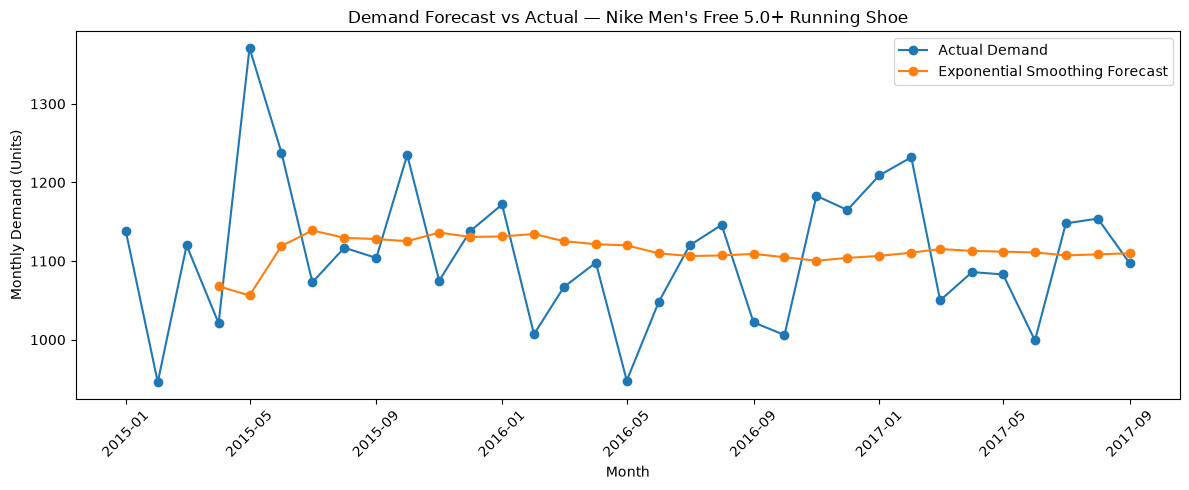

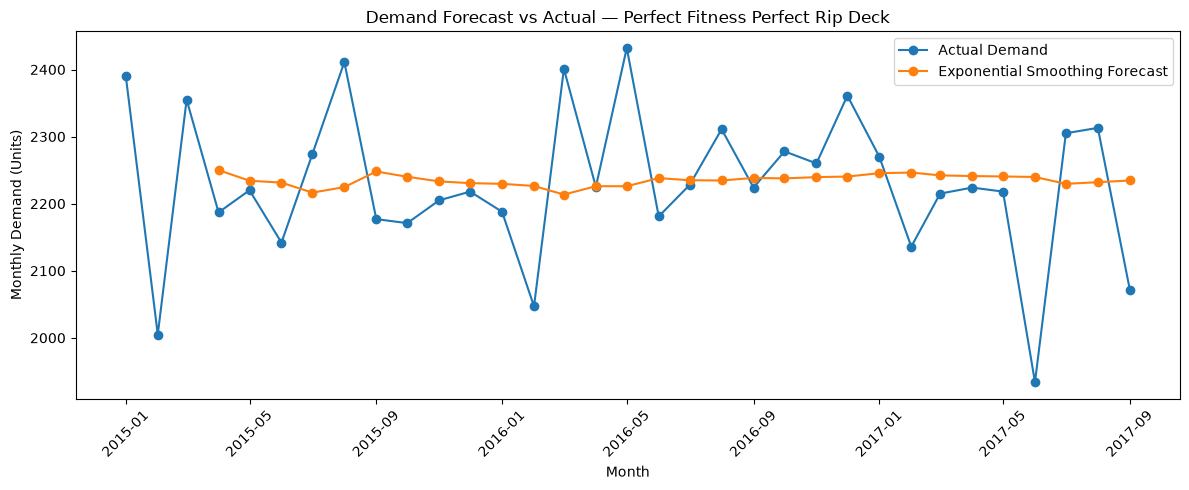

In [273]:
import matplotlib.pyplot as plt

# Visual inspection of the winning forecasting model
# for two representative products.

products_to_plot = [191, 365]

for product_id in products_to_plot:

    actual = (
        forecast_base[
            forecast_base["Product Card Id"] == product_id
        ]
        .sort_values("Month")
    )

    forecast = (
        exp_smoothing_forecast[
            exp_smoothing_forecast["Product Card Id"] == product_id
        ]
        .sort_values("Month")
    )

    product_name = actual["Product Name"].iloc[0]

    plt.figure(figsize=(12, 5))

    plt.plot(
        actual["Month"],
        actual["Demand"],
        marker="o",
        label="Actual Demand"
    )

    plt.plot(
        forecast["Month"],
        forecast["Predicted_Demand"],
        marker="o",
        label="Exponential Smoothing Forecast"
    )

    plt.title(f"Demand Forecast vs Actual — {product_name}")
    plt.xlabel("Month")
    plt.ylabel("Monthly Demand (Units)")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [274]:
# Product-level forecasting error analysis

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

product_error_results = []

# Create a reliable Product ID -> Product Name lookup
product_name_lookup = (
    forecast_base[["Product Card Id", "Product Name"]]
    .drop_duplicates("Product Card Id")
    .set_index("Product Card Id")["Product Name"]
    .to_dict()
)

for product_id, group in exp_smoothing_forecast.groupby("Product Card Id"):

    actual = group["Demand"].values
    predicted = group["Predicted_Demand"].values

    product_name = product_name_lookup[product_id]

    mae = mean_absolute_error(actual, predicted)

    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )

    # Avoid division by zero for MAPE
    non_zero_mask = actual != 0

    mape = (
        np.mean(
            np.abs(
                (actual[non_zero_mask] - predicted[non_zero_mask])
                / actual[non_zero_mask]
            )
        ) * 100
    )

    avg_demand = np.mean(actual)

    product_error_results.append({
        "Product Card Id": product_id,
        "Product Name": product_name,
        "Average Monthly Demand": avg_demand,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape
    })

product_error_analysis = (
    pd.DataFrame(product_error_results)
    .sort_values("MAPE (%)")
    .reset_index(drop=True)
)

product_error_analysis

,Product Card Id,Product Name,Average Monthly Demand,MAE,RMSE,MAPE (%)
0,1004,Field & Stream Sportsman 16 Gun Fire Safe,526.633333,16.650159,21.287566,3.127167
1,365,Perfect Fitness Perfect Rip Deck,2227.600000,78.989636,107.218766,3.586547
2,403,Nike Men's CJ Elite 2 TD Football Cleat,677.800000,26.526923,36.980541,3.933583
3,957,Diamondback Women's Serene Classic Comfort Bi,416.733333,18.182852,20.753569,4.375609
4,502,Nike Men's Dri-FIT Victory Golf Polo,1907.000000,84.297366,108.961644,4.427443
5,1014,O'Brien Men's Neoprene Life Vest,1744.300000,76.911670,101.825233,4.504363
6,1073,Pelican Sunstream 100 Kayak,469.700000,23.171543,27.983578,4.963616
7,627,Under Armour Girls' Toddler Spine Surge Runni,955.400000,51.724562,63.960495,5.586732
8,191,Nike Men's Free 5.0+ Running Shoe,1113.733333,72.775765,94.632838,6.478496


In [275]:
# Inventory Optimization — Step 1
# Calculate forecast-error variability and safety stock

import numpy as np
import pandas as pd

# -----------------------------
# Inventory policy assumptions
# -----------------------------

SERVICE_LEVEL = 0.95
Z_VALUE = 1.645          # Approx. Z-score for 95% service level
LEAD_TIME_MONTHS = 1.0   # Assumed replenishment lead time

# -----------------------------
# Calculate forecast errors
# -----------------------------

inventory_base = exp_smoothing_forecast.copy()

inventory_base["Forecast_Error"] = (
    inventory_base["Demand"]
    - inventory_base["Predicted_Demand"]
)

# -----------------------------
# Product-level inventory stats
# -----------------------------

inventory_stats = (
    inventory_base
    .groupby("Product Card Id")
    .agg(
        Forecast_Error_Std=("Forecast_Error", "std"),
        Avg_Forecast=("Predicted_Demand", "mean"),
        Avg_Demand=("Demand", "mean"),
        Last_Observed_Demand=("Demand", "last")
    )
    .reset_index()
)

# Add product names
inventory_stats["Product Name"] = (
    inventory_stats["Product Card Id"]
    .map(product_name_lookup)
)

# -----------------------------
# Safety Stock
# -----------------------------
# Since demand is monthly and lead time is expressed
# in months, the units remain "demand units".

inventory_stats["Safety_Stock"] = (
    Z_VALUE
    * inventory_stats["Forecast_Error_Std"]
    * np.sqrt(LEAD_TIME_MONTHS)
)

inventory_stats["Safety_Stock"] = (
    np.ceil(inventory_stats["Safety_Stock"])
    .astype(int)
)

# -----------------------------
# Clean presentation
# -----------------------------

inventory_stats = inventory_stats[
    [
        "Product Card Id",
        "Product Name",
        "Avg_Demand",
        "Forecast_Error_Std",
        "Safety_Stock",
        "Last_Observed_Demand"
    ]
].sort_values("Safety_Stock", ascending=False)

inventory_stats.reset_index(drop=True, inplace=True)

inventory_stats

,Product Card Id,Product Name,Avg_Demand,Forecast_Error_Std,Safety_Stock,Last_Observed_Demand
0,502,Nike Men's Dri-FIT Victory Golf Polo,1907.000000,110.789903,183,1969.0
1,365,Perfect Fitness Perfect Rip Deck,2227.600000,108.800980,179,2072.0
2,1014,O'Brien Men's Neoprene Life Vest,1744.300000,101.867475,168,1609.0
3,191,Nike Men's Free 5.0+ Running Shoe,1113.733333,96.249921,159,1097.0
4,627,Under Armour Girls' Toddler Spine Surge Runni,955.400000,63.461894,105,992.0
5,403,Nike Men's CJ Elite 2 TD Football Cleat,677.800000,37.311995,62,662.0
6,1073,Pelican Sunstream 100 Kayak,469.700000,28.419251,47,472.0
7,1004,Field & Stream Sportsman 16 Gun Fire Safe,526.633333,20.306446,34,566.0
8,957,Diamondback Women's Serene Classic Comfort Bi,416.733333,20.533101,34,436.0


In [276]:
# Inventory Optimization — Step 2
# Calculate Reorder Point using the latest demand forecast

# Get the latest forecast for each product
latest_forecast = (
    exp_smoothing_forecast
    .sort_values(["Product Card Id", "Month"])
    .groupby("Product Card Id")
    .tail(1)
    [
        [
            "Product Card Id",
            "Month",
            "Predicted_Demand"
        ]
    ]
    .rename(
        columns={
            "Month": "Forecast_Month",
            "Predicted_Demand": "Latest_Forecast"
        }
    )
)

# Merge with inventory statistics
inventory_policy = inventory_stats.merge(
    latest_forecast,
    on="Product Card Id",
    how="left"
)

# Reorder Point
inventory_policy["Reorder_Point"] = (
    inventory_policy["Latest_Forecast"]
    + inventory_policy["Safety_Stock"]
)

# Round up because inventory is measured in whole units
inventory_policy["Latest_Forecast"] = np.ceil(
    inventory_policy["Latest_Forecast"]
).astype(int)

inventory_policy["Reorder_Point"] = np.ceil(
    inventory_policy["Reorder_Point"]
).astype(int)

# Organize columns
inventory_policy = inventory_policy[
    [
        "Product Card Id",
        "Product Name",
        "Forecast_Month",
        "Latest_Forecast",
        "Safety_Stock",
        "Reorder_Point",
        "Last_Observed_Demand"
    ]
].sort_values(
    "Reorder_Point",
    ascending=False
).reset_index(drop=True)

inventory_policy

,Product Card Id,Product Name,Forecast_Month,Latest_Forecast,Safety_Stock,Reorder_Point,Last_Observed_Demand
0,365,Perfect Fitness Perfect Rip Deck,2017-09-01,2235,179,2414,2072.0
1,502,Nike Men's Dri-FIT Victory Golf Polo,2017-09-01,1904,183,2087,1969.0
2,1014,O'Brien Men's Neoprene Life Vest,2017-09-01,1754,168,1922,1609.0
3,191,Nike Men's Free 5.0+ Running Shoe,2017-09-01,1110,159,1269,1097.0
4,627,Under Armour Girls' Toddler Spine Surge Runni,2017-09-01,960,105,1065,992.0
5,403,Nike Men's CJ Elite 2 TD Football Cleat,2017-09-01,685,62,747,662.0
6,1004,Field & Stream Sportsman 16 Gun Fire Safe,2017-09-01,524,34,558,566.0
7,1073,Pelican Sunstream 100 Kayak,2017-09-01,469,47,516,472.0
8,957,Diamondback Women's Serene Classic Comfort Bi,2017-09-01,415,34,449,436.0


In [277]:
# Product-level price lookup
product_price_lookup = (
    df[["Product Card Id", "Product Price"]]
    .drop_duplicates("Product Card Id")
)

product_price_lookup.head()

,Product Card Id,Product Price
0,1360,327.750000
48,365,59.990002
49,627,39.990002
50,502,50.000000
55,278,44.990002


In [278]:
ORDERING_COST = 50
HOLDING_RATE = 0.20

# -----------------------------
# Calculate annual demand
# -----------------------------

annual_demand = (
    forecast_base
    .groupby("Product Card Id")
    .agg(
        Annual_Demand=("Demand", "mean"),
        Product_Name=("Product Name", "first")
    )
    .reset_index()
)

# Average monthly demand → annual demand
annual_demand["Annual_Demand"] *= 12


# -----------------------------
# Add product price
# -----------------------------

annual_demand = annual_demand.merge(
    product_price_lookup,
    on="Product Card Id",
    how="left"
)


# -----------------------------
# Holding cost
# -----------------------------

annual_demand["Holding_Cost"] = (
    annual_demand["Product Price"] * HOLDING_RATE
)


# -----------------------------
# EOQ calculation
# -----------------------------

annual_demand["EOQ"] = np.sqrt(
    (
        2
        * annual_demand["Annual_Demand"]
        * ORDERING_COST
    )
    / annual_demand["Holding_Cost"]
)

# EOQ must be whole units
annual_demand["EOQ"] = np.ceil(
    annual_demand["EOQ"]
).astype(int)


# -----------------------------
# Final EOQ table
# -----------------------------

eoq_results = (
    annual_demand[
        [
            "Product Card Id",
            "Product_Name",
            "Annual_Demand",
            "Product Price",
            "Holding_Cost",
            "EOQ"
        ]
    ]
    .rename(columns={
        "Product_Name": "Product Name"
    })
    .sort_values(
        "EOQ",
        ascending=False
    )
    .reset_index(drop=True)
)

eoq_results

,Product Card Id,Product Name,Annual_Demand,Product Price,Holding_Cost,EOQ
0,502,Nike Men's Dri-FIT Victory Golf Polo,22864.727273,50.000000,10.000000,479
1,365,Perfect Fitness Perfect Rip Deck,26755.636364,59.990002,11.998000,473
2,1014,O'Brien Men's Neoprene Life Vest,20994.545455,49.980000,9.996000,459
3,627,Under Armour Girls' Toddler Spine Surge Runni,11530.909091,39.990002,7.998000,380
4,191,Nike Men's Free 5.0+ Running Shoe,13314.909091,99.989998,19.998000,259
5,403,Nike Men's CJ Elite 2 TD Football Cleat,8077.818182,129.990005,25.998001,177
6,1073,Pelican Sunstream 100 Kayak,5627.272727,199.990005,39.998001,119
7,957,Diamondback Women's Serene Classic Comfort Bi,4986.909091,299.980011,59.996002,92
8,1004,Field & Stream Sportsman 16 Gun Fire Safe,6293.818182,399.980011,79.996002,89


In [279]:
# Show currently defined DataFrames
{
    name: list(obj.columns)
    for name, obj in globals().items()
    if hasattr(obj, "columns")
}

{'df': ['Type',
  'Days for shipping (real)',
  'Days for shipment (scheduled)',
  'Benefit per order',
  'Sales per customer',
  'Delivery Status',
  'Late_delivery_risk',
  'Category Id',
  'Category Name',
  'Customer City',
  'Customer Country',
  'Customer Email',
  'Customer Fname',
  'Customer Id',
  'Customer Lname',
  'Customer Password',
  'Customer Segment',
  'Customer State',
  'Customer Street',
  'Customer Zipcode',
  'Department Id',
  'Department Name',
  'Latitude',
  'Longitude',
  'Market',
  'Order City',
  'Order Country',
  'Order Customer Id',
  'order date (DateOrders)',
  'Order Id',
  'Order Item Cardprod Id',
  'Order Item Discount',
  'Order Item Discount Rate',
  'Order Item Id',
  'Order Item Product Price',
  'Order Item Profit Ratio',
  'Order Item Quantity',
  'Sales',
  'Order Item Total',
  'Order Profit Per Order',
  'Order Region',
  'Order State',
  'Order Status',
  'Order Zipcode',
  'Product Card Id',
  'Product Category Id',
  'Product Descrip

In [280]:
# -----------------------------------------
# Integrate EOQ with inventory policy
# -----------------------------------------

inventory_optimization = inventory_policy.merge(
    eoq_results[
        [
            "Product Card Id",
            "Annual_Demand",
            "Product Price",
            "Holding_Cost",
            "EOQ"
        ]
    ],
    on="Product Card Id",
    how="left"
)

inventory_optimization.head()

,Product Card Id,Product Name,Forecast_Month,Latest_Forecast,Safety_Stock,Reorder_Point,Last_Observed_Demand,Annual_Demand,Product Price,Holding_Cost,EOQ
0,365,Perfect Fitness Perfect Rip Deck,2017-09-01,2235,179,2414,2072.0,26755.636364,59.990002,11.998,473
1,502,Nike Men's Dri-FIT Victory Golf Polo,2017-09-01,1904,183,2087,1969.0,22864.727273,50.000000,10.000,479
2,1014,O'Brien Men's Neoprene Life Vest,2017-09-01,1754,168,1922,1609.0,20994.545455,49.980000,9.996,459
3,191,Nike Men's Free 5.0+ Running Shoe,2017-09-01,1110,159,1269,1097.0,13314.909091,99.989998,19.998,259
4,627,Under Armour Girls' Toddler Spine Surge Runni,2017-09-01,960,105,1065,992.0,11530.909091,39.990002,7.998,380


In [281]:
inventory_optimization.shape

(9, 11)

In [282]:
inventory_optimization.isna().sum()

Product Card Id         0
Product Name            0
Forecast_Month          0
Latest_Forecast         0
Safety_Stock            0
Reorder_Point           0
Last_Observed_Demand    0
Annual_Demand           0
Product Price           0
Holding_Cost            0
EOQ                     0
dtype: int64

In [283]:
inventory_optimization.head()

,Product Card Id,Product Name,Forecast_Month,Latest_Forecast,Safety_Stock,Reorder_Point,Last_Observed_Demand,Annual_Demand,Product Price,Holding_Cost,EOQ
0,365,Perfect Fitness Perfect Rip Deck,2017-09-01,2235,179,2414,2072.0,26755.636364,59.990002,11.998,473
1,502,Nike Men's Dri-FIT Victory Golf Polo,2017-09-01,1904,183,2087,1969.0,22864.727273,50.000000,10.000,479
2,1014,O'Brien Men's Neoprene Life Vest,2017-09-01,1754,168,1922,1609.0,20994.545455,49.980000,9.996,459
3,191,Nike Men's Free 5.0+ Running Shoe,2017-09-01,1110,159,1269,1097.0,13314.909091,99.989998,19.998,259
4,627,Under Armour Girls' Toddler Spine Surge Runni,2017-09-01,960,105,1065,992.0,11530.909091,39.990002,7.998,380


In [284]:
inventory_optimization["Recommended_Order_Qty"] = inventory_optimization["EOQ"]

In [285]:
inventory_optimization[
    ["Product Name", "Reorder_Point", "EOQ", "Recommended_Order_Qty"]
]

,Product Name,Reorder_Point,EOQ,Recommended_Order_Qty
0,Perfect Fitness Perfect Rip Deck,2414,473,473
1,Nike Men's Dri-FIT Victory Golf Polo,2087,479,479
2,O'Brien Men's Neoprene Life Vest,1922,459,459
3,Nike Men's Free 5.0+ Running Shoe,1269,259,259
4,Under Armour Girls' Toddler Spine Surge Runni,1065,380,380
5,Nike Men's CJ Elite 2 TD Football Cleat,747,177,177
6,Field & Stream Sportsman 16 Gun Fire Safe,558,89,89
7,Pelican Sunstream 100 Kayak,516,119,119
8,Diamondback Women's Serene Classic Comfort Bi,449,92,92


In [286]:
inventory_optimization["Safety_Stock_Ratio"] = (
    inventory_optimization["Safety_Stock"]
    / inventory_optimization["Reorder_Point"]
)

In [287]:
inventory_optimization["Inventory_Risk"] = pd.cut(
    inventory_optimization["Safety_Stock_Ratio"],
    bins=[-float("inf"), 0.08, 0.15, float("inf")],
    labels=["Low", "Medium", "High"]
)

In [288]:
inventory_optimization[
    ["Product Name", "Safety_Stock", "Reorder_Point", "Safety_Stock_Ratio", "Inventory_Risk"]
]

,Product Name,Safety_Stock,Reorder_Point,Safety_Stock_Ratio,Inventory_Risk
0,Perfect Fitness Perfect Rip Deck,179,2414,0.074151,Low
1,Nike Men's Dri-FIT Victory Golf Polo,183,2087,0.087686,Medium
2,O'Brien Men's Neoprene Life Vest,168,1922,0.087409,Medium
3,Nike Men's Free 5.0+ Running Shoe,159,1269,0.125296,Medium
4,Under Armour Girls' Toddler Spine Surge Runni,105,1065,0.098592,Medium
5,Nike Men's CJ Elite 2 TD Football Cleat,62,747,0.082999,Medium
6,Field & Stream Sportsman 16 Gun Fire Safe,34,558,0.060932,Low
7,Pelican Sunstream 100 Kayak,47,516,0.091085,Medium
8,Diamondback Women's Serene Classic Comfort Bi,34,449,0.075724,Low


In [289]:
inventory_optimization["Replenishment_Policy"] = (
    "Order EOQ when inventory reaches Reorder Point"
)

In [290]:
inventory_optimization[
    [
        "Product Name",
        "Latest_Forecast",
        "Safety_Stock",
        "Reorder_Point",
        "EOQ",
        "Recommended_Order_Qty",
        "Inventory_Risk",
        "Replenishment_Policy"
    ]
]

,Product Name,Latest_Forecast,Safety_Stock,Reorder_Point,EOQ,Recommended_Order_Qty,Inventory_Risk,Replenishment_Policy
0,Perfect Fitness Perfect Rip Deck,2235,179,2414,473,473,Low,Order EOQ when inventory reaches Reorder Point
1,Nike Men's Dri-FIT Victory Golf Polo,1904,183,2087,479,479,Medium,Order EOQ when inventory reaches Reorder Point
2,O'Brien Men's Neoprene Life Vest,1754,168,1922,459,459,Medium,Order EOQ when inventory reaches Reorder Point
3,Nike Men's Free 5.0+ Running Shoe,1110,159,1269,259,259,Medium,Order EOQ when inventory reaches Reorder Point
4,Under Armour Girls' Toddler Spine Surge Runni,960,105,1065,380,380,Medium,Order EOQ when inventory reaches Reorder Point
5,Nike Men's CJ Elite 2 TD Football Cleat,685,62,747,177,177,Medium,Order EOQ when inventory reaches Reorder Point
6,Field & Stream Sportsman 16 Gun Fire Safe,524,34,558,89,89,Low,Order EOQ when inventory reaches Reorder Point
7,Pelican Sunstream 100 Kayak,469,47,516,119,119,Medium,Order EOQ when inventory reaches Reorder Point
8,Diamondback Women's Serene Classic Comfort Bi,415,34,449,92,92,Low,Order EOQ when inventory reaches Reorder Point


In [291]:
inventory_optimization["EOQ_Inventory_Value"] = (
    inventory_optimization["EOQ"] *
    inventory_optimization["Product Price"]
)

In [292]:
inventory_optimization[
    ["Product Name", "EOQ", "Product Price", "EOQ_Inventory_Value"]
]

,Product Name,EOQ,Product Price,EOQ_Inventory_Value
0,Perfect Fitness Perfect Rip Deck,473,59.990002,28375.270795
1,Nike Men's Dri-FIT Victory Golf Polo,479,50.000000,23950.000000
2,O'Brien Men's Neoprene Life Vest,459,49.980000,22940.819789
3,Nike Men's Free 5.0+ Running Shoe,259,99.989998,25897.409446
4,Under Armour Girls' Toddler Spine Surge Runni,380,39.990002,15196.200638
5,Nike Men's CJ Elite 2 TD Football Cleat,177,129.990005,23008.230973
6,Field & Stream Sportsman 16 Gun Fire Safe,89,399.980011,35598.220979
7,Pelican Sunstream 100 Kayak,119,199.990005,23798.810655
8,Diamondback Women's Serene Classic Comfort Bi,92,299.980011,27598.161012


In [293]:
inventory_optimization["Safety_Stock_Value"] = (
    inventory_optimization["Safety_Stock"] *
    inventory_optimization["Product Price"]
)

In [294]:
inventory_optimization[
    ["Product Name", "Safety_Stock", "Product Price", "Safety_Stock_Value"]
]

,Product Name,Safety_Stock,Product Price,Safety_Stock_Value
0,Perfect Fitness Perfect Rip Deck,179,59.990002,10738.210301
1,Nike Men's Dri-FIT Victory Golf Polo,183,50.000000,9150.000000
2,O'Brien Men's Neoprene Life Vest,168,49.980000,8396.639923
3,Nike Men's Free 5.0+ Running Shoe,159,99.989998,15898.409660
4,Under Armour Girls' Toddler Spine Surge Runni,105,39.990002,4198.950176
5,Nike Men's CJ Elite 2 TD Football Cleat,62,129.990005,8059.380341
6,Field & Stream Sportsman 16 Gun Fire Safe,34,399.980011,13599.320374
7,Pelican Sunstream 100 Kayak,47,199.990005,9399.530258
8,Diamondback Women's Serene Classic Comfort Bi,34,299.980011,10199.320374


In [295]:
inventory_optimization["Reorder_Point_Value"] = (
    inventory_optimization["Reorder_Point"] *
    inventory_optimization["Product Price"]
)

In [296]:
inventory_optimization[
    ["Product Name", "Reorder_Point", "Product Price", "Reorder_Point_Value"]
]

,Product Name,Reorder_Point,Product Price,Reorder_Point_Value
0,Perfect Fitness Perfect Rip Deck,2414,59.990002,144815.864056
1,Nike Men's Dri-FIT Victory Golf Polo,2087,50.000000,104350.000000
2,O'Brien Men's Neoprene Life Vest,1922,49.980000,96061.559116
3,Nike Men's Free 5.0+ Running Shoe,1269,99.989998,126887.307284
4,Under Armour Girls' Toddler Spine Surge Runni,1065,39.990002,42589.351789
5,Nike Men's CJ Elite 2 TD Football Cleat,747,129.990005,97102.534108
6,Field & Stream Sportsman 16 Gun Fire Safe,558,399.980011,223188.846138
7,Pelican Sunstream 100 Kayak,516,199.990005,103194.842838
8,Diamondback Women's Serene Classic Comfort Bi,449,299.980011,134691.024939


In [297]:
inventory_optimization["Total_Reorder_Point_Value"] = (
    inventory_optimization["Reorder_Point_Value"]
)

In [298]:
total_rop_value = inventory_optimization["Reorder_Point_Value"].sum()

print(f"Total Reorder Point Inventory Value: ${total_rop_value:,.2f}")

Total Reorder Point Inventory Value: $1,072,881.33


In [299]:
total_eoq_value = inventory_optimization["EOQ_Inventory_Value"].sum()

print(f"Total EOQ Inventory Value: ${total_eoq_value:,.2f}")

Total EOQ Inventory Value: $226,363.12


In [300]:
total_safety_stock_value = inventory_optimization["Safety_Stock_Value"].sum()

print(f"Total Safety Stock Value: ${total_safety_stock_value:,.2f}")

Total Safety Stock Value: $89,639.76


In [301]:
safety_stock_value_pct = (
    total_safety_stock_value / total_rop_value
) * 100

print(f"Safety Stock as % of Reorder Point Value: {safety_stock_value_pct:.2f}%")

Safety Stock as % of Reorder Point Value: 8.36%


In [302]:
inventory_optimization[
    [
        "Product Name",
        "Reorder_Point",
        "Product Price",
        "Reorder_Point_Value"
    ]
].sort_values(
    "Reorder_Point_Value",
    ascending=False
)

,Product Name,Reorder_Point,Product Price,Reorder_Point_Value
6,Field & Stream Sportsman 16 Gun Fire Safe,558,399.980011,223188.846138
0,Perfect Fitness Perfect Rip Deck,2414,59.990002,144815.864056
8,Diamondback Women's Serene Classic Comfort Bi,449,299.980011,134691.024939
3,Nike Men's Free 5.0+ Running Shoe,1269,99.989998,126887.307284
1,Nike Men's Dri-FIT Victory Golf Polo,2087,50.000000,104350.000000
7,Pelican Sunstream 100 Kayak,516,199.990005,103194.842838
5,Nike Men's CJ Elite 2 TD Football Cleat,747,129.990005,97102.534108
2,O'Brien Men's Neoprene Life Vest,1922,49.980000,96061.559116
4,Under Armour Girls' Toddler Spine Surge Runni,1065,39.990002,42589.351789


In [303]:
inventory_optimization["ROP_Value_Pct"] = (
    inventory_optimization["Reorder_Point_Value"]
    / inventory_optimization["Reorder_Point_Value"].sum()
) * 100

In [304]:
inventory_optimization[
    [
        "Product Name",
        "Reorder_Point_Value",
        "ROP_Value_Pct"
    ]
].sort_values(
    "ROP_Value_Pct",
    ascending=False
)

,Product Name,Reorder_Point_Value,ROP_Value_Pct
6,Field & Stream Sportsman 16 Gun Fire Safe,223188.846138,20.802752
0,Perfect Fitness Perfect Rip Deck,144815.864056,13.497845
8,Diamondback Women's Serene Classic Comfort Bi,134691.024939,12.554140
3,Nike Men's Free 5.0+ Running Shoe,126887.307284,11.826779
1,Nike Men's Dri-FIT Victory Golf Polo,104350.000000,9.726146
7,Pelican Sunstream 100 Kayak,103194.842838,9.618477
5,Nike Men's CJ Elite 2 TD Football Cleat,97102.534108,9.050631
2,O'Brien Men's Neoprene Life Vest,96061.559116,8.953605
4,Under Armour Girls' Toddler Spine Surge Runni,42589.351789,3.969624


In [305]:
inventory_optimization = inventory_optimization.sort_values(
    "Reorder_Point_Value",
    ascending=False
).reset_index(drop=True)

inventory_optimization["Cumulative_ROP_Value_Pct"] = (
    inventory_optimization["ROP_Value_Pct"].cumsum()
)

In [306]:
inventory_optimization[
    [
        "Product Name",
        "Reorder_Point_Value",
        "ROP_Value_Pct",
        "Cumulative_ROP_Value_Pct"
    ]
]

,Product Name,Reorder_Point_Value,ROP_Value_Pct,Cumulative_ROP_Value_Pct
0,Field & Stream Sportsman 16 Gun Fire Safe,223188.846138,20.802752,20.802752
1,Perfect Fitness Perfect Rip Deck,144815.864056,13.497845,34.300598
2,Diamondback Women's Serene Classic Comfort Bi,134691.024939,12.554140,46.854738
3,Nike Men's Free 5.0+ Running Shoe,126887.307284,11.826779,58.681517
4,Nike Men's Dri-FIT Victory Golf Polo,104350.000000,9.726146,68.407663
5,Pelican Sunstream 100 Kayak,103194.842838,9.618477,78.026140
6,Nike Men's CJ Elite 2 TD Football Cleat,97102.534108,9.050631,87.076771
7,O'Brien Men's Neoprene Life Vest,96061.559116,8.953605,96.030376
8,Under Armour Girls' Toddler Spine Surge Runni,42589.351789,3.969624,100.000000


In [307]:
inventory_optimization["ABC_Class"] = np.select(
    [
        inventory_optimization["Cumulative_ROP_Value_Pct"] <= 70,
        inventory_optimization["Cumulative_ROP_Value_Pct"] <= 90
    ],
    [
        "A",
        "B"
    ],
    default="C"
)

In [308]:
inventory_optimization[
    [
        "Product Name",
        "ROP_Value_Pct",
        "Cumulative_ROP_Value_Pct",
        "ABC_Class"
    ]
]

,Product Name,ROP_Value_Pct,Cumulative_ROP_Value_Pct,ABC_Class
0,Field & Stream Sportsman 16 Gun Fire Safe,20.802752,20.802752,A
1,Perfect Fitness Perfect Rip Deck,13.497845,34.300598,A
2,Diamondback Women's Serene Classic Comfort Bi,12.554140,46.854738,A
3,Nike Men's Free 5.0+ Running Shoe,11.826779,58.681517,A
4,Nike Men's Dri-FIT Victory Golf Polo,9.726146,68.407663,A
5,Pelican Sunstream 100 Kayak,9.618477,78.026140,B
6,Nike Men's CJ Elite 2 TD Football Cleat,9.050631,87.076771,B
7,O'Brien Men's Neoprene Life Vest,8.953605,96.030376,C
8,Under Armour Girls' Toddler Spine Surge Runni,3.969624,100.000000,C


In [309]:
inventory_optimization["Inventory_Priority"] = (
    inventory_optimization["ABC_Class"].astype(str)
    + " - "
    + inventory_optimization["Inventory_Risk"].astype(str)
)

In [310]:
inventory_optimization[
    [
        "Product Name",
        "ABC_Class",
        "Inventory_Risk",
        "Inventory_Priority"
    ]
]

,Product Name,ABC_Class,Inventory_Risk,Inventory_Priority
0,Field & Stream Sportsman 16 Gun Fire Safe,A,Low,A - Low
1,Perfect Fitness Perfect Rip Deck,A,Low,A - Low
2,Diamondback Women's Serene Classic Comfort Bi,A,Low,A - Low
3,Nike Men's Free 5.0+ Running Shoe,A,Medium,A - Medium
4,Nike Men's Dri-FIT Victory Golf Polo,A,Medium,A - Medium
5,Pelican Sunstream 100 Kayak,B,Medium,B - Medium
6,Nike Men's CJ Elite 2 TD Football Cleat,B,Medium,B - Medium
7,O'Brien Men's Neoprene Life Vest,C,Medium,C - Medium
8,Under Armour Girls' Toddler Spine Surge Runni,C,Medium,C - Medium


In [311]:
abc_summary = (
    inventory_optimization
    .groupby("ABC_Class", observed=True)
    .agg(
        Products=("Product Card Id", "count"),
        Total_ROP_Value=("Reorder_Point_Value", "sum"),
        Total_Safety_Stock_Value=("Safety_Stock_Value", "sum"),
        Total_EOQ_Value=("EOQ_Inventory_Value", "sum")
    )
    .reset_index()
)

abc_summary

,ABC_Class,Products,Total_ROP_Value,Total_Safety_Stock_Value,Total_EOQ_Value
0,A,5,733933.042417,59585.260708,141419.062231
1,B,2,200297.376946,17458.910599,46807.041628
2,C,2,138650.910905,12595.590099,38137.020427


In [312]:
abc_summary["ROP_Value_Pct"] = (
    abc_summary["Total_ROP_Value"]
    / abc_summary["Total_ROP_Value"].sum()
) * 100

abc_summary

,ABC_Class,Products,Total_ROP_Value,Total_Safety_Stock_Value,Total_EOQ_Value,ROP_Value_Pct
0,A,5,733933.042417,59585.260708,141419.062231,68.407663
1,B,2,200297.376946,17458.910599,46807.041628,18.669108
2,C,2,138650.910905,12595.590099,38137.020427,12.923229


In [313]:
risk_summary = (
    inventory_optimization
    .groupby("Inventory_Risk", observed=True)
    .agg(
        Products=("Product Card Id", "count"),
        Total_ROP_Value=("Reorder_Point_Value", "sum"),
        Total_Safety_Stock_Value=("Safety_Stock_Value", "sum"),
        Total_EOQ_Value=("EOQ_Inventory_Value", "sum")
    )
    .reset_index()
)

risk_summary

,Inventory_Risk,Products,Total_ROP_Value,Total_Safety_Stock_Value,Total_EOQ_Value
0,Low,3,502695.735133,34536.851049,91571.652786
1,Medium,6,570185.595136,55102.910358,134791.471501


In [314]:
risk_summary["ROP_Value_Pct"] = (
    risk_summary["Total_ROP_Value"]
    / risk_summary["Total_ROP_Value"].sum()
) * 100

risk_summary

,Inventory_Risk,Products,Total_ROP_Value,Total_Safety_Stock_Value,Total_EOQ_Value,ROP_Value_Pct
0,Low,3,502695.735133,34536.851049,91571.652786,46.854738
1,Medium,6,570185.595136,55102.910358,134791.471501,53.145262


In [315]:
inventory_kpis = pd.DataFrame({
    "Metric": [
        "Total Products",
        "Total Annual Demand",
        "Total ROP Value",
        "Total Safety Stock Value",
        "Total EOQ Value",
        "Safety Stock % of ROP Value",
        "Low Risk Products",
        "Medium Risk Products",
        "High Risk Products"
    ],
    "Value": [
        inventory_optimization["Product Card Id"].nunique(),
        inventory_optimization["Annual_Demand"].sum(),
        inventory_optimization["Reorder_Point_Value"].sum(),
        inventory_optimization["Safety_Stock_Value"].sum(),
        inventory_optimization["EOQ_Inventory_Value"].sum(),
        (
            inventory_optimization["Safety_Stock_Value"].sum()
            / inventory_optimization["Reorder_Point_Value"].sum()
        ) * 100,
        (inventory_optimization["Inventory_Risk"] == "Low").sum(),
        (inventory_optimization["Inventory_Risk"] == "Medium").sum(),
        (inventory_optimization["Inventory_Risk"] == "High").sum()
    ]
})

inventory_kpis

,Metric,Value
0,Total Products,9.000000e+00
1,Total Annual Demand,1.204465e+05
2,Total ROP Value,1.072881e+06
3,Total Safety Stock Value,8.963976e+04
4,Total EOQ Value,2.263631e+05
5,Safety Stock % of ROP Value,8.355049e+00
6,Low Risk Products,3.000000e+00
7,Medium Risk Products,6.000000e+00
8,High Risk Products,0.000000e+00


In [316]:
inventory_decisions = inventory_optimization[
    [
        "Product Card Id",
        "Product Name",
        "Forecast_Month",
        "Latest_Forecast",
        "Annual_Demand",
        "Safety_Stock",
        "Reorder_Point",
        "EOQ",
        "ABC_Class",
        "Inventory_Risk",
        "Inventory_Priority"
    ]
].copy()

inventory_decisions["Recommended_Action"] = np.select(
    [
        inventory_decisions["Inventory_Priority"].str.startswith("A - Medium"),
        inventory_decisions["Inventory_Priority"].str.startswith("B - Medium"),
        inventory_decisions["Inventory_Priority"].str.startswith("C - Medium"),
        inventory_decisions["Inventory_Priority"].str.startswith("A - Low")
    ],
    [
        "Prioritize replenishment monitoring",
        "Monitor replenishment closely",
        "Review replenishment frequency",
        "Standard EOQ replenishment"
    ],
    default="Standard replenishment"
)

inventory_decisions

,Product Card Id,Product Name,Forecast_Month,Latest_Forecast,Annual_Demand,Safety_Stock,Reorder_Point,EOQ,ABC_Class,Inventory_Risk,Inventory_Priority,Recommended_Action
0,1004,Field & Stream Sportsman 16 Gun Fire Safe,2017-09-01,524,6293.818182,34,558,89,A,Low,A - Low,Standard EOQ replenishment
1,365,Perfect Fitness Perfect Rip Deck,2017-09-01,2235,26755.636364,179,2414,473,A,Low,A - Low,Standard EOQ replenishment
2,957,Diamondback Women's Serene Classic Comfort Bi,2017-09-01,415,4986.909091,34,449,92,A,Low,A - Low,Standard EOQ replenishment
3,191,Nike Men's Free 5.0+ Running Shoe,2017-09-01,1110,13314.909091,159,1269,259,A,Medium,A - Medium,Prioritize replenishment monitoring
4,502,Nike Men's Dri-FIT Victory Golf Polo,2017-09-01,1904,22864.727273,183,2087,479,A,Medium,A - Medium,Prioritize replenishment monitoring
5,1073,Pelican Sunstream 100 Kayak,2017-09-01,469,5627.272727,47,516,119,B,Medium,B - Medium,Monitor replenishment closely
6,403,Nike Men's CJ Elite 2 TD Football Cleat,2017-09-01,685,8077.818182,62,747,177,B,Medium,B - Medium,Monitor replenishment closely
7,1014,O'Brien Men's Neoprene Life Vest,2017-09-01,1754,20994.545455,168,1922,459,C,Medium,C - Medium,Review replenishment frequency
8,627,Under Armour Girls' Toddler Spine Surge Runni,2017-09-01,960,11530.909091,105,1065,380,C,Medium,C - Medium,Review replenishment frequency


In [317]:
scenario_base = inventory_optimization[
    [
        "Product Card Id",
        "Product Name",
        "Annual_Demand",
        "Latest_Forecast",
        "Safety_Stock",
        "Reorder_Point",
        "EOQ",
        "Product Price"
    ]
].copy()

scenario_base["Monthly_Demand"] = (
    scenario_base["Annual_Demand"] / 12
)

scenario_base

,Product Card Id,Product Name,Annual_Demand,Latest_Forecast,Safety_Stock,Reorder_Point,EOQ,Product Price,Monthly_Demand
0,1004,Field & Stream Sportsman 16 Gun Fire Safe,6293.818182,524,34,558,89,399.980011,524.484848
1,365,Perfect Fitness Perfect Rip Deck,26755.636364,2235,179,2414,473,59.990002,2229.636364
2,957,Diamondback Women's Serene Classic Comfort Bi,4986.909091,415,34,449,92,299.980011,415.575758
3,191,Nike Men's Free 5.0+ Running Shoe,13314.909091,1110,159,1269,259,99.989998,1109.575758
4,502,Nike Men's Dri-FIT Victory Golf Polo,22864.727273,1904,183,2087,479,50.000000,1905.393939
5,1073,Pelican Sunstream 100 Kayak,5627.272727,469,47,516,119,199.990005,468.939394
6,403,Nike Men's CJ Elite 2 TD Football Cleat,8077.818182,685,62,747,177,129.990005,673.151515
7,1014,O'Brien Men's Neoprene Life Vest,20994.545455,1754,168,1922,459,49.980000,1749.545455
8,627,Under Armour Girls' Toddler Spine Surge Runni,11530.909091,960,105,1065,380,39.990002,960.909091


In [318]:
DEMAND_CHANGE_PCT = 10

scenario_demand = scenario_base.copy()

scenario_demand["Scenario_Demand"] = (
    scenario_demand["Monthly_Demand"]
    * (1 + DEMAND_CHANGE_PCT / 100)
)

scenario_demand[
    [
        "Product Card Id",
        "Product Name",
        "Monthly_Demand",
        "Scenario_Demand"
    ]
]

,Product Card Id,Product Name,Monthly_Demand,Scenario_Demand
0,1004,Field & Stream Sportsman 16 Gun Fire Safe,524.484848,576.933333
1,365,Perfect Fitness Perfect Rip Deck,2229.636364,2452.600000
2,957,Diamondback Women's Serene Classic Comfort Bi,415.575758,457.133333
3,191,Nike Men's Free 5.0+ Running Shoe,1109.575758,1220.533333
4,502,Nike Men's Dri-FIT Victory Golf Polo,1905.393939,2095.933333
5,1073,Pelican Sunstream 100 Kayak,468.939394,515.833333
6,403,Nike Men's CJ Elite 2 TD Football Cleat,673.151515,740.466667
7,1014,O'Brien Men's Neoprene Life Vest,1749.545455,1924.500000
8,627,Under Armour Girls' Toddler Spine Surge Runni,960.909091,1057.000000


In [319]:
scenario_demand["Scenario_Safety_Stock"] = (
    scenario_demand["Safety_Stock"]
    * (1 + DEMAND_CHANGE_PCT / 100)
)

scenario_demand["Scenario_ROP"] = (
    scenario_demand["Scenario_Demand"]
    + scenario_demand["Scenario_Safety_Stock"]
)

scenario_demand[
    [
        "Product Card Id",
        "Product Name",
        "Reorder_Point",
        "Safety_Stock",
        "Scenario_Safety_Stock",
        "Scenario_ROP"
    ]
]

,Product Card Id,Product Name,Reorder_Point,Safety_Stock,Scenario_Safety_Stock,Scenario_ROP
0,1004,Field & Stream Sportsman 16 Gun Fire Safe,558,34,37.4,614.333333
1,365,Perfect Fitness Perfect Rip Deck,2414,179,196.9,2649.500000
2,957,Diamondback Women's Serene Classic Comfort Bi,449,34,37.4,494.533333
3,191,Nike Men's Free 5.0+ Running Shoe,1269,159,174.9,1395.433333
4,502,Nike Men's Dri-FIT Victory Golf Polo,2087,183,201.3,2297.233333
5,1073,Pelican Sunstream 100 Kayak,516,47,51.7,567.533333
6,403,Nike Men's CJ Elite 2 TD Football Cleat,747,62,68.2,808.666667
7,1014,O'Brien Men's Neoprene Life Vest,1922,168,184.8,2109.300000
8,627,Under Armour Girls' Toddler Spine Surge Runni,1065,105,115.5,1172.500000


In [320]:
scenario_demand["Baseline_ROP_Value"] = (
    scenario_demand["Reorder_Point"]
    * scenario_demand["Product Price"]
)

scenario_demand["Scenario_ROP_Value"] = (
    scenario_demand["Scenario_ROP"]
    * scenario_demand["Product Price"]
)

scenario_demand["Additional_ROP_Value"] = (
    scenario_demand["Scenario_ROP_Value"]
    - scenario_demand["Baseline_ROP_Value"]
)

scenario_demand[
    [
        "Product Card Id",
        "Product Name",
        "Baseline_ROP_Value",
        "Scenario_ROP_Value",
        "Additional_ROP_Value"
    ]
].sort_values(
    "Additional_ROP_Value",
    ascending=False
)

,Product Card Id,Product Name,Baseline_ROP_Value,Scenario_ROP_Value,Additional_ROP_Value
0,1004,Field & Stream Sportsman 16 Gun Fire Safe,223188.846138,245721.053424,22532.207286
1,365,Perfect Fitness Perfect Rip Deck,144815.864056,158943.509451,14127.645396
2,957,Diamondback Women's Serene Classic Comfort Bi,134691.024939,148350.114773,13659.089834
3,191,Nike Men's Free 5.0+ Running Shoe,126887.307284,139529.376014,12642.068729
4,502,Nike Men's Dri-FIT Victory Golf Polo,104350.000000,114861.666667,10511.666667
5,1073,Pelican Sunstream 100 Kayak,103194.842838,113500.994455,10306.151617
7,1014,O'Brien Men's Neoprene Life Vest,96061.559116,105422.813030,9361.253914
6,403,Nike Men's CJ Elite 2 TD Football Cleat,97102.534108,105118.584448,8016.050339
8,627,Under Armour Girls' Toddler Spine Surge Runni,42589.351789,46888.276970,4298.925181


In [321]:
scenario_impact = pd.DataFrame({
    "Metric": [
        "Baseline ROP Value",
        "Scenario ROP Value",
        "Additional ROP Value",
        "Increase in ROP Value (%)"
    ],
    "Value": [
        scenario_demand["Baseline_ROP_Value"].sum(),
        scenario_demand["Scenario_ROP_Value"].sum(),
        scenario_demand["Additional_ROP_Value"].sum(),
        (
            (
                scenario_demand["Scenario_ROP_Value"].sum()
                - scenario_demand["Baseline_ROP_Value"].sum()
            )
            / scenario_demand["Baseline_ROP_Value"].sum()
        ) * 100
    ]
})

scenario_impact

,Metric,Value
0,Baseline ROP Value,1.072881e+06
1,Scenario ROP Value,1.178336e+06
2,Additional ROP Value,1.054551e+05
3,Increase in ROP Value (%),9.829145e+00


In [323]:
LEAD_TIME_CHANGE_PCT = 20

In [324]:
lead_time_by_product = (
    df_clean.groupby("Product Card Id")
    ["Days for shipping (real)"]
    .mean()
    .reset_index(name="Baseline_Lead_Time_Days")
)

scenario_lead_time = scenario_base.merge(
    lead_time_by_product,
    on="Product Card Id",
    how="left"
)

scenario_lead_time["Scenario_Lead_Time_Days"] = (
    scenario_lead_time["Baseline_Lead_Time_Days"]
    * (1 + LEAD_TIME_CHANGE_PCT / 100)
)

scenario_lead_time[
    [
        "Product Card Id",
        "Product Name",
        "Baseline_Lead_Time_Days",
        "Scenario_Lead_Time_Days"
    ]
]

,Product Card Id,Product Name,Baseline_Lead_Time_Days,Scenario_Lead_Time_Days
0,1004,Field & Stream Sportsman 16 Gun Fire Safe,3.502049,4.202459
1,365,Perfect Fitness Perfect Rip Deck,3.506384,4.207661
2,957,Diamondback Women's Serene Classic Comfort Bi,3.498215,4.197859
3,191,Nike Men's Free 5.0+ Running Shoe,3.493960,4.192752
4,502,Nike Men's Dri-FIT Victory Golf Polo,3.484716,4.181659
5,1073,Pelican Sunstream 100 Kayak,3.483032,4.179639
6,403,Nike Men's CJ Elite 2 TD Football Cleat,3.501259,4.201510
7,1014,O'Brien Men's Neoprene Life Vest,3.495751,4.194901
8,627,Under Armour Girls' Toddler Spine Surge Runni,3.494584,4.193501


In [325]:
scenario_lead_time["Baseline_Lead_Time_Demand"] = (
    scenario_lead_time["Monthly_Demand"]
    * scenario_lead_time["Baseline_Lead_Time_Days"]
    / 30
)

scenario_lead_time["Scenario_Lead_Time_Demand"] = (
    scenario_lead_time["Monthly_Demand"]
    * scenario_lead_time["Scenario_Lead_Time_Days"]
    / 30
)

scenario_lead_time["Scenario_ROP"] = (
    scenario_lead_time["Scenario_Lead_Time_Demand"]
    + scenario_lead_time["Safety_Stock"]
)

scenario_lead_time[
    [
        "Product Card Id",
        "Product Name",
        "Reorder_Point",
        "Safety_Stock",
        "Baseline_Lead_Time_Demand",
        "Scenario_Lead_Time_Demand",
        "Scenario_ROP"
    ]
]

,Product Card Id,Product Name,Reorder_Point,Safety_Stock,Baseline_Lead_Time_Demand,Scenario_Lead_Time_Demand,Scenario_ROP
0,1004,Field & Stream Sportsman 16 Gun Fire Safe,558,34,61.225722,73.470867,107.470867
1,365,Perfect Fitness Perfect Rip Deck,2414,179,260.598698,312.718437,491.718437
2,957,Diamondback Women's Serene Classic Comfort Bi,449,34,48.459118,58.150942,92.150942
3,191,Nike Men's Free 5.0+ Running Shoe,1269,159,129.227113,155.072535,314.072535
4,502,Nike Men's Dri-FIT Victory Golf Polo,2087,183,221.325222,265.590266,448.590266
5,1073,Pelican Sunstream 100 Kayak,516,47,54.444368,65.333241,112.333241
6,403,Nike Men's CJ Elite 2 TD Football Cleat,747,62,78.562586,94.275103,156.275103
7,1014,O'Brien Men's Neoprene Life Vest,1922,168,203.865834,244.639001,412.639001
8,627,Under Armour Girls' Toddler Spine Surge Runni,1065,105,111.932590,134.319107,239.319107


In [326]:
scenario_lead_time["Baseline_ROP"] = (
    scenario_lead_time["Baseline_Lead_Time_Demand"]
    + scenario_lead_time["Safety_Stock"]
)

scenario_lead_time["ROP_Increase_Units"] = (
    scenario_lead_time["Scenario_ROP"]
    - scenario_lead_time["Baseline_ROP"]
)

scenario_lead_time["ROP_Increase_Pct"] = (
    scenario_lead_time["ROP_Increase_Units"]
    / scenario_lead_time["Baseline_ROP"]
) * 100

scenario_lead_time[
    [
        "Product Card Id",
        "Product Name",
        "Baseline_ROP",
        "Scenario_ROP",
        "ROP_Increase_Units",
        "ROP_Increase_Pct"
    ]
].sort_values(
    "ROP_Increase_Units",
    ascending=False
)

,Product Card Id,Product Name,Baseline_ROP,Scenario_ROP,ROP_Increase_Units,ROP_Increase_Pct
1,365,Perfect Fitness Perfect Rip Deck,439.598698,491.718437,52.119740,11.856209
4,502,Nike Men's Dri-FIT Victory Golf Polo,404.325222,448.590266,44.265044,10.947881
7,1014,O'Brien Men's Neoprene Life Vest,371.865834,412.639001,40.773167,10.964483
3,191,Nike Men's Free 5.0+ Running Shoe,288.227113,314.072535,25.845423,8.967034
8,627,Under Armour Girls' Toddler Spine Surge Runni,216.932590,239.319107,22.386518,10.319573
6,403,Nike Men's CJ Elite 2 TD Football Cleat,140.562586,156.275103,15.712517,11.178307
0,1004,Field & Stream Sportsman 16 Gun Fire Safe,95.225722,107.470867,12.245144,12.859072
5,1073,Pelican Sunstream 100 Kayak,101.444368,112.333241,10.888874,10.733837
2,957,Diamondback Women's Serene Classic Comfort Bi,82.459118,92.150942,9.691824,11.753489


In [327]:
scenario_lead_time["Baseline_ROP_Value"] = (
    scenario_lead_time["Baseline_ROP"]
    * scenario_lead_time["Product Price"]
)

scenario_lead_time["Scenario_ROP_Value"] = (
    scenario_lead_time["Scenario_ROP"]
    * scenario_lead_time["Product Price"]
)

scenario_lead_time["Additional_ROP_Value"] = (
    scenario_lead_time["Scenario_ROP_Value"]
    - scenario_lead_time["Baseline_ROP_Value"]
)

scenario_lead_time[
    [
        "Product Card Id",
        "Product Name",
        "Baseline_ROP_Value",
        "Scenario_ROP_Value",
        "Additional_ROP_Value"
    ]
].sort_values(
    "Additional_ROP_Value",
    ascending=False
)

,Product Card Id,Product Name,Baseline_ROP_Value,Scenario_ROP_Value,Additional_ROP_Value
0,1004,Field & Stream Sportsman 16 Gun Fire Safe,38088.385489,42986.198512,4897.813023
1,365,Perfect Fitness Perfect Rip Deck,26371.526610,29498.189872,3126.663262
2,957,Diamondback Women's Serene Classic Comfort Bi,24736.087109,27643.440456,2907.353347
3,191,Nike Men's Free 5.0+ Running Shoe,28819.828390,31404.112135,2584.283746
4,502,Nike Men's Dri-FIT Victory Golf Polo,20216.261085,22429.513302,2213.252217
5,1073,Pelican Sunstream 100 Kayak,20287.859689,22465.525575,2177.665886
6,403,Nike Men's CJ Elite 2 TD Football Cleat,18271.731272,20314.201459,2042.470186
7,1014,O'Brien Men's Neoprene Life Vest,18585.854210,20623.697067,2037.842857
8,627,Under Armour Girls' Toddler Spine Surge Runni,8675.134620,9570.371508,895.236889


In [328]:
lead_time_impact = pd.DataFrame({
    "Metric": [
        "Baseline ROP Value",
        "Scenario ROP Value",
        "Additional ROP Value",
        "Increase in ROP Value (%)"
    ],
    "Value": [
        scenario_lead_time["Baseline_ROP_Value"].sum(),
        scenario_lead_time["Scenario_ROP_Value"].sum(),
        scenario_lead_time["Additional_ROP_Value"].sum(),
        (
            (
                scenario_lead_time["Scenario_ROP_Value"].sum()
                - scenario_lead_time["Baseline_ROP_Value"].sum()
            )
            / scenario_lead_time["Baseline_ROP_Value"].sum()
        ) * 100
    ]
})

lead_time_impact

,Metric,Value
0,Baseline ROP Value,204052.668473
1,Scenario ROP Value,226935.249887
2,Additional ROP Value,22882.581413
3,Increase in ROP Value (%),11.214056


In [329]:
COMBINED_DEMAND_CHANGE_PCT = 10
COMBINED_LEAD_TIME_CHANGE_PCT = 20

scenario_combined = scenario_lead_time.copy()

scenario_combined["Scenario_Demand"] = (
    scenario_combined["Monthly_Demand"]
    * (1 + COMBINED_DEMAND_CHANGE_PCT / 100)
)

scenario_combined["Scenario_Lead_Time_Days"] = (
    scenario_combined["Baseline_Lead_Time_Days"]
    * (1 + COMBINED_LEAD_TIME_CHANGE_PCT / 100)
)

scenario_combined[
    [
        "Product Card Id",
        "Product Name",
        "Monthly_Demand",
        "Baseline_Lead_Time_Days",
        "Scenario_Demand",
        "Scenario_Lead_Time_Days"
    ]
]

,Product Card Id,Product Name,Monthly_Demand,Baseline_Lead_Time_Days,Scenario_Demand,Scenario_Lead_Time_Days
0,1004,Field & Stream Sportsman 16 Gun Fire Safe,524.484848,3.502049,576.933333,4.202459
1,365,Perfect Fitness Perfect Rip Deck,2229.636364,3.506384,2452.600000,4.207661
2,957,Diamondback Women's Serene Classic Comfort Bi,415.575758,3.498215,457.133333,4.197859
3,191,Nike Men's Free 5.0+ Running Shoe,1109.575758,3.493960,1220.533333,4.192752
4,502,Nike Men's Dri-FIT Victory Golf Polo,1905.393939,3.484716,2095.933333,4.181659
5,1073,Pelican Sunstream 100 Kayak,468.939394,3.483032,515.833333,4.179639
6,403,Nike Men's CJ Elite 2 TD Football Cleat,673.151515,3.501259,740.466667,4.201510
7,1014,O'Brien Men's Neoprene Life Vest,1749.545455,3.495751,1924.500000,4.194901
8,627,Under Armour Girls' Toddler Spine Surge Runni,960.909091,3.494584,1057.000000,4.193501


In [330]:
scenario_combined["Baseline_Lead_Time_Demand"] = (
    scenario_combined["Monthly_Demand"]
    * scenario_combined["Baseline_Lead_Time_Days"]
    / 30
)

scenario_combined["Scenario_Lead_Time_Demand"] = (
    scenario_combined["Scenario_Demand"]
    * scenario_combined["Scenario_Lead_Time_Days"]
    / 30
)

scenario_combined["Baseline_ROP"] = (
    scenario_combined["Baseline_Lead_Time_Demand"]
    + scenario_combined["Safety_Stock"]
)

scenario_combined["Scenario_ROP"] = (
    scenario_combined["Scenario_Lead_Time_Demand"]
    + scenario_combined["Safety_Stock"]
)

scenario_combined["ROP_Increase_Units"] = (
    scenario_combined["Scenario_ROP"]
    - scenario_combined["Baseline_ROP"]
)

scenario_combined["ROP_Increase_Pct"] = (
    scenario_combined["ROP_Increase_Units"]
    / scenario_combined["Baseline_ROP"]
) * 100

scenario_combined[
    [
        "Product Card Id",
        "Product Name",
        "Baseline_ROP",
        "Scenario_ROP",
        "ROP_Increase_Units",
        "ROP_Increase_Pct"
    ]
].sort_values(
    "ROP_Increase_Units",
    ascending=False
)

,Product Card Id,Product Name,Baseline_ROP,Scenario_ROP,ROP_Increase_Units,ROP_Increase_Pct
1,365,Perfect Fitness Perfect Rip Deck,439.598698,522.990281,83.391583,18.969934
4,502,Nike Men's Dri-FIT Victory Golf Polo,404.325222,475.149293,70.824071,17.516610
7,1014,O'Brien Men's Neoprene Life Vest,371.865834,437.102901,65.237067,17.543173
3,191,Nike Men's Free 5.0+ Running Shoe,288.227113,329.579789,41.352676,14.347254
8,627,Under Armour Girls' Toddler Spine Surge Runni,216.932590,252.751018,35.818429,16.511318
6,403,Nike Men's CJ Elite 2 TD Football Cleat,140.562586,165.702613,25.140027,17.885291
0,1004,Field & Stream Sportsman 16 Gun Fire Safe,95.225722,114.817954,19.592231,20.574516
5,1073,Pelican Sunstream 100 Kayak,101.444368,118.866566,17.422198,17.174140
2,957,Diamondback Women's Serene Classic Comfort Bi,82.459118,97.966036,15.506918,18.805583


In [331]:
scenario_combined["Baseline_ROP_Value"] = (
    scenario_combined["Baseline_ROP"]
    * scenario_combined["Product Price"]
)

scenario_combined["Scenario_ROP_Value"] = (
    scenario_combined["Scenario_ROP"]
    * scenario_combined["Product Price"]
)

scenario_combined["Additional_ROP_Value"] = (
    scenario_combined["Scenario_ROP_Value"]
    - scenario_combined["Baseline_ROP_Value"]
)

scenario_combined[
    [
        "Product Card Id",
        "Product Name",
        "Baseline_ROP_Value",
        "Scenario_ROP_Value",
        "Additional_ROP_Value"
    ]
].sort_values(
    "Additional_ROP_Value",
    ascending=False
)

,Product Card Id,Product Name,Baseline_ROP_Value,Scenario_ROP_Value,Additional_ROP_Value
0,1004,Field & Stream Sportsman 16 Gun Fire Safe,38088.385489,45924.886326,7836.500837
1,365,Perfect Fitness Perfect Rip Deck,26371.526610,31374.187829,5002.661219
2,957,Diamondback Women's Serene Classic Comfort Bi,24736.087109,29387.852464,4651.765355
3,191,Nike Men's Free 5.0+ Running Shoe,28819.828390,32954.682383,4134.853994
4,502,Nike Men's Dri-FIT Victory Golf Polo,20216.261085,23757.464632,3541.203547
5,1073,Pelican Sunstream 100 Kayak,20287.859689,23772.125106,3484.265418
6,403,Nike Men's CJ Elite 2 TD Football Cleat,18271.731272,21539.683571,3267.952298
7,1014,O'Brien Men's Neoprene Life Vest,18585.854210,21846.402782,3260.548572
8,627,Under Armour Girls' Toddler Spine Surge Runni,8675.134620,10107.513642,1432.379022


In [332]:
combined_impact = pd.DataFrame({
    "Metric": [
        "Baseline ROP Value",
        "Combined Scenario ROP Value",
        "Additional ROP Value",
        "Increase in ROP Value (%)"
    ],
    "Value": [
        scenario_combined["Baseline_ROP_Value"].sum(),
        scenario_combined["Scenario_ROP_Value"].sum(),
        scenario_combined["Additional_ROP_Value"].sum(),
        (
            scenario_combined["Additional_ROP_Value"].sum()
            / scenario_combined["Baseline_ROP_Value"].sum()
        ) * 100
    ]
})

combined_impact

,Metric,Value
0,Baseline ROP Value,204052.668473
1,Combined Scenario ROP Value,240664.798735
2,Additional ROP Value,36612.130261
3,Increase in ROP Value (%),17.942490


In [333]:
def run_inventory_scenario(
    demand_change_pct=0,
    lead_time_change_pct=0,
    safety_stock_change_pct=0
):
    scenario = scenario_lead_time.copy()

    # Scenario demand
    scenario["Scenario_Demand"] = (
        scenario["Monthly_Demand"]
        * (1 + demand_change_pct / 100)
    )

    # Scenario lead time
    scenario["Scenario_Lead_Time_Days"] = (
        scenario["Baseline_Lead_Time_Days"]
        * (1 + lead_time_change_pct / 100)
    )

    # Scenario safety stock
    scenario["Scenario_Safety_Stock"] = (
        scenario["Safety_Stock"]
        * (1 + safety_stock_change_pct / 100)
    )

    # Baseline lead-time demand
    scenario["Baseline_Lead_Time_Demand"] = (
        scenario["Monthly_Demand"]
        * scenario["Baseline_Lead_Time_Days"]
        / 30
    )

    # Scenario lead-time demand
    scenario["Scenario_Lead_Time_Demand"] = (
        scenario["Scenario_Demand"]
        * scenario["Scenario_Lead_Time_Days"]
        / 30
    )

    # Baseline ROP
    scenario["Baseline_ROP"] = (
        scenario["Baseline_Lead_Time_Demand"]
        + scenario["Safety_Stock"]
    )

    # Scenario ROP
    scenario["Scenario_ROP"] = (
        scenario["Scenario_Lead_Time_Demand"]
        + scenario["Scenario_Safety_Stock"]
    )

    # Impact
    scenario["ROP_Increase_Units"] = (
        scenario["Scenario_ROP"]
        - scenario["Baseline_ROP"]
    )

    scenario["ROP_Increase_Pct"] = (
        scenario["ROP_Increase_Units"]
        / scenario["Baseline_ROP"]
    ) * 100

    # Financial impact
    scenario["Baseline_ROP_Value"] = (
        scenario["Baseline_ROP"]
        * scenario["Product Price"]
    )

    scenario["Scenario_ROP_Value"] = (
        scenario["Scenario_ROP"]
        * scenario["Product Price"]
    )

    scenario["Additional_ROP_Value"] = (
        scenario["Scenario_ROP_Value"]
        - scenario["Baseline_ROP_Value"]
    )

    return scenario

In [334]:
scenario_test = run_inventory_scenario(
    demand_change_pct=10,
    lead_time_change_pct=20,
    safety_stock_change_pct=0
)

scenario_test[
    [
        "Product Card Id",
        "Product Name",
        "Scenario_Demand",
        "Scenario_Lead_Time_Days",
        "Scenario_Safety_Stock",
        "Scenario_ROP",
        "ROP_Increase_Units",
        "Additional_ROP_Value"
    ]
]

,Product Card Id,Product Name,Scenario_Demand,Scenario_Lead_Time_Days,Scenario_Safety_Stock,Scenario_ROP,ROP_Increase_Units,Additional_ROP_Value
0,1004,Field & Stream Sportsman 16 Gun Fire Safe,576.933333,4.202459,34.0,114.817954,19.592231,7836.500837
1,365,Perfect Fitness Perfect Rip Deck,2452.600000,4.207661,179.0,522.990281,83.391583,5002.661219
2,957,Diamondback Women's Serene Classic Comfort Bi,457.133333,4.197859,34.0,97.966036,15.506918,4651.765355
3,191,Nike Men's Free 5.0+ Running Shoe,1220.533333,4.192752,159.0,329.579789,41.352676,4134.853994
4,502,Nike Men's Dri-FIT Victory Golf Polo,2095.933333,4.181659,183.0,475.149293,70.824071,3541.203547
5,1073,Pelican Sunstream 100 Kayak,515.833333,4.179639,47.0,118.866566,17.422198,3484.265418
6,403,Nike Men's CJ Elite 2 TD Football Cleat,740.466667,4.201510,62.0,165.702613,25.140027,3267.952298
7,1014,O'Brien Men's Neoprene Life Vest,1924.500000,4.194901,168.0,437.102901,65.237067,3260.548572
8,627,Under Armour Girls' Toddler Spine Surge Runni,1057.000000,4.193501,105.0,252.751018,35.818429,1432.379022


In [335]:
def summarize_scenario(scenario):
    baseline_value = scenario["Baseline_ROP_Value"].sum()
    scenario_value = scenario["Scenario_ROP_Value"].sum()
    additional_value = scenario["Additional_ROP_Value"].sum()

    summary = pd.DataFrame({
        "Metric": [
            "Baseline ROP Value",
            "Scenario ROP Value",
            "Additional ROP Value",
            "Increase in ROP Value (%)"
        ],
        "Value": [
            baseline_value,
            scenario_value,
            additional_value,
            (additional_value / baseline_value) * 100
        ]
    })

    return summary

In [336]:
combined_summary = summarize_scenario(scenario_test)

combined_summary

,Metric,Value
0,Baseline ROP Value,204052.668473
1,Scenario ROP Value,240664.798735
2,Additional ROP Value,36612.130261
3,Increase in ROP Value (%),17.942490


In [337]:
scenario_definitions = {
    "Baseline": {
        "demand_change_pct": 0,
        "lead_time_change_pct": 0,
        "safety_stock_change_pct": 0
    },
    "Demand Surge": {
        "demand_change_pct": 10,
        "lead_time_change_pct": 0,
        "safety_stock_change_pct": 0
    },
    "Lead-Time Disruption": {
        "demand_change_pct": 0,
        "lead_time_change_pct": 20,
        "safety_stock_change_pct": 0
    },
    "Combined Stress": {
        "demand_change_pct": 10,
        "lead_time_change_pct": 20,
        "safety_stock_change_pct": 0
    }
}

scenario_summaries = []

for scenario_name, parameters in scenario_definitions.items():

    result = run_inventory_scenario(**parameters)
    summary = summarize_scenario(result)

    baseline_value = summary.loc[
        summary["Metric"] == "Baseline ROP Value", "Value"
    ].iloc[0]

    scenario_value = summary.loc[
        summary["Metric"] == "Scenario ROP Value", "Value"
    ].iloc[0]

    additional_value = summary.loc[
        summary["Metric"] == "Additional ROP Value", "Value"
    ].iloc[0]

    increase_pct = summary.loc[
        summary["Metric"] == "Increase in ROP Value (%)", "Value"
    ].iloc[0]

    scenario_summaries.append({
        "Scenario": scenario_name,
        "Demand_Change_Pct": parameters["demand_change_pct"],
        "Lead_Time_Change_Pct": parameters["lead_time_change_pct"],
        "Safety_Stock_Change_Pct": parameters["safety_stock_change_pct"],
        "Baseline_ROP_Value": baseline_value,
        "Scenario_ROP_Value": scenario_value,
        "Additional_ROP_Value": additional_value,
        "Increase_in_ROP_Value_Pct": increase_pct
    })

scenario_comparison = pd.DataFrame(scenario_summaries)

scenario_comparison

,Scenario,Demand_Change_Pct,Lead_Time_Change_Pct,Safety_Stock_Change_Pct,Baseline_ROP_Value,Scenario_ROP_Value,Additional_ROP_Value,Increase_in_ROP_Value_Pct
0,Baseline,0,0,0,204052.668473,204052.668473,0.000000,0.000000
1,Demand Surge,10,0,0,204052.668473,215493.959180,11441.290707,5.607028
2,Lead-Time Disruption,0,20,0,204052.668473,226935.249887,22882.581413,11.214056
3,Combined Stress,10,20,0,204052.668473,240664.798735,36612.130261,17.942490


In [338]:
high_service_scenario = run_inventory_scenario(
    demand_change_pct=10,
    lead_time_change_pct=20,
    safety_stock_change_pct=15
)

high_service_summary = summarize_scenario(
    high_service_scenario
)

high_service_summary

,Metric,Value
0,Baseline ROP Value,204052.668473
1,Scenario ROP Value,254110.762946
2,Additional ROP Value,50058.094472
3,Increase in ROP Value (%),24.531948


In [339]:
scenario_definitions_extended = {
    "Baseline": {
        "demand_change_pct": 0,
        "lead_time_change_pct": 0,
        "safety_stock_change_pct": 0
    },
    "Demand Surge": {
        "demand_change_pct": 10,
        "lead_time_change_pct": 0,
        "safety_stock_change_pct": 0
    },
    "Lead-Time Disruption": {
        "demand_change_pct": 0,
        "lead_time_change_pct": 20,
        "safety_stock_change_pct": 0
    },
    "Combined Stress": {
        "demand_change_pct": 10,
        "lead_time_change_pct": 20,
        "safety_stock_change_pct": 0
    },
    "High Protection": {
        "demand_change_pct": 10,
        "lead_time_change_pct": 20,
        "safety_stock_change_pct": 15
    }
}

extended_summaries = []

for scenario_name, parameters in scenario_definitions_extended.items():

    result = run_inventory_scenario(**parameters)
    summary = summarize_scenario(result)

    extended_summaries.append({
        "Scenario": scenario_name,
        "Demand_Change_Pct": parameters["demand_change_pct"],
        "Lead_Time_Change_Pct": parameters["lead_time_change_pct"],
        "Safety_Stock_Change_Pct": parameters["safety_stock_change_pct"],
        "Baseline_ROP_Value": summary.loc[
            summary["Metric"] == "Baseline ROP Value", "Value"
        ].iloc[0],
        "Scenario_ROP_Value": summary.loc[
            summary["Metric"] == "Scenario ROP Value", "Value"
        ].iloc[0],
        "Additional_ROP_Value": summary.loc[
            summary["Metric"] == "Additional ROP Value", "Value"
        ].iloc[0],
        "Increase_in_ROP_Value_Pct": summary.loc[
            summary["Metric"] == "Increase in ROP Value (%)", "Value"
        ].iloc[0]
    })

scenario_comparison_extended = pd.DataFrame(extended_summaries)

scenario_comparison_extended

,Scenario,Demand_Change_Pct,Lead_Time_Change_Pct,Safety_Stock_Change_Pct,Baseline_ROP_Value,Scenario_ROP_Value,Additional_ROP_Value,Increase_in_ROP_Value_Pct
0,Baseline,0,0,0,204052.668473,204052.668473,0.000000,0.000000
1,Demand Surge,10,0,0,204052.668473,215493.959180,11441.290707,5.607028
2,Lead-Time Disruption,0,20,0,204052.668473,226935.249887,22882.581413,11.214056
3,Combined Stress,10,20,0,204052.668473,240664.798735,36612.130261,17.942490
4,High Protection,10,20,15,204052.668473,254110.762946,50058.094472,24.531948


In [340]:
combined_product_impact = run_inventory_scenario(
    demand_change_pct=10,
    lead_time_change_pct=20,
    safety_stock_change_pct=0
)

combined_product_impact = (
    combined_product_impact[
        [
            "Product Card Id",
            "Product Name",
            "Scenario_ROP",
            "ROP_Increase_Units",
            "ROP_Increase_Pct",
            "Additional_ROP_Value"
        ]
    ]
    .sort_values(
        "Additional_ROP_Value",
        ascending=False
    )
    .reset_index(drop=True)
)

combined_product_impact

,Product Card Id,Product Name,Scenario_ROP,ROP_Increase_Units,ROP_Increase_Pct,Additional_ROP_Value
0,1004,Field & Stream Sportsman 16 Gun Fire Safe,114.817954,19.592231,20.574516,7836.500837
1,365,Perfect Fitness Perfect Rip Deck,522.990281,83.391583,18.969934,5002.661219
2,957,Diamondback Women's Serene Classic Comfort Bi,97.966036,15.506918,18.805583,4651.765355
3,191,Nike Men's Free 5.0+ Running Shoe,329.579789,41.352676,14.347254,4134.853994
4,502,Nike Men's Dri-FIT Victory Golf Polo,475.149293,70.824071,17.516610,3541.203547
5,1073,Pelican Sunstream 100 Kayak,118.866566,17.422198,17.174140,3484.265418
6,403,Nike Men's CJ Elite 2 TD Football Cleat,165.702613,25.140027,17.885291,3267.952298
7,1014,O'Brien Men's Neoprene Life Vest,437.102901,65.237067,17.543173,3260.548572
8,627,Under Armour Girls' Toddler Spine Surge Runni,252.751018,35.818429,16.511318,1432.379022


In [341]:
combined_product_impact["Cumulative_Additional_Value"] = (
    combined_product_impact["Additional_ROP_Value"].cumsum()
)

total_additional_value = (
    combined_product_impact["Additional_ROP_Value"].sum()
)

combined_product_impact["Cumulative_Exposure_Pct"] = (
    combined_product_impact["Cumulative_Additional_Value"]
    / total_additional_value
) * 100

combined_product_impact

,Product Card Id,Product Name,Scenario_ROP,ROP_Increase_Units,ROP_Increase_Pct,Additional_ROP_Value,Cumulative_Additional_Value,Cumulative_Exposure_Pct
0,1004,Field & Stream Sportsman 16 Gun Fire Safe,114.817954,19.592231,20.574516,7836.500837,7836.500837,21.404111
1,365,Perfect Fitness Perfect Rip Deck,522.990281,83.391583,18.969934,5002.661219,12839.162056,35.068055
2,957,Diamondback Women's Serene Classic Comfort Bi,97.966036,15.506918,18.805583,4651.765355,17490.927411,47.773586
3,191,Nike Men's Free 5.0+ Running Shoe,329.579789,41.352676,14.347254,4134.853994,21625.781405,59.067258
4,502,Nike Men's Dri-FIT Victory Golf Polo,475.149293,70.824071,17.516610,3541.203547,25166.984952,68.739472
5,1073,Pelican Sunstream 100 Kayak,118.866566,17.422198,17.174140,3484.265418,28651.250369,78.256169
6,403,Nike Men's CJ Elite 2 TD Football Cleat,165.702613,25.140027,17.885291,3267.952298,31919.202667,87.182042
7,1014,O'Brien Men's Neoprene Life Vest,437.102901,65.237067,17.543173,3260.548572,35179.751239,96.087693
8,627,Under Armour Girls' Toddler Spine Surge Runni,252.751018,35.818429,16.511318,1432.379022,36612.130261,100.000000


In [342]:
combined_product_impact["Exposure_Tier"] = pd.cut(
    combined_product_impact["Cumulative_Exposure_Pct"],
    bins=[0, 50, 80, float("inf")],
    labels=[
        "Top Exposure",
        "Moderate Exposure",
        "Lower Exposure"
    ]
)

combined_product_impact[
    [
        "Product Card Id",
        "Product Name",
        "Additional_ROP_Value",
        "Cumulative_Exposure_Pct",
        "Exposure_Tier"
    ]
]

,Product Card Id,Product Name,Additional_ROP_Value,Cumulative_Exposure_Pct,Exposure_Tier
0,1004,Field & Stream Sportsman 16 Gun Fire Safe,7836.500837,21.404111,Top Exposure
1,365,Perfect Fitness Perfect Rip Deck,5002.661219,35.068055,Top Exposure
2,957,Diamondback Women's Serene Classic Comfort Bi,4651.765355,47.773586,Top Exposure
3,191,Nike Men's Free 5.0+ Running Shoe,4134.853994,59.067258,Moderate Exposure
4,502,Nike Men's Dri-FIT Victory Golf Polo,3541.203547,68.739472,Moderate Exposure
5,1073,Pelican Sunstream 100 Kayak,3484.265418,78.256169,Moderate Exposure
6,403,Nike Men's CJ Elite 2 TD Football Cleat,3267.952298,87.182042,Lower Exposure
7,1014,O'Brien Men's Neoprene Life Vest,3260.548572,96.087693,Lower Exposure
8,627,Under Armour Girls' Toddler Spine Surge Runni,1432.379022,100.000000,Lower Exposure


In [343]:
action_map = {
    "Top Exposure": "Prioritize mitigation and replenishment planning",
    "Moderate Exposure": "Monitor closely and review replenishment",
    "Lower Exposure": "Standard monitoring"
}

combined_product_impact["Recommended_Action"] = (
    combined_product_impact["Exposure_Tier"]
    .map(action_map)
)

combined_product_impact[
    [
        "Product Card Id",
        "Product Name",
        "Additional_ROP_Value",
        "Cumulative_Exposure_Pct",
        "Exposure_Tier",
        "Recommended_Action"
    ]
]

,Product Card Id,Product Name,Additional_ROP_Value,Cumulative_Exposure_Pct,Exposure_Tier,Recommended_Action
0,1004,Field & Stream Sportsman 16 Gun Fire Safe,7836.500837,21.404111,Top Exposure,Prioritize mitigation and replenishment planning
1,365,Perfect Fitness Perfect Rip Deck,5002.661219,35.068055,Top Exposure,Prioritize mitigation and replenishment planning
2,957,Diamondback Women's Serene Classic Comfort Bi,4651.765355,47.773586,Top Exposure,Prioritize mitigation and replenishment planning
3,191,Nike Men's Free 5.0+ Running Shoe,4134.853994,59.067258,Moderate Exposure,Monitor closely and review replenishment
4,502,Nike Men's Dri-FIT Victory Golf Polo,3541.203547,68.739472,Moderate Exposure,Monitor closely and review replenishment
5,1073,Pelican Sunstream 100 Kayak,3484.265418,78.256169,Moderate Exposure,Monitor closely and review replenishment
6,403,Nike Men's CJ Elite 2 TD Football Cleat,3267.952298,87.182042,Lower Exposure,Standard monitoring
7,1014,O'Brien Men's Neoprene Life Vest,3260.548572,96.087693,Lower Exposure,Standard monitoring
8,627,Under Armour Girls' Toddler Spine Surge Runni,1432.379022,100.000000,Lower Exposure,Standard monitoring


In [344]:
digital_twin_decisions = (
    combined_product_impact
    .merge(
        inventory_optimization[
            [
                "Product Card Id",
                "ABC_Class",
                "Inventory_Risk",
                "Inventory_Priority"
            ]
        ],
        on="Product Card Id",
        how="left"
    )
)

digital_twin_decisions = digital_twin_decisions[
    [
        "Product Card Id",
        "Product Name",
        "ABC_Class",
        "Inventory_Risk",
        "Inventory_Priority",
        "Scenario_ROP",
        "ROP_Increase_Units",
        "ROP_Increase_Pct",
        "Additional_ROP_Value",
        "Cumulative_Exposure_Pct",
        "Exposure_Tier",
        "Recommended_Action"
    ]
]

digital_twin_decisions

,Product Card Id,Product Name,ABC_Class,Inventory_Risk,Inventory_Priority,Scenario_ROP,ROP_Increase_Units,ROP_Increase_Pct,Additional_ROP_Value,Cumulative_Exposure_Pct,Exposure_Tier,Recommended_Action
0,1004,Field & Stream Sportsman 16 Gun Fire Safe,A,Low,A - Low,114.817954,19.592231,20.574516,7836.500837,21.404111,Top Exposure,Prioritize mitigation and replenishment planning
1,365,Perfect Fitness Perfect Rip Deck,A,Low,A - Low,522.990281,83.391583,18.969934,5002.661219,35.068055,Top Exposure,Prioritize mitigation and replenishment planning
2,957,Diamondback Women's Serene Classic Comfort Bi,A,Low,A - Low,97.966036,15.506918,18.805583,4651.765355,47.773586,Top Exposure,Prioritize mitigation and replenishment planning
3,191,Nike Men's Free 5.0+ Running Shoe,A,Medium,A - Medium,329.579789,41.352676,14.347254,4134.853994,59.067258,Moderate Exposure,Monitor closely and review replenishment
4,502,Nike Men's Dri-FIT Victory Golf Polo,A,Medium,A - Medium,475.149293,70.824071,17.516610,3541.203547,68.739472,Moderate Exposure,Monitor closely and review replenishment
5,1073,Pelican Sunstream 100 Kayak,B,Medium,B - Medium,118.866566,17.422198,17.174140,3484.265418,78.256169,Moderate Exposure,Monitor closely and review replenishment
6,403,Nike Men's CJ Elite 2 TD Football Cleat,B,Medium,B - Medium,165.702613,25.140027,17.885291,3267.952298,87.182042,Lower Exposure,Standard monitoring
7,1014,O'Brien Men's Neoprene Life Vest,C,Medium,C - Medium,437.102901,65.237067,17.543173,3260.548572,96.087693,Lower Exposure,Standard monitoring
8,627,Under Armour Girls' Toddler Spine Surge Runni,C,Medium,C - Medium,252.751018,35.818429,16.511318,1432.379022,100.000000,Lower Exposure,Standard monitoring


In [345]:
digital_twin_summary = pd.DataFrame({
    "Metric": [
        "Baseline ROP Value",
        "Demand Surge ROP Value",
        "Lead-Time Disruption ROP Value",
        "Combined Stress ROP Value",
        "High Protection ROP Value",
        "Combined Stress Additional Exposure",
        "High Protection Additional Exposure"
    ],
    "Value": [
        scenario_comparison_extended.loc[
            scenario_comparison_extended["Scenario"] == "Baseline",
            "Scenario_ROP_Value"
        ].iloc[0],

        scenario_comparison_extended.loc[
            scenario_comparison_extended["Scenario"] == "Demand Surge",
            "Scenario_ROP_Value"
        ].iloc[0],

        scenario_comparison_extended.loc[
            scenario_comparison_extended["Scenario"] == "Lead-Time Disruption",
            "Scenario_ROP_Value"
        ].iloc[0],

        scenario_comparison_extended.loc[
            scenario_comparison_extended["Scenario"] == "Combined Stress",
            "Scenario_ROP_Value"
        ].iloc[0],

        scenario_comparison_extended.loc[
            scenario_comparison_extended["Scenario"] == "High Protection",
            "Scenario_ROP_Value"
        ].iloc[0],

        scenario_comparison_extended.loc[
            scenario_comparison_extended["Scenario"] == "Combined Stress",
            "Additional_ROP_Value"
        ].iloc[0],

        scenario_comparison_extended.loc[
            scenario_comparison_extended["Scenario"] == "High Protection",
            "Additional_ROP_Value"
        ].iloc[0]
    ]
})

digital_twin_summary

,Metric,Value
0,Baseline ROP Value,204052.668473
1,Demand Surge ROP Value,215493.959180
2,Lead-Time Disruption ROP Value,226935.249887
3,Combined Stress ROP Value,240664.798735
4,High Protection ROP Value,254110.762946
5,Combined Stress Additional Exposure,36612.130261
6,High Protection Additional Exposure,50058.094472


In [346]:
powerbi_scenario_summary = scenario_comparison_extended[
    [
        "Scenario",
        "Demand_Change_Pct",
        "Lead_Time_Change_Pct",
        "Safety_Stock_Change_Pct",
        "Baseline_ROP_Value",
        "Scenario_ROP_Value",
        "Additional_ROP_Value",
        "Increase_in_ROP_Value_Pct"
    ]
].copy()

powerbi_scenario_summary

,Scenario,Demand_Change_Pct,Lead_Time_Change_Pct,Safety_Stock_Change_Pct,Baseline_ROP_Value,Scenario_ROP_Value,Additional_ROP_Value,Increase_in_ROP_Value_Pct
0,Baseline,0,0,0,204052.668473,204052.668473,0.000000,0.000000
1,Demand Surge,10,0,0,204052.668473,215493.959180,11441.290707,5.607028
2,Lead-Time Disruption,0,20,0,204052.668473,226935.249887,22882.581413,11.214056
3,Combined Stress,10,20,0,204052.668473,240664.798735,36612.130261,17.942490
4,High Protection,10,20,15,204052.668473,254110.762946,50058.094472,24.531948


In [347]:
powerbi_product_scenario = combined_product_impact[
    [
        "Product Card Id",
        "Product Name",
        "Scenario_ROP",
        "ROP_Increase_Units",
        "ROP_Increase_Pct",
        "Additional_ROP_Value",
        "Cumulative_Exposure_Pct",
        "Exposure_Tier"
    ]
].copy()

powerbi_product_scenario

,Product Card Id,Product Name,Scenario_ROP,ROP_Increase_Units,ROP_Increase_Pct,Additional_ROP_Value,Cumulative_Exposure_Pct,Exposure_Tier
0,1004,Field & Stream Sportsman 16 Gun Fire Safe,114.817954,19.592231,20.574516,7836.500837,21.404111,Top Exposure
1,365,Perfect Fitness Perfect Rip Deck,522.990281,83.391583,18.969934,5002.661219,35.068055,Top Exposure
2,957,Diamondback Women's Serene Classic Comfort Bi,97.966036,15.506918,18.805583,4651.765355,47.773586,Top Exposure
3,191,Nike Men's Free 5.0+ Running Shoe,329.579789,41.352676,14.347254,4134.853994,59.067258,Moderate Exposure
4,502,Nike Men's Dri-FIT Victory Golf Polo,475.149293,70.824071,17.516610,3541.203547,68.739472,Moderate Exposure
5,1073,Pelican Sunstream 100 Kayak,118.866566,17.422198,17.174140,3484.265418,78.256169,Moderate Exposure
6,403,Nike Men's CJ Elite 2 TD Football Cleat,165.702613,25.140027,17.885291,3267.952298,87.182042,Lower Exposure
7,1014,O'Brien Men's Neoprene Life Vest,437.102901,65.237067,17.543173,3260.548572,96.087693,Lower Exposure
8,627,Under Armour Girls' Toddler Spine Surge Runni,252.751018,35.818429,16.511318,1432.379022,100.000000,Lower Exposure


In [348]:
powerbi_inventory_master = (
    digital_twin_decisions[
        [
            "Product Card Id",
            "Product Name",
            "ABC_Class",
            "Inventory_Risk",
            "Inventory_Priority",
            "Scenario_ROP",
            "ROP_Increase_Units",
            "ROP_Increase_Pct",
            "Additional_ROP_Value",
            "Cumulative_Exposure_Pct",
            "Exposure_Tier",
            "Recommended_Action"
        ]
    ]
    .merge(
        inventory_optimization[
            [
                "Product Card Id",
                "Latest_Forecast",
                "Safety_Stock",
                "Reorder_Point",
                "EOQ",
                "Annual_Demand",
                "Product Price",
                "Holding_Cost",
                "EOQ_Inventory_Value",
                "Safety_Stock_Value",
                "Reorder_Point_Value"
            ]
        ],
        on="Product Card Id",
        how="left"
    )
)

powerbi_inventory_master

,Product Card Id,Product Name,ABC_Class,Inventory_Risk,Inventory_Priority,Scenario_ROP,ROP_Increase_Units,ROP_Increase_Pct,Additional_ROP_Value,Cumulative_Exposure_Pct,Exposure_Tier,Recommended_Action,Latest_Forecast,Safety_Stock,Reorder_Point,EOQ,Annual_Demand,Product Price,Holding_Cost,EOQ_Inventory_Value,Safety_Stock_Value,Reorder_Point_Value
0,1004,Field & Stream Sportsman 16 Gun Fire Safe,A,Low,A - Low,114.817954,19.592231,20.574516,7836.500837,21.404111,Top Exposure,Prioritize mitigation and replenishment planning,524,34,558,89,6293.818182,399.980011,79.996002,35598.220979,13599.320374,223188.846138
1,365,Perfect Fitness Perfect Rip Deck,A,Low,A - Low,522.990281,83.391583,18.969934,5002.661219,35.068055,Top Exposure,Prioritize mitigation and replenishment planning,2235,179,2414,473,26755.636364,59.990002,11.998000,28375.270795,10738.210301,144815.864056
2,957,Diamondback Women's Serene Classic Comfort Bi,A,Low,A - Low,97.966036,15.506918,18.805583,4651.765355,47.773586,Top Exposure,Prioritize mitigation and replenishment planning,415,34,449,92,4986.909091,299.980011,59.996002,27598.161012,10199.320374,134691.024939
3,191,Nike Men's Free 5.0+ Running Shoe,A,Medium,A - Medium,329.579789,41.352676,14.347254,4134.853994,59.067258,Moderate Exposure,Monitor closely and review replenishment,1110,159,1269,259,13314.909091,99.989998,19.998000,25897.409446,15898.409660,126887.307284
4,502,Nike Men's Dri-FIT Victory Golf Polo,A,Medium,A - Medium,475.149293,70.824071,17.516610,3541.203547,68.739472,Moderate Exposure,Monitor closely and review replenishment,1904,183,2087,479,22864.727273,50.000000,10.000000,23950.000000,9150.000000,104350.000000
5,1073,Pelican Sunstream 100 Kayak,B,Medium,B - Medium,118.866566,17.422198,17.174140,3484.265418,78.256169,Moderate Exposure,Monitor closely and review replenishment,469,47,516,119,5627.272727,199.990005,39.998001,23798.810655,9399.530258,103194.842838
6,403,Nike Men's CJ Elite 2 TD Football Cleat,B,Medium,B - Medium,165.702613,25.140027,17.885291,3267.952298,87.182042,Lower Exposure,Standard monitoring,685,62,747,177,8077.818182,129.990005,25.998001,23008.230973,8059.380341,97102.534108
7,1014,O'Brien Men's Neoprene Life Vest,C,Medium,C - Medium,437.102901,65.237067,17.543173,3260.548572,96.087693,Lower Exposure,Standard monitoring,1754,168,1922,459,20994.545455,49.980000,9.996000,22940.819789,8396.639923,96061.559116
8,627,Under Armour Girls' Toddler Spine Surge Runni,C,Medium,C - Medium,252.751018,35.818429,16.511318,1432.379022,100.000000,Lower Exposure,Standard monitoring,960,105,1065,380,11530.909091,39.990002,7.998000,15196.200638,4198.950176,42589.351789


In [349]:
print("Shape:", powerbi_inventory_master.shape)
print("Duplicate Product IDs:",
      powerbi_inventory_master["Product Card Id"].duplicated().sum())
print("Total Missing Values:",
      powerbi_inventory_master.isna().sum().sum())

powerbi_inventory_master.isna().sum()

Shape: (9, 22)
Duplicate Product IDs: 0
Total Missing Values: 0


Product Card Id            0
Product Name               0
ABC_Class                  0
Inventory_Risk             0
Inventory_Priority         0
Scenario_ROP               0
ROP_Increase_Units         0
ROP_Increase_Pct           0
Additional_ROP_Value       0
Cumulative_Exposure_Pct    0
Exposure_Tier              0
Recommended_Action         0
Latest_Forecast            0
Safety_Stock               0
Reorder_Point              0
EOQ                        0
Annual_Demand              0
Product Price              0
Holding_Cost               0
EOQ_Inventory_Value        0
Safety_Stock_Value         0
Reorder_Point_Value        0
dtype: int64

In [350]:
powerbi_inventory_master.shape
powerbi_inventory_master["Product Card Id"].duplicated().sum()
powerbi_inventory_master.isna().sum()

Product Card Id            0
Product Name               0
ABC_Class                  0
Inventory_Risk             0
Inventory_Priority         0
Scenario_ROP               0
ROP_Increase_Units         0
ROP_Increase_Pct           0
Additional_ROP_Value       0
Cumulative_Exposure_Pct    0
Exposure_Tier              0
Recommended_Action         0
Latest_Forecast            0
Safety_Stock               0
Reorder_Point              0
EOQ                        0
Annual_Demand              0
Product Price              0
Holding_Cost               0
EOQ_Inventory_Value        0
Safety_Stock_Value         0
Reorder_Point_Value        0
dtype: int64

In [351]:
print("Rows:", len(scenario_lead_time))
print("Columns:", scenario_lead_time.shape[1])

print("\nMissing values:")
print(scenario_lead_time.isna().sum())

print("\nLead-time summary:")
print(
    scenario_lead_time[
        ["Baseline_Lead_Time_Days", "Scenario_Lead_Time_Days"]
    ].describe()
)

Rows: 9
Columns: 20

Missing values:
Product Card Id              0
Product Name                 0
Annual_Demand                0
Latest_Forecast              0
Safety_Stock                 0
Reorder_Point                0
EOQ                          0
Product Price                0
Monthly_Demand               0
Baseline_Lead_Time_Days      0
Scenario_Lead_Time_Days      0
Baseline_Lead_Time_Demand    0
Scenario_Lead_Time_Demand    0
Scenario_ROP                 0
Baseline_ROP                 0
ROP_Increase_Units           0
ROP_Increase_Pct             0
Baseline_ROP_Value           0
Scenario_ROP_Value           0
Additional_ROP_Value         0
dtype: int64

Lead-time summary:
       Baseline_Lead_Time_Days  Scenario_Lead_Time_Days
count                 9.000000                 9.000000
mean                  3.495550                 4.194660
std                   0.007721                 0.009265
min                   3.483032                 4.179639
25%                   3.493960

In [352]:
print(
    "Negative baseline lead times:",
    (scenario_lead_time["Baseline_Lead_Time_Days"] < 0).sum()
)

print(
    "Zero baseline lead times:",
    (scenario_lead_time["Baseline_Lead_Time_Days"] == 0).sum()
)

Negative baseline lead times: 0
Zero baseline lead times: 0


In [353]:
scenario_lead_time[
    [
        "Product Card Id",
        "Product Name",
        "Baseline_Lead_Time_Days",
        "Scenario_Lead_Time_Days"
    ]
].head(10)

,Product Card Id,Product Name,Baseline_Lead_Time_Days,Scenario_Lead_Time_Days
0,1004,Field & Stream Sportsman 16 Gun Fire Safe,3.502049,4.202459
1,365,Perfect Fitness Perfect Rip Deck,3.506384,4.207661
2,957,Diamondback Women's Serene Classic Comfort Bi,3.498215,4.197859
3,191,Nike Men's Free 5.0+ Running Shoe,3.493960,4.192752
4,502,Nike Men's Dri-FIT Victory Golf Polo,3.484716,4.181659
5,1073,Pelican Sunstream 100 Kayak,3.483032,4.179639
6,403,Nike Men's CJ Elite 2 TD Football Cleat,3.501259,4.201510
7,1014,O'Brien Men's Neoprene Life Vest,3.495751,4.194901
8,627,Under Armour Girls' Toddler Spine Surge Runni,3.494584,4.193501


In [354]:
scenario_lead_time[
    [
        "Product Card Id",
        "Product Name",
        "Baseline_ROP",
        "Scenario_ROP",
        "ROP_Increase_Units",
        "ROP_Increase_Pct",
        "Baseline_ROP_Value",
        "Scenario_ROP_Value",
        "Additional_ROP_Value"
    ]
].sort_values(
    "Additional_ROP_Value",
    ascending=False
)

,Product Card Id,Product Name,Baseline_ROP,Scenario_ROP,ROP_Increase_Units,ROP_Increase_Pct,Baseline_ROP_Value,Scenario_ROP_Value,Additional_ROP_Value
0,1004,Field & Stream Sportsman 16 Gun Fire Safe,95.225722,107.470867,12.245144,12.859072,38088.385489,42986.198512,4897.813023
1,365,Perfect Fitness Perfect Rip Deck,439.598698,491.718437,52.119740,11.856209,26371.526610,29498.189872,3126.663262
2,957,Diamondback Women's Serene Classic Comfort Bi,82.459118,92.150942,9.691824,11.753489,24736.087109,27643.440456,2907.353347
3,191,Nike Men's Free 5.0+ Running Shoe,288.227113,314.072535,25.845423,8.967034,28819.828390,31404.112135,2584.283746
4,502,Nike Men's Dri-FIT Victory Golf Polo,404.325222,448.590266,44.265044,10.947881,20216.261085,22429.513302,2213.252217
5,1073,Pelican Sunstream 100 Kayak,101.444368,112.333241,10.888874,10.733837,20287.859689,22465.525575,2177.665886
6,403,Nike Men's CJ Elite 2 TD Football Cleat,140.562586,156.275103,15.712517,11.178307,18271.731272,20314.201459,2042.470186
7,1014,O'Brien Men's Neoprene Life Vest,371.865834,412.639001,40.773167,10.964483,18585.854210,20623.697067,2037.842857
8,627,Under Armour Girls' Toddler Spine Surge Runni,216.932590,239.319107,22.386518,10.319573,8675.134620,9570.371508,895.236889


In [355]:
print("Total Baseline ROP Value:",
      scenario_lead_time["Baseline_ROP_Value"].sum())

print("Total Scenario ROP Value:",
      scenario_lead_time["Scenario_ROP_Value"].sum())

print("Total Additional ROP Value:",
      scenario_lead_time["Additional_ROP_Value"].sum())

print("Average ROP Increase (%):",
      scenario_lead_time["ROP_Increase_Pct"].mean())

Total Baseline ROP Value: 204052.66847331673
Total Scenario ROP Value: 226935.24988656407
Total Additional ROP Value: 22882.581413247346
Average ROP Increase (%): 11.064431793626389


In [356]:
scenario_lead_time[
    [
        "Product Card Id",
        "Product Name",
        "Baseline_ROP",
        "Scenario_ROP",
        "ROP_Increase_Units",
        "ROP_Increase_Pct",
        "Additional_ROP_Value"
    ]
].sort_values(
    "Additional_ROP_Value",
    ascending=False
)

,Product Card Id,Product Name,Baseline_ROP,Scenario_ROP,ROP_Increase_Units,ROP_Increase_Pct,Additional_ROP_Value
0,1004,Field & Stream Sportsman 16 Gun Fire Safe,95.225722,107.470867,12.245144,12.859072,4897.813023
1,365,Perfect Fitness Perfect Rip Deck,439.598698,491.718437,52.119740,11.856209,3126.663262
2,957,Diamondback Women's Serene Classic Comfort Bi,82.459118,92.150942,9.691824,11.753489,2907.353347
3,191,Nike Men's Free 5.0+ Running Shoe,288.227113,314.072535,25.845423,8.967034,2584.283746
4,502,Nike Men's Dri-FIT Victory Golf Polo,404.325222,448.590266,44.265044,10.947881,2213.252217
5,1073,Pelican Sunstream 100 Kayak,101.444368,112.333241,10.888874,10.733837,2177.665886
6,403,Nike Men's CJ Elite 2 TD Football Cleat,140.562586,156.275103,15.712517,11.178307,2042.470186
7,1014,O'Brien Men's Neoprene Life Vest,371.865834,412.639001,40.773167,10.964483,2037.842857
8,627,Under Armour Girls' Toddler Spine Surge Runni,216.932590,239.319107,22.386518,10.319573,895.236889


In [358]:
scenario_lead_time.columns.tolist()

['Product Card Id',
 'Product Name',
 'Annual_Demand',
 'Latest_Forecast',
 'Safety_Stock',
 'Reorder_Point',
 'EOQ',
 'Product Price',
 'Monthly_Demand',
 'Baseline_Lead_Time_Days',
 'Scenario_Lead_Time_Days',
 'Baseline_Lead_Time_Demand',
 'Scenario_Lead_Time_Demand',
 'Scenario_ROP',
 'Baseline_ROP',
 'ROP_Increase_Units',
 'ROP_Increase_Pct',
 'Baseline_ROP_Value',
 'Scenario_ROP_Value',
 'Additional_ROP_Value']

In [359]:
scenario_base.columns.tolist()

['Product Card Id',
 'Product Name',
 'Annual_Demand',
 'Latest_Forecast',
 'Safety_Stock',
 'Reorder_Point',
 'EOQ',
 'Product Price',
 'Monthly_Demand']

In [360]:
[x for x in globals() if isinstance(globals()[x], pd.DataFrame)
 and all(col in globals()[x].columns
         for col in ["Product Card Id", "ABC_Class", "Inventory_Risk", "Inventory_Priority"])]

['inventory_optimization',
 'inventory_decisions',
 '_316',
 'digital_twin_decisions',
 '_344',
 'powerbi_inventory_master',
 '_348']

In [361]:
for name in [
    "inventory_optimization",
    "inventory_decisions",
    "_316",
    "digital_twin_decisions",
    "_344",
    "powerbi_inventory_master",
    "_348"
]:
    print(f"\n{name}:")
    print(globals()[name].columns.tolist())


inventory_optimization:
['Product Card Id', 'Product Name', 'Forecast_Month', 'Latest_Forecast', 'Safety_Stock', 'Reorder_Point', 'Last_Observed_Demand', 'Annual_Demand', 'Product Price', 'Holding_Cost', 'EOQ', 'Recommended_Order_Qty', 'Safety_Stock_Ratio', 'Inventory_Risk', 'Replenishment_Policy', 'EOQ_Inventory_Value', 'Safety_Stock_Value', 'Reorder_Point_Value', 'Total_Reorder_Point_Value', 'ROP_Value_Pct', 'Cumulative_ROP_Value_Pct', 'ABC_Class', 'Inventory_Priority']

inventory_decisions:
['Product Card Id', 'Product Name', 'Forecast_Month', 'Latest_Forecast', 'Annual_Demand', 'Safety_Stock', 'Reorder_Point', 'EOQ', 'ABC_Class', 'Inventory_Risk', 'Inventory_Priority', 'Recommended_Action']

_316:
['Product Card Id', 'Product Name', 'Forecast_Month', 'Latest_Forecast', 'Annual_Demand', 'Safety_Stock', 'Reorder_Point', 'EOQ', 'ABC_Class', 'Inventory_Risk', 'Inventory_Priority', 'Recommended_Action']

digital_twin_decisions:
['Product Card Id', 'Product Name', 'ABC_Class', 'Inventor

In [362]:
risk_info = inventory_decisions[
    [
        "Product Card Id",
        "ABC_Class",
        "Inventory_Risk",
        "Inventory_Priority"
    ]
].drop_duplicates("Product Card Id")

scenario_lead_time_risk = scenario_lead_time.merge(
    risk_info,
    on="Product Card Id",
    how="left"
)

In [363]:
scenario_lead_time_risk[
    [
        "Product Card Id",
        "Product Name",
        "ABC_Class",
        "Inventory_Risk",
        "Inventory_Priority",
        "Additional_ROP_Value"
    ]
].sort_values(
    "Additional_ROP_Value",
    ascending=False
)

,Product Card Id,Product Name,ABC_Class,Inventory_Risk,Inventory_Priority,Additional_ROP_Value
0,1004,Field & Stream Sportsman 16 Gun Fire Safe,A,Low,A - Low,4897.813023
1,365,Perfect Fitness Perfect Rip Deck,A,Low,A - Low,3126.663262
2,957,Diamondback Women's Serene Classic Comfort Bi,A,Low,A - Low,2907.353347
3,191,Nike Men's Free 5.0+ Running Shoe,A,Medium,A - Medium,2584.283746
4,502,Nike Men's Dri-FIT Victory Golf Polo,A,Medium,A - Medium,2213.252217
5,1073,Pelican Sunstream 100 Kayak,B,Medium,B - Medium,2177.665886
6,403,Nike Men's CJ Elite 2 TD Football Cleat,B,Medium,B - Medium,2042.470186
7,1014,O'Brien Men's Neoprene Life Vest,C,Medium,C - Medium,2037.842857
8,627,Under Armour Girls' Toddler Spine Surge Runni,C,Medium,C - Medium,895.236889


In [364]:
print(
    scenario_lead_time_risk[
        ["ABC_Class", "Inventory_Risk", "Inventory_Priority"]
    ].isna().sum()
)

ABC_Class             0
Inventory_Risk        0
Inventory_Priority    0
dtype: int64


In [365]:
priority_exposure = (
    scenario_lead_time_risk
    .groupby("Inventory_Priority")
    .agg(
        Product_Count=("Product Card Id", "count"),
        Total_Additional_ROP_Value=("Additional_ROP_Value", "sum"),
        Average_Additional_ROP_Value=("Additional_ROP_Value", "mean")
    )
    .reset_index()
    .sort_values(
        "Total_Additional_ROP_Value",
        ascending=False
    )
)

priority_exposure

,Inventory_Priority,Product_Count,Total_Additional_ROP_Value,Average_Additional_ROP_Value
0,A - Low,3,10931.829632,3643.943211
1,A - Medium,2,4797.535963,2398.767981
2,B - Medium,2,4220.136072,2110.068036
3,C - Medium,2,2933.079746,1466.539873


In [366]:
abc_exposure = (
    scenario_lead_time_risk
    .groupby("ABC_Class")
    .agg(
        Product_Count=("Product Card Id", "count"),
        Total_Additional_ROP_Value=("Additional_ROP_Value", "sum"),
        Average_Additional_ROP_Value=("Additional_ROP_Value", "mean")
    )
    .reset_index()
    .sort_values(
        "Total_Additional_ROP_Value",
        ascending=False
    )
)

abc_exposure

,ABC_Class,Product_Count,Total_Additional_ROP_Value,Average_Additional_ROP_Value
0,A,5,15729.365595,3145.873119
1,B,2,4220.136072,2110.068036
2,C,2,2933.079746,1466.539873


In [367]:
scenario_decision = scenario_lead_time_risk[
    [
        "Product Card Id",
        "Product Name",
        "ABC_Class",
        "Inventory_Risk",
        "Inventory_Priority",
        "Baseline_ROP",
        "Scenario_ROP",
        "ROP_Increase_Units",
        "ROP_Increase_Pct",
        "Additional_ROP_Value"
    ]
].copy()

scenario_decision.sort_values(
    "Additional_ROP_Value",
    ascending=False
)

,Product Card Id,Product Name,ABC_Class,Inventory_Risk,Inventory_Priority,Baseline_ROP,Scenario_ROP,ROP_Increase_Units,ROP_Increase_Pct,Additional_ROP_Value
0,1004,Field & Stream Sportsman 16 Gun Fire Safe,A,Low,A - Low,95.225722,107.470867,12.245144,12.859072,4897.813023
1,365,Perfect Fitness Perfect Rip Deck,A,Low,A - Low,439.598698,491.718437,52.119740,11.856209,3126.663262
2,957,Diamondback Women's Serene Classic Comfort Bi,A,Low,A - Low,82.459118,92.150942,9.691824,11.753489,2907.353347
3,191,Nike Men's Free 5.0+ Running Shoe,A,Medium,A - Medium,288.227113,314.072535,25.845423,8.967034,2584.283746
4,502,Nike Men's Dri-FIT Victory Golf Polo,A,Medium,A - Medium,404.325222,448.590266,44.265044,10.947881,2213.252217
5,1073,Pelican Sunstream 100 Kayak,B,Medium,B - Medium,101.444368,112.333241,10.888874,10.733837,2177.665886
6,403,Nike Men's CJ Elite 2 TD Football Cleat,B,Medium,B - Medium,140.562586,156.275103,15.712517,11.178307,2042.470186
7,1014,O'Brien Men's Neoprene Life Vest,C,Medium,C - Medium,371.865834,412.639001,40.773167,10.964483,2037.842857
8,627,Under Armour Girls' Toddler Spine Surge Runni,C,Medium,C - Medium,216.932590,239.319107,22.386518,10.319573,895.236889


In [368]:
total_exposure = scenario_decision["Additional_ROP_Value"].sum()

scenario_decision["Exposure_Share_Pct"] = (
    scenario_decision["Additional_ROP_Value"]
    / total_exposure
    * 100
)

scenario_decision.sort_values(
    "Exposure_Share_Pct",
    ascending=False
)

,Product Card Id,Product Name,ABC_Class,Inventory_Risk,Inventory_Priority,Baseline_ROP,Scenario_ROP,ROP_Increase_Units,ROP_Increase_Pct,Additional_ROP_Value,Exposure_Share_Pct
0,1004,Field & Stream Sportsman 16 Gun Fire Safe,A,Low,A - Low,95.225722,107.470867,12.245144,12.859072,4897.813023,21.404111
1,365,Perfect Fitness Perfect Rip Deck,A,Low,A - Low,439.598698,491.718437,52.119740,11.856209,3126.663262,13.663945
2,957,Diamondback Women's Serene Classic Comfort Bi,A,Low,A - Low,82.459118,92.150942,9.691824,11.753489,2907.353347,12.705530
3,191,Nike Men's Free 5.0+ Running Shoe,A,Medium,A - Medium,288.227113,314.072535,25.845423,8.967034,2584.283746,11.293672
4,502,Nike Men's Dri-FIT Victory Golf Polo,A,Medium,A - Medium,404.325222,448.590266,44.265044,10.947881,2213.252217,9.672214
5,1073,Pelican Sunstream 100 Kayak,B,Medium,B - Medium,101.444368,112.333241,10.888874,10.733837,2177.665886,9.516697
6,403,Nike Men's CJ Elite 2 TD Football Cleat,B,Medium,B - Medium,140.562586,156.275103,15.712517,11.178307,2042.470186,8.925873
7,1014,O'Brien Men's Neoprene Life Vest,C,Medium,C - Medium,371.865834,412.639001,40.773167,10.964483,2037.842857,8.905651
8,627,Under Armour Girls' Toddler Spine Surge Runni,C,Medium,C - Medium,216.932590,239.319107,22.386518,10.319573,895.236889,3.912307


In [369]:
scenario_decision = scenario_decision.sort_values(
    "Additional_ROP_Value",
    ascending=False
).reset_index(drop=True)

scenario_decision["Cumulative_Exposure_Pct"] = (
    scenario_decision["Exposure_Share_Pct"].cumsum()
)

scenario_decision[
    [
        "Product Card Id",
        "Product Name",
        "ABC_Class",
        "Inventory_Risk",
        "Additional_ROP_Value",
        "Exposure_Share_Pct",
        "Cumulative_Exposure_Pct"
    ]
]

,Product Card Id,Product Name,ABC_Class,Inventory_Risk,Additional_ROP_Value,Exposure_Share_Pct,Cumulative_Exposure_Pct
0,1004,Field & Stream Sportsman 16 Gun Fire Safe,A,Low,4897.813023,21.404111,21.404111
1,365,Perfect Fitness Perfect Rip Deck,A,Low,3126.663262,13.663945,35.068055
2,957,Diamondback Women's Serene Classic Comfort Bi,A,Low,2907.353347,12.705530,47.773586
3,191,Nike Men's Free 5.0+ Running Shoe,A,Medium,2584.283746,11.293672,59.067258
4,502,Nike Men's Dri-FIT Victory Golf Polo,A,Medium,2213.252217,9.672214,68.739472
5,1073,Pelican Sunstream 100 Kayak,B,Medium,2177.665886,9.516697,78.256169
6,403,Nike Men's CJ Elite 2 TD Football Cleat,B,Medium,2042.470186,8.925873,87.182042
7,1014,O'Brien Men's Neoprene Life Vest,C,Medium,2037.842857,8.905651,96.087693
8,627,Under Armour Girls' Toddler Spine Surge Runni,C,Medium,895.236889,3.912307,100.000000


In [370]:
scenario_summary = pd.DataFrame({
    "Metric": [
        "Products Analyzed",
        "Baseline ROP Value",
        "Scenario ROP Value",
        "Additional ROP Value",
        "Average ROP Increase %",
        "Top 3 Exposure Share %",
        "Top 5 Exposure Share %"
    ],
    "Value": [
        len(scenario_decision),
        scenario_lead_time["Baseline_ROP_Value"].sum(),
        scenario_lead_time["Scenario_ROP_Value"].sum(),
        scenario_decision["Additional_ROP_Value"].sum(),
        scenario_decision["ROP_Increase_Pct"].mean(),
        scenario_decision.head(3)["Exposure_Share_Pct"].sum(),
        scenario_decision.head(5)["Exposure_Share_Pct"].sum()
    ]
})

scenario_summary

,Metric,Value
0,Products Analyzed,9.000000
1,Baseline ROP Value,204052.668473
2,Scenario ROP Value,226935.249887
3,Additional ROP Value,22882.581413
4,Average ROP Increase %,11.064432
5,Top 3 Exposure Share %,47.773586
6,Top 5 Exposure Share %,68.739472


In [371]:
scenario_0 = run_inventory_scenario(
    demand_change_pct=0,
    lead_time_change_pct=0,
    safety_stock_change_pct=0
)

In [373]:
scenario_10 = run_inventory_scenario(
    demand_change_pct=0,
    lead_time_change_pct=10,
    safety_stock_change_pct=0
)

In [375]:
scenario_20 = run_inventory_scenario(
    demand_change_pct=0,
    lead_time_change_pct=20,
    safety_stock_change_pct=0
)

In [377]:
scenario_30 = run_inventory_scenario(
    demand_change_pct=0,
    lead_time_change_pct=30,
    safety_stock_change_pct=0
)

In [378]:
sensitivity_summary = pd.DataFrame({
    "Lead_Time_Change_Pct": [0, 10, 20, 30],
    "Total_ROP_Value": [
        (scenario_0["Scenario_ROP"] * scenario_0["Product Price"]).sum(),
        (scenario_10["Scenario_ROP"] * scenario_10["Product Price"]).sum(),
        (scenario_20["Scenario_ROP"] * scenario_20["Product Price"]).sum(),
        (scenario_30["Scenario_ROP"] * scenario_30["Product Price"]).sum()
    ],
    "Additional_ROP_Value": [
        scenario_0["Additional_ROP_Value"].sum(),
        scenario_10["Additional_ROP_Value"].sum(),
        scenario_20["Additional_ROP_Value"].sum(),
        scenario_30["Additional_ROP_Value"].sum()
    ]
})

sensitivity_summary

,Lead_Time_Change_Pct,Total_ROP_Value,Additional_ROP_Value
0,0,204052.668473,0.000000
1,10,215493.959180,11441.290707
2,20,226935.249887,22882.581413
3,30,238376.540593,34323.872120


In [379]:
demand_0 = run_inventory_scenario(
    demand_change_pct=0,
    lead_time_change_pct=0,
    safety_stock_change_pct=0
)

In [380]:
demand_0 = run_inventory_scenario(
    demand_change_pct=0,
    lead_time_change_pct=0,
    safety_stock_change_pct=0
)